In [47]:
import torch
import timm
import numpy as np

from einops import repeat, rearrange
from einops.layers.torch import Rearrange

from timm.models.layers import trunc_normal_
from timm.models.vision_transformer import Block

def random_indexes(size : int):
    forward_indexes = np.arange(size)
    np.random.shuffle(forward_indexes)
    backward_indexes = np.argsort(forward_indexes)
    return forward_indexes, backward_indexes

def take_indexes(sequences, indexes):
    return torch.gather(sequences, 0, repeat(indexes, 't b -> t b c', c=sequences.shape[-1]))

class PatchShuffle(torch.nn.Module):
    def __init__(self, ratio) -> None:
        super().__init__()
        self.ratio = ratio

    def forward(self, patches : torch.Tensor):
        T, B, C = patches.shape
        remain_T = int(T * (1 - self.ratio))

        indexes = [random_indexes(T) for _ in range(B)]
        forward_indexes = torch.as_tensor(np.stack([i[0] for i in indexes], axis=-1), dtype=torch.long).to(patches.device)
        backward_indexes = torch.as_tensor(np.stack([i[1] for i in indexes], axis=-1), dtype=torch.long).to(patches.device)

        patches = take_indexes(patches, forward_indexes)
        patches = patches[:remain_T]

        return patches, forward_indexes, backward_indexes

class MAE_Encoder(torch.nn.Module):
    def __init__(self,
                 image_size=32,
                 patch_size=2,
                 emb_dim=192,
                 num_layer=12,
                 num_head=3,
                 mask_ratio=0.5,
                 ) -> None:
        super().__init__()

        self.cls_token = torch.nn.Parameter(torch.zeros(1, 1, emb_dim))
        
        self.pos_embedding = torch.nn.Parameter(torch.zeros((image_size // patch_size) ** 2, 1, emb_dim))

        self.shuffle = PatchShuffle(mask_ratio)

        self.patchify = torch.nn.Conv2d(1, emb_dim, patch_size, patch_size)

        self.transformer = torch.nn.Sequential(*[Block(emb_dim, num_head) for _ in range(num_layer)])

        self.layer_norm = torch.nn.LayerNorm(emb_dim)

        self.init_weight()

    def init_weight(self):
        trunc_normal_(self.cls_token, std=.02)
        trunc_normal_(self.pos_embedding, std=.02)

    def forward(self, img):
        # print(img.size())
        patches = self.patchify(img)
        # print(patches.size())
        patches = rearrange(patches, 'b c h w -> (h w) b c')
        # print(patches.size(), self.pos_embedding.size())
        patches = patches + self.pos_embedding

        patches, forward_indexes, backward_indexes = self.shuffle(patches)

        patches = torch.cat([self.cls_token.expand(-1, patches.shape[1], -1), patches], dim=0)
        patches = rearrange(patches, 't b c -> b t c')
        features = self.layer_norm(self.transformer(patches))
        features = rearrange(features, 'b t c -> t b c')

        return features, backward_indexes

class MAE_Decoder(torch.nn.Module):
    def __init__(self,
                 image_size=32,
                 patch_size=2,
                 emb_dim=192,
                 num_layer=4,
                 num_head=3,
                 ) -> None:
        super().__init__()

        self.mask_token = torch.nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos_embedding = torch.nn.Parameter(torch.zeros((image_size // patch_size) ** 2 + 1, 1, emb_dim)) 

        self.transformer = torch.nn.Sequential(*[Block(emb_dim, num_head) for _ in range(num_layer)])

        self.head = torch.nn.Linear(emb_dim, 1 * patch_size ** 2) #3
        self.patch2img = Rearrange('(h w) b (c p1 p2) -> b c (h p1) (w p2)', p1=patch_size, p2=patch_size, h=image_size//patch_size)

        self.init_weight()

    def init_weight(self):
        trunc_normal_(self.mask_token, std=.02)
        trunc_normal_(self.pos_embedding, std=.02)

    def forward(self, features, backward_indexes):
        T = features.shape[0]
        backward_indexes = torch.cat([torch.zeros(1, backward_indexes.shape[1]).to(backward_indexes), backward_indexes + 1], dim=0)
        features = torch.cat([features, self.mask_token.expand(backward_indexes.shape[0] - features.shape[0], features.shape[1], -1)], dim=0)
        features = take_indexes(features, backward_indexes)
        features = features + self.pos_embedding

        features = rearrange(features, 't b c -> b t c')
        features = self.transformer(features)
        features = rearrange(features, 'b t c -> t b c')
        features = features[1:] # remove global feature

        patches = self.head(features)
        mask = torch.zeros_like(patches)
        mask[T-1:] = 1
        mask = take_indexes(mask, backward_indexes[1:] - 1)
        img = self.patch2img(patches)
        mask = self.patch2img(mask)

        return img, mask

class MAE_ViT(torch.nn.Module):
    def __init__(self,
                 image_size=32,
                 patch_size=2,
                 emb_dim=192,
                 encoder_layer=12,
                 encoder_head=3,
                 decoder_layer=4,
                 decoder_head=3,
                 mask_ratio=0.75,
                 ) -> None:
        super().__init__()
        
        self.encoder = MAE_Encoder(image_size, patch_size, emb_dim, encoder_layer, encoder_head, mask_ratio)
        self.decoder = MAE_Decoder(image_size, patch_size, emb_dim, decoder_layer, decoder_head)

    def forward(self, img):
        features, backward_indexes = self.encoder(img)
        predicted_img, mask = self.decoder(features,  backward_indexes)
        return predicted_img, mask

class ViT_Classifier(torch.nn.Module):
    def __init__(self, encoder : MAE_Encoder, num_classes=10) -> None:
        super().__init__()
        self.cls_token = encoder.cls_token
        self.pos_embedding = encoder.pos_embedding
        self.patchify = encoder.patchify
        self.transformer = encoder.transformer
        self.layer_norm = encoder.layer_norm
        self.head = torch.nn.Linear(self.pos_embedding.shape[-1], num_classes)

    def forward(self, img):
        # print(img.size())
        patches = self.patchify(img)
        # print(patches.size())
        patches = rearrange(patches, 'b c h w -> (h w) b c')
        # print(self.pos_embedding.size())
        patches = patches + self.pos_embedding
        patches = torch.cat([self.cls_token.expand(-1, patches.shape[1], -1), patches], dim=0)
        patches = rearrange(patches, 't b c -> b t c')
        features = self.layer_norm(self.transformer(patches))
        features = rearrange(features, 'b t c -> t b c')
        logits = self.head(features[0])
        return logits

import random
import torch
import numpy as np

def setup_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

def denormalize(tensor):
    return tensor * 0.5 + 0.5  # Assuming normalization was (x - 0.5) / 0.5

In [23]:
import os
import argparse
import math
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms import ToTensor, Compose, Normalize
from tqdm import tqdm


seed = 42
batch_size = 256
max_device_batch_size = 512
base_learning_rate = 1.5e-4
weight_decay = 0.05
mask_ratio = 0.75
total_epoch = 100
warmup_epoch = 200
model_path = 'saved/vit-t-mae-mnist.pt'

setup_seed(seed)

In [24]:
from torch.utils.data import random_split
batch_size = batch_size
load_batch_size = min(max_device_batch_size, batch_size)

assert batch_size % load_batch_size == 0
steps_per_update = batch_size // load_batch_size

dataset = torchvision.datasets.MNIST('data', train=True, download=False, transform=Compose([ToTensor(), Normalize(0.5, 0.5)]))
# val_dataset = torchvision.datasets.MNIST('data', train=false, download=True, transform=Compose([ToTensor(), Normalize(0.5, 0.5)]))

# Split into train, validation, and test sets
train_size = int(0.8 * len(dataset))
val_size = int(0.2 * len(dataset))

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

dataloader = torch.utils.data.DataLoader(train_dataset, load_batch_size, shuffle=True, num_workers=4)
writer = SummaryWriter(os.path.join('logs', 'MNIST', 'mae-pretrain'))
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

model = MAE_ViT(image_size = 28, patch_size = 2, mask_ratio=mask_ratio).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=base_learning_rate * batch_size / 256, betas=(0.9, 0.95), weight_decay=weight_decay)
lr_func = lambda epoch: min((epoch + 1) / (warmup_epoch + 1e-8), 0.5 * (math.cos(epoch / total_epoch * math.pi) + 1))
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda=lr_func, verbose=True)

100%|██████████| 188/188 [00:37<00:00,  5.04it/s]


In epoch 0, average traning loss is 0.5304994448385341.
=================== EPOCH:  1  ===================


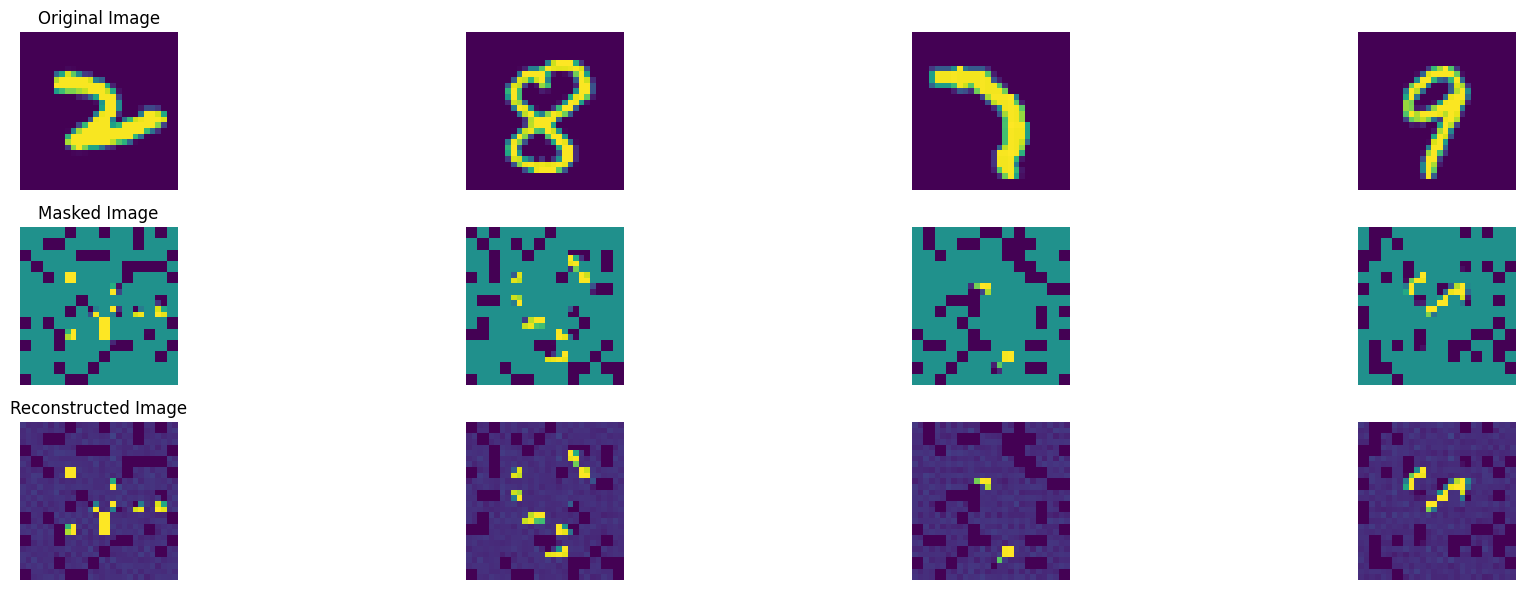

100%|██████████| 188/188 [00:38<00:00,  4.84it/s]


In epoch 1, average traning loss is 0.37254804563015065.
=================== EPOCH:  2  ===================


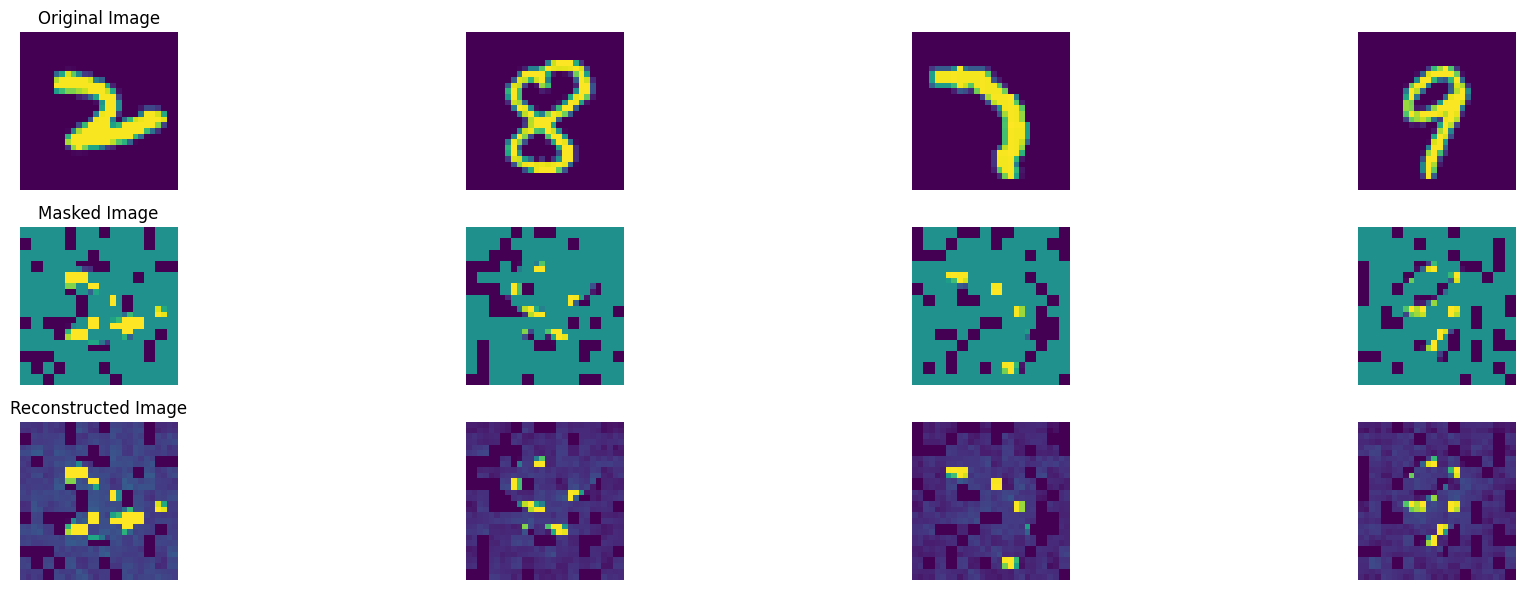

100%|██████████| 188/188 [00:39<00:00,  4.74it/s]


In epoch 2, average traning loss is 0.32625044771331424.
=================== EPOCH:  3  ===================


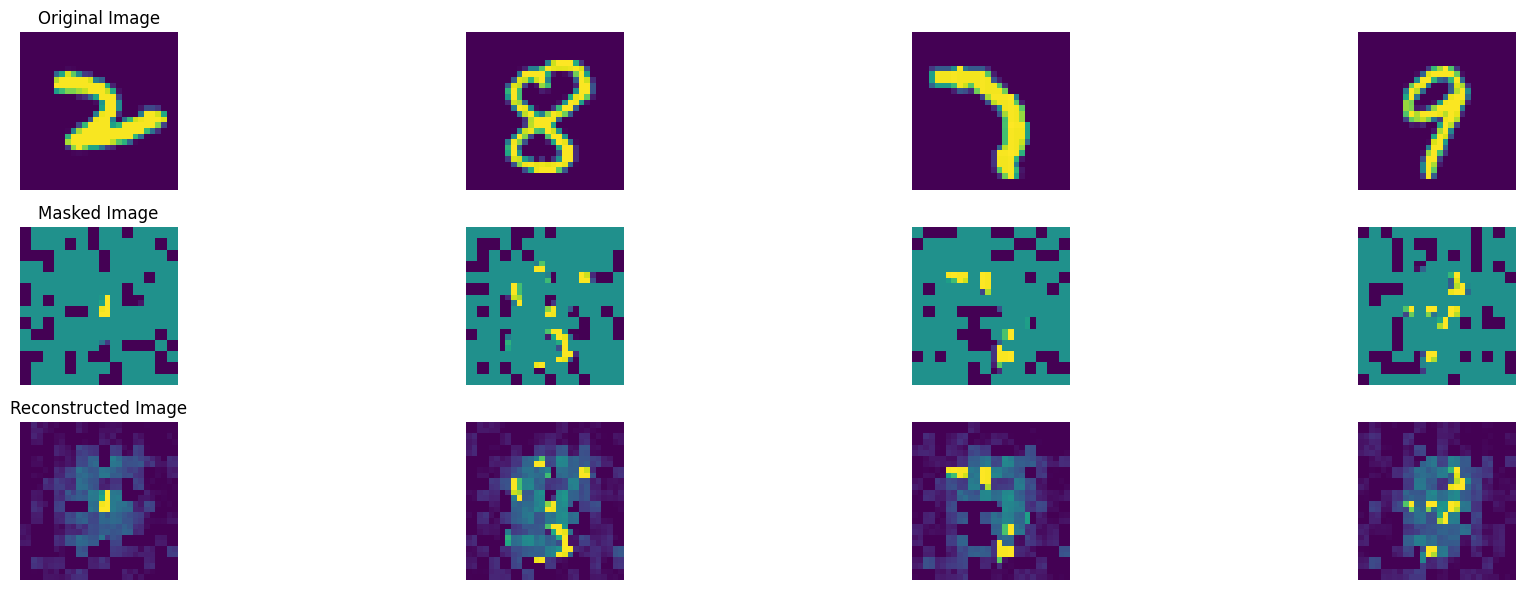

100%|██████████| 188/188 [00:40<00:00,  4.66it/s]


In epoch 3, average traning loss is 0.27698380642748893.
=================== EPOCH:  4  ===================


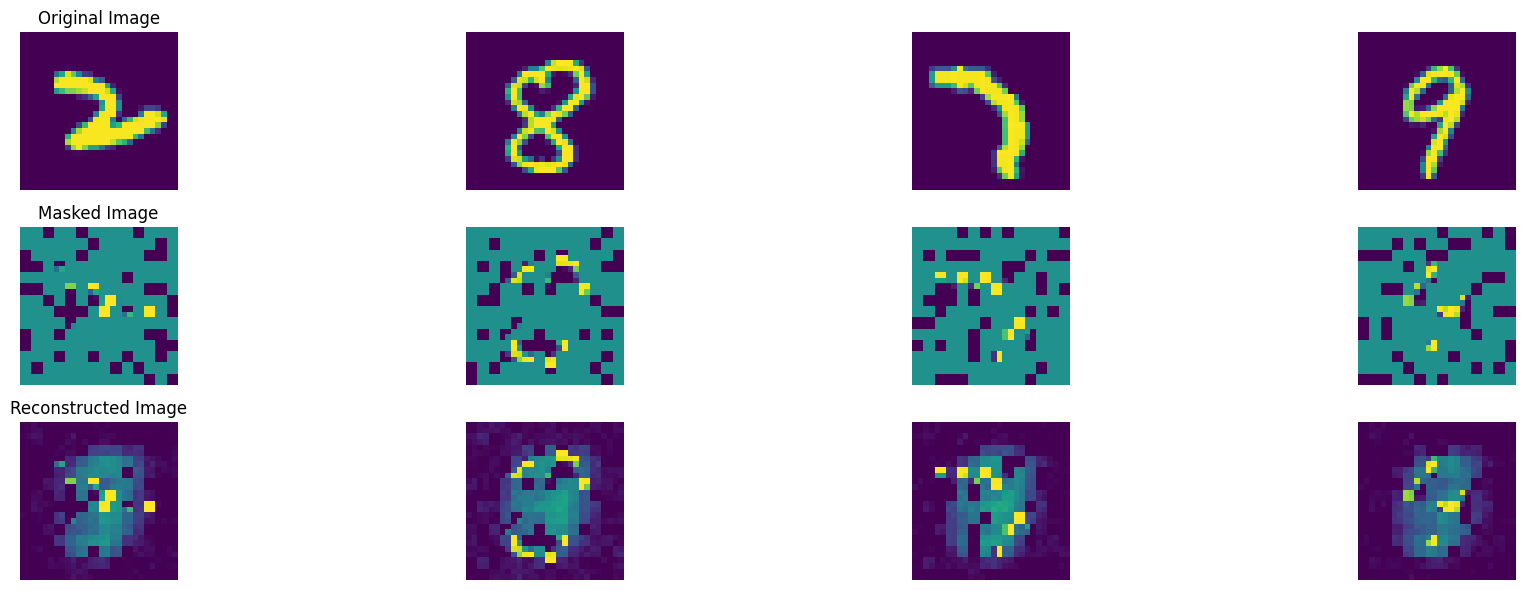

100%|██████████| 188/188 [00:38<00:00,  4.85it/s]


In epoch 4, average traning loss is 0.2651973544283116.
=================== EPOCH:  5  ===================


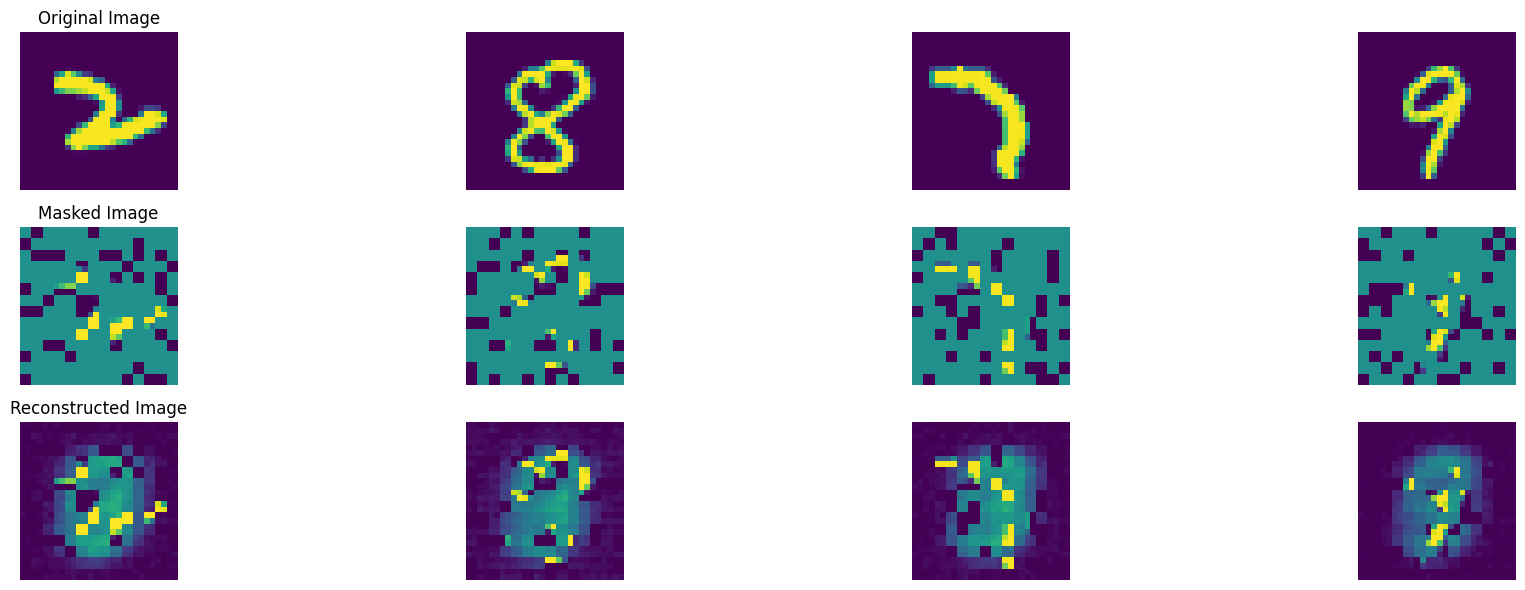

100%|██████████| 188/188 [00:38<00:00,  4.82it/s]


In epoch 5, average traning loss is 0.26293452860827143.
=================== EPOCH:  6  ===================


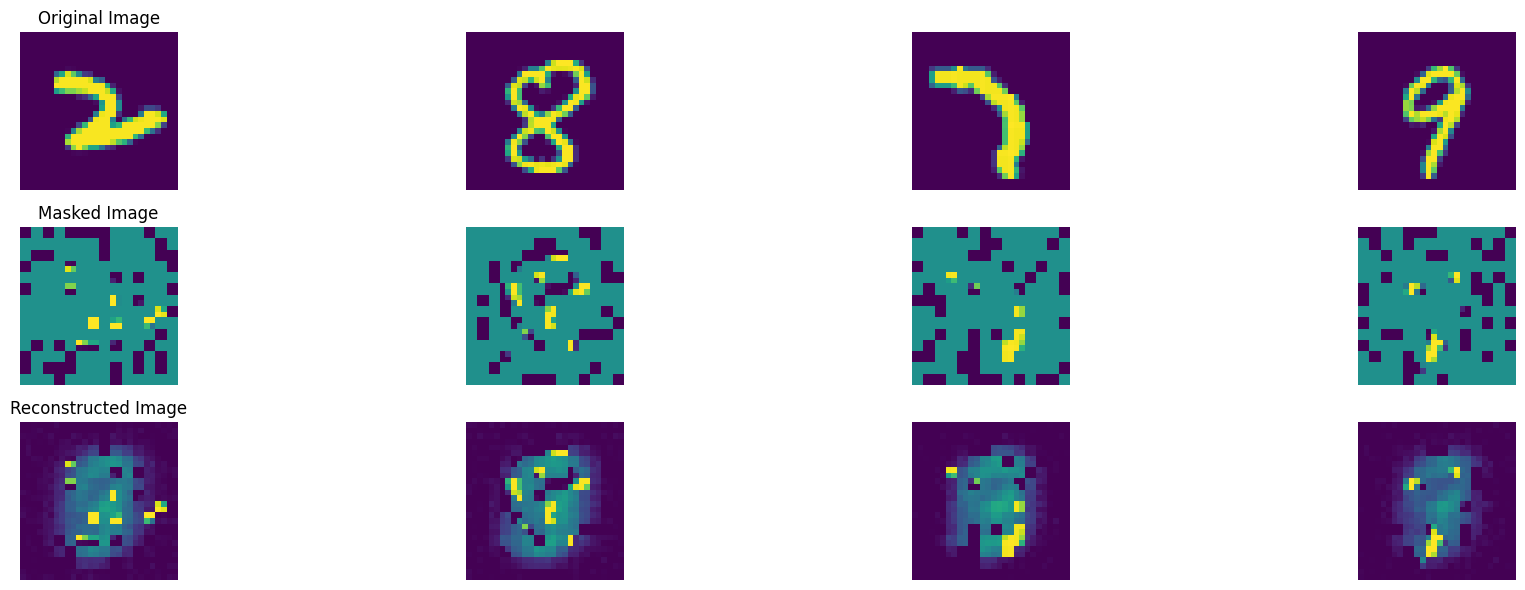

100%|██████████| 188/188 [00:39<00:00,  4.74it/s]


In epoch 6, average traning loss is 0.2612228126443447.
=================== EPOCH:  7  ===================


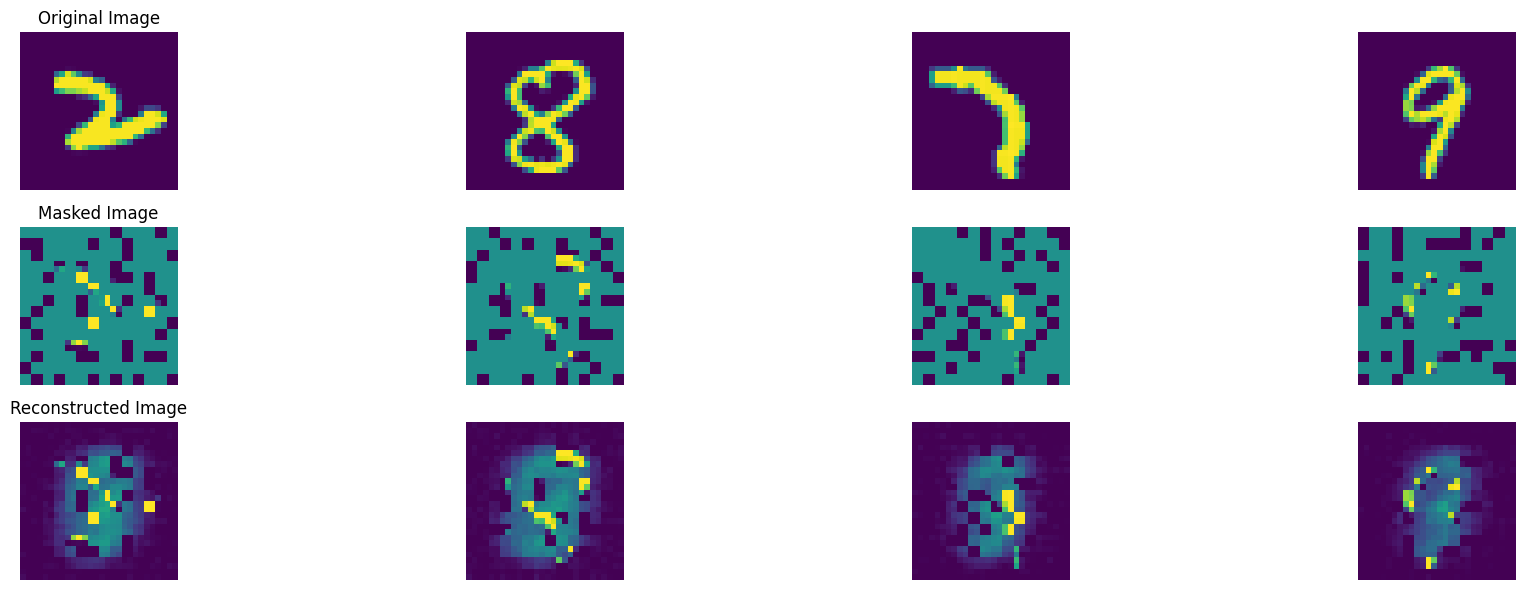

100%|██████████| 188/188 [00:40<00:00,  4.65it/s]


In epoch 7, average traning loss is 0.259731198165645.
=================== EPOCH:  8  ===================


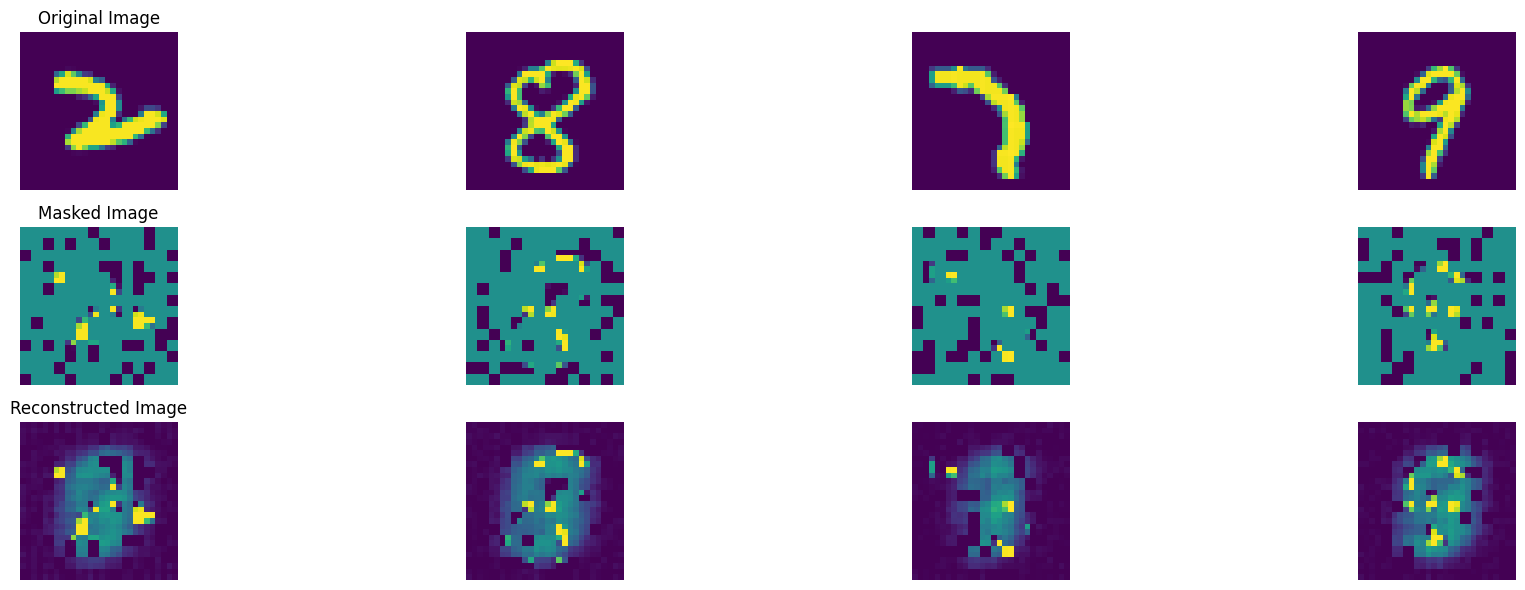

100%|██████████| 188/188 [00:40<00:00,  4.65it/s]


In epoch 8, average traning loss is 0.2582410088086382.
=================== EPOCH:  9  ===================


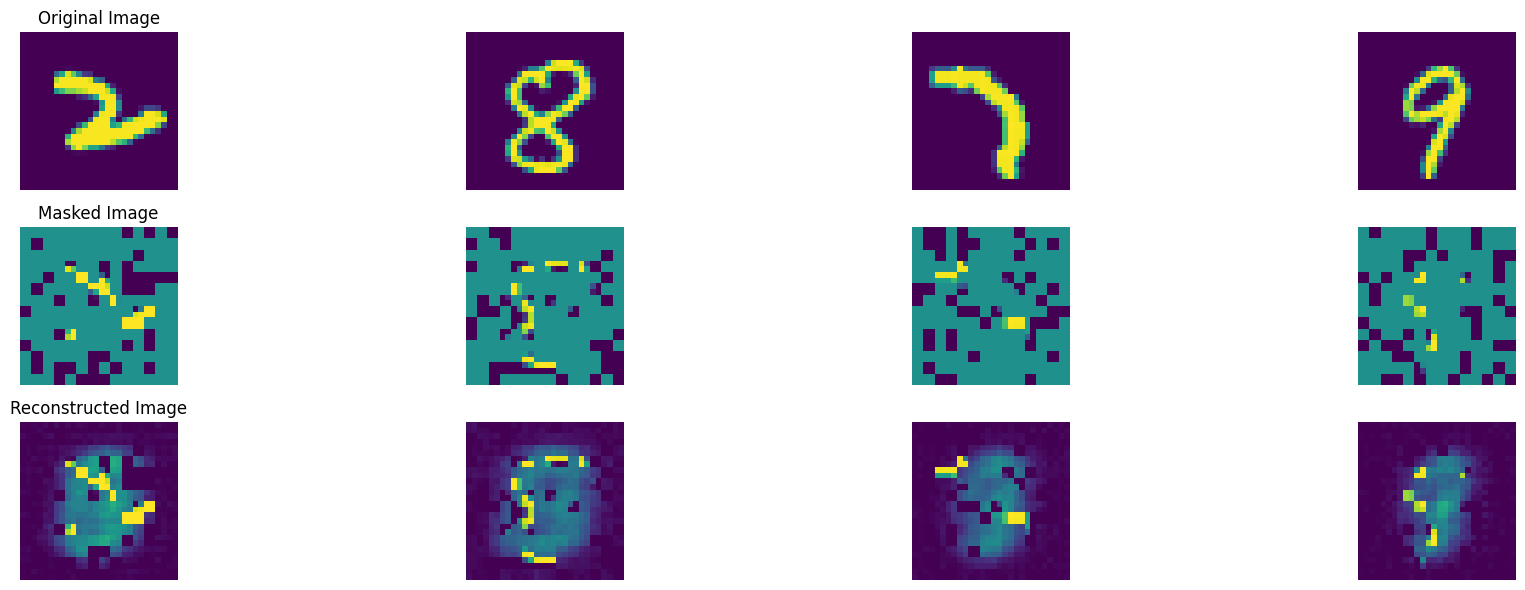

100%|██████████| 188/188 [00:40<00:00,  4.63it/s]


In epoch 9, average traning loss is 0.257022129411393.
=================== EPOCH:  10  ===================


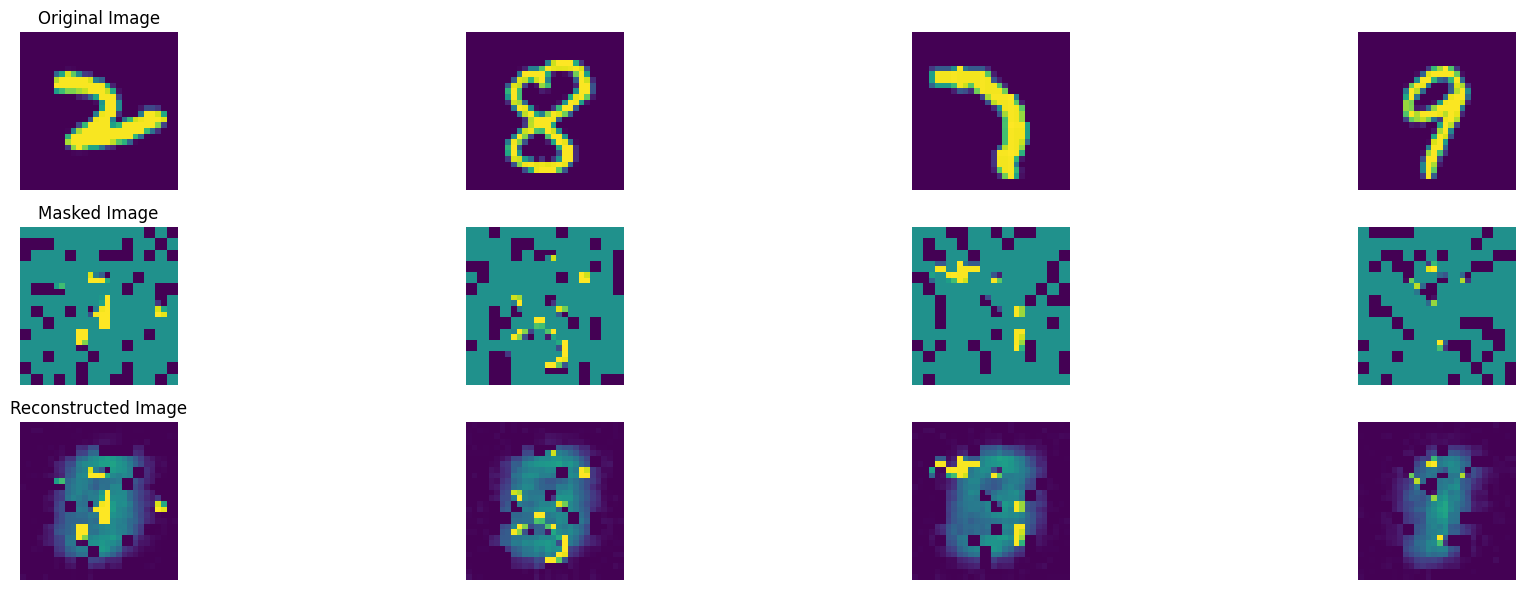

100%|██████████| 188/188 [00:40<00:00,  4.63it/s]


In epoch 10, average traning loss is 0.2558396074207539.
=================== EPOCH:  11  ===================


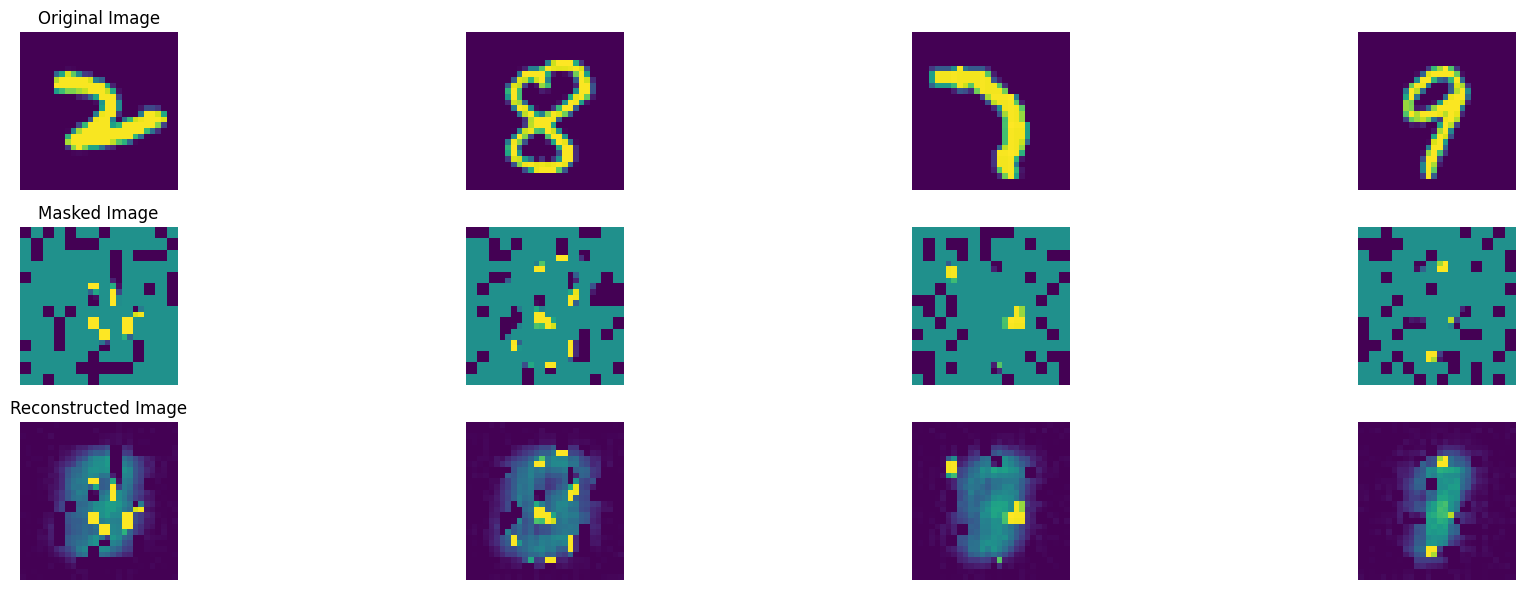

100%|██████████| 188/188 [00:40<00:00,  4.60it/s]


In epoch 11, average traning loss is 0.2539977784803573.
=================== EPOCH:  12  ===================


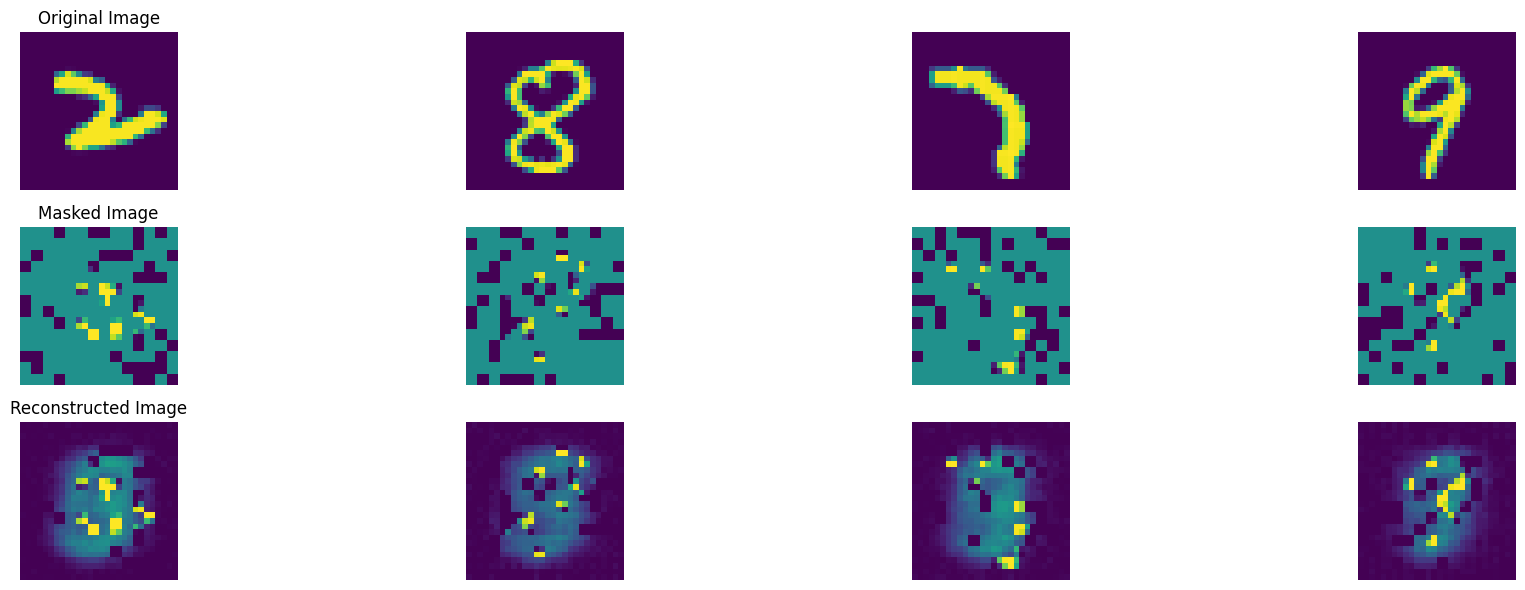

100%|██████████| 188/188 [00:41<00:00,  4.59it/s]


In epoch 12, average traning loss is 0.253059243426678.
=================== EPOCH:  13  ===================


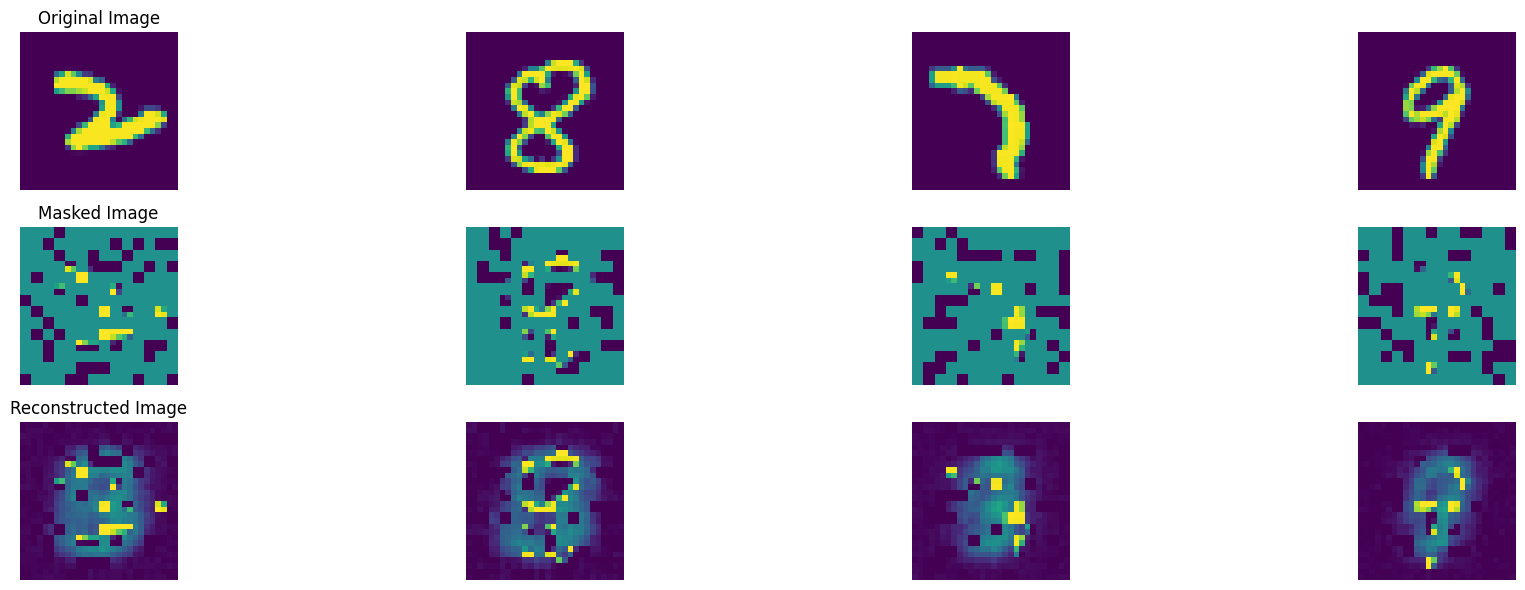

100%|██████████| 188/188 [00:40<00:00,  4.59it/s]


In epoch 13, average traning loss is 0.25173271550460063.
=================== EPOCH:  14  ===================


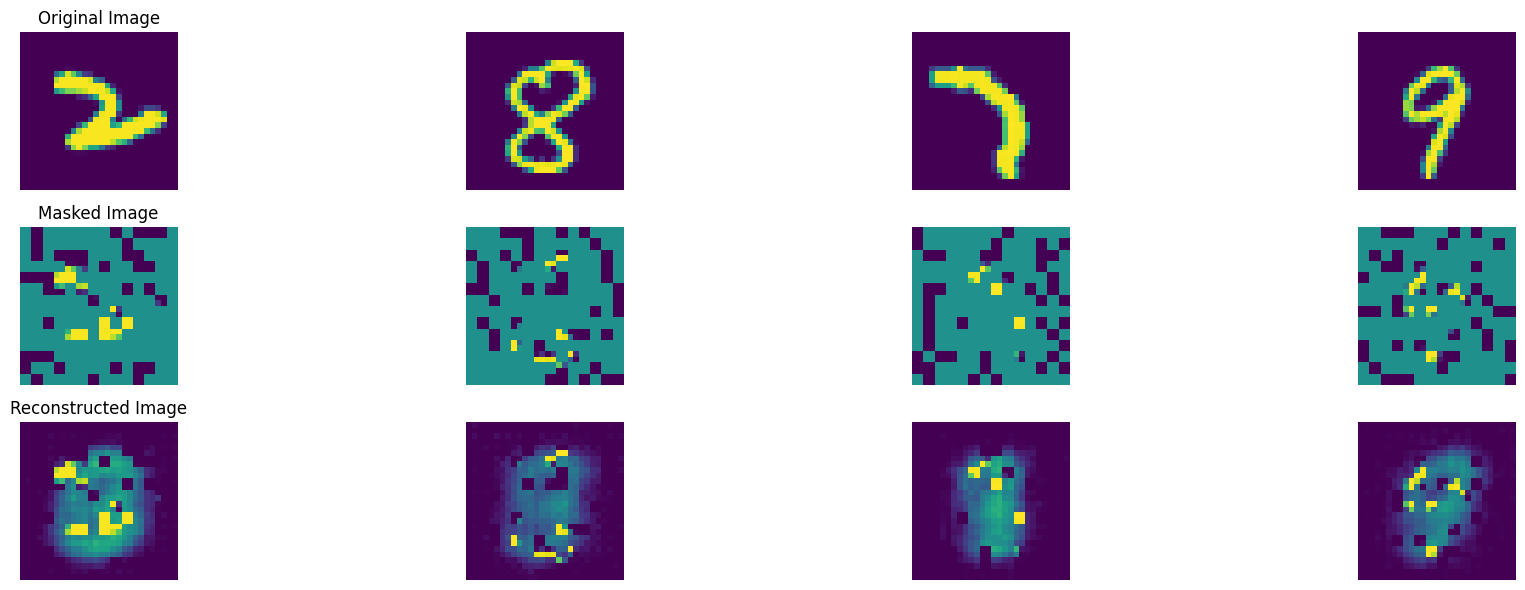

100%|██████████| 188/188 [00:40<00:00,  4.59it/s]


In epoch 14, average traning loss is 0.2506490816619802.
=================== EPOCH:  15  ===================


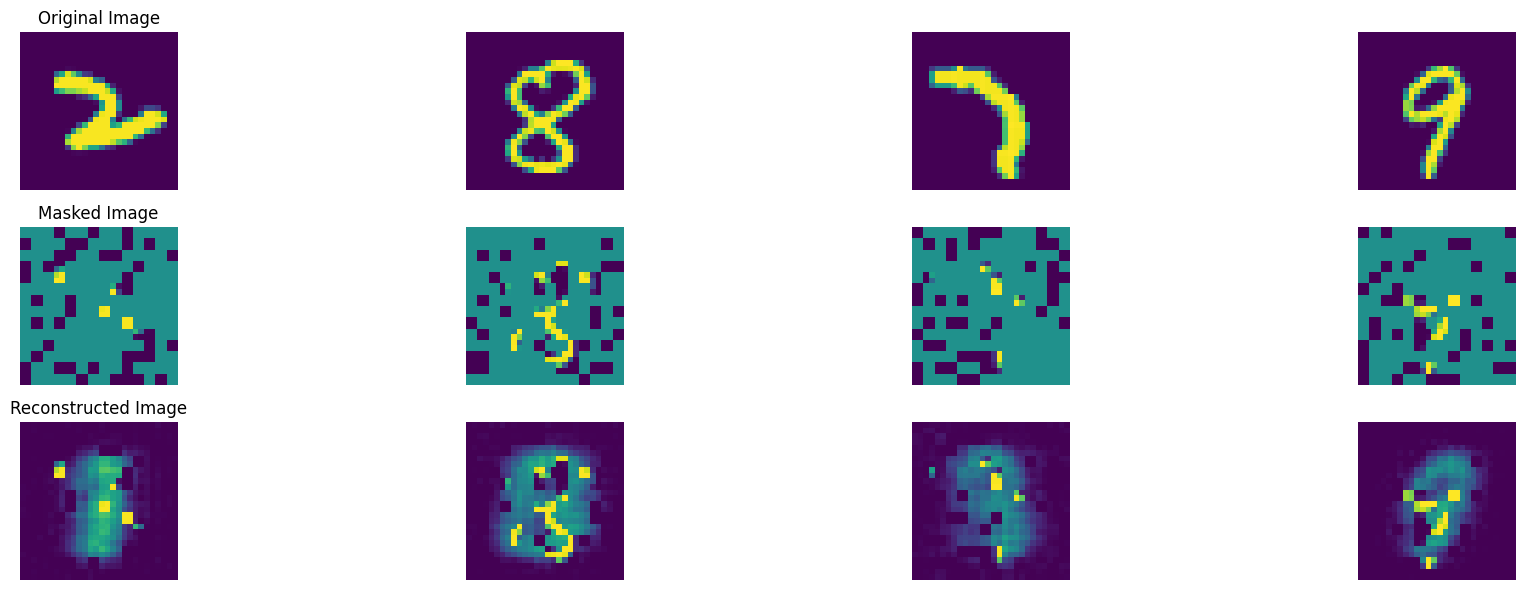

100%|██████████| 188/188 [00:40<00:00,  4.61it/s]


In epoch 15, average traning loss is 0.24952735514082808.
=================== EPOCH:  16  ===================


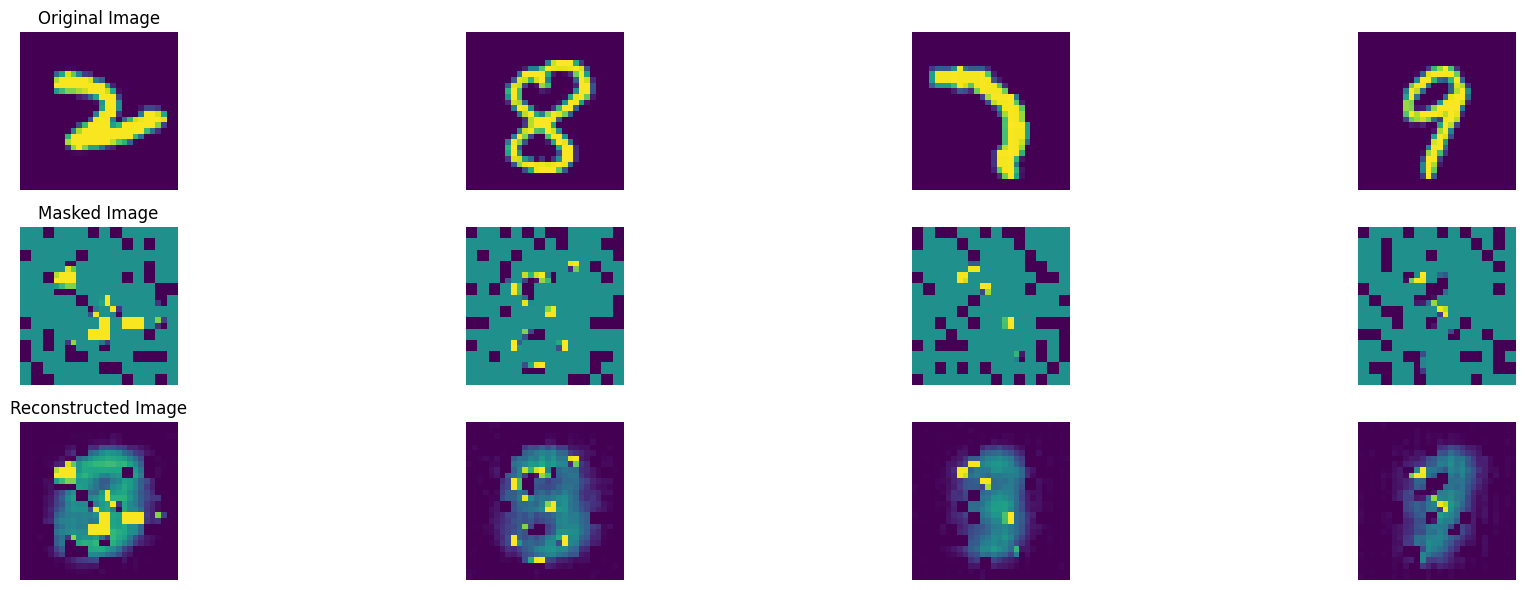

100%|██████████| 188/188 [00:39<00:00,  4.80it/s]


In epoch 16, average traning loss is 0.24868464485761968.
=================== EPOCH:  17  ===================


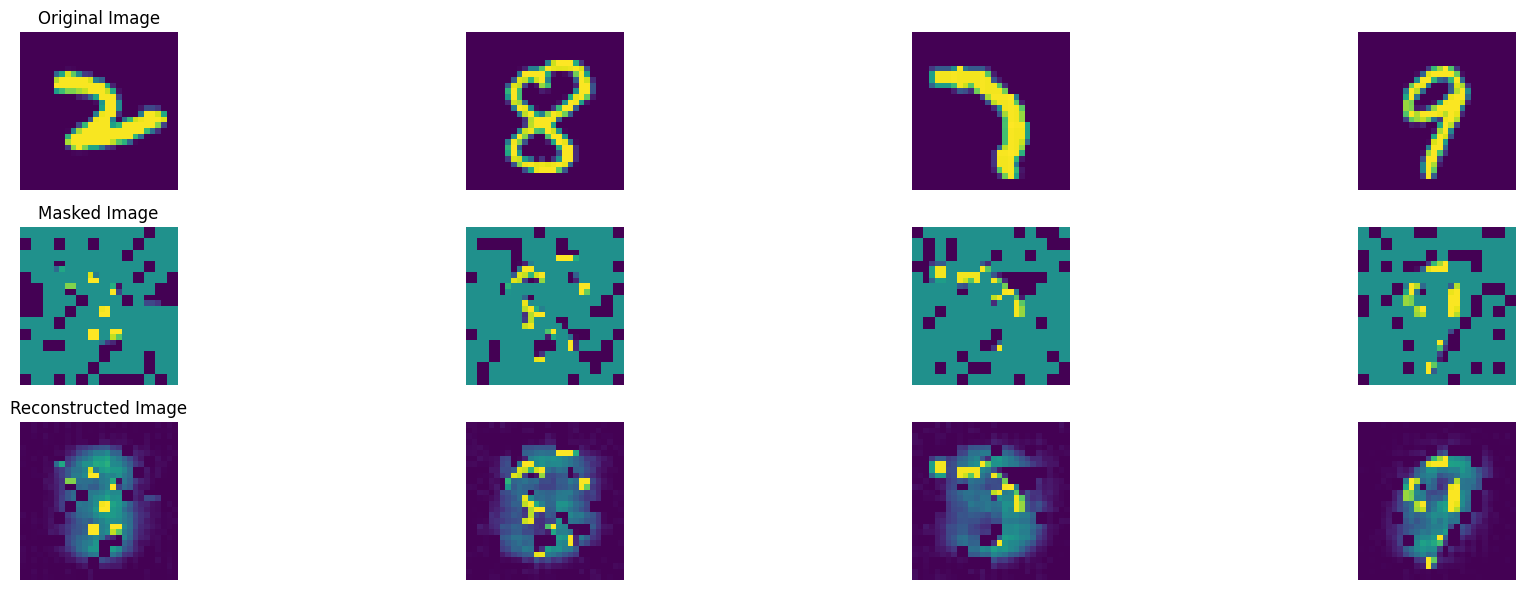

100%|██████████| 188/188 [00:40<00:00,  4.70it/s]


In epoch 17, average traning loss is 0.24717461650675915.
=================== EPOCH:  18  ===================


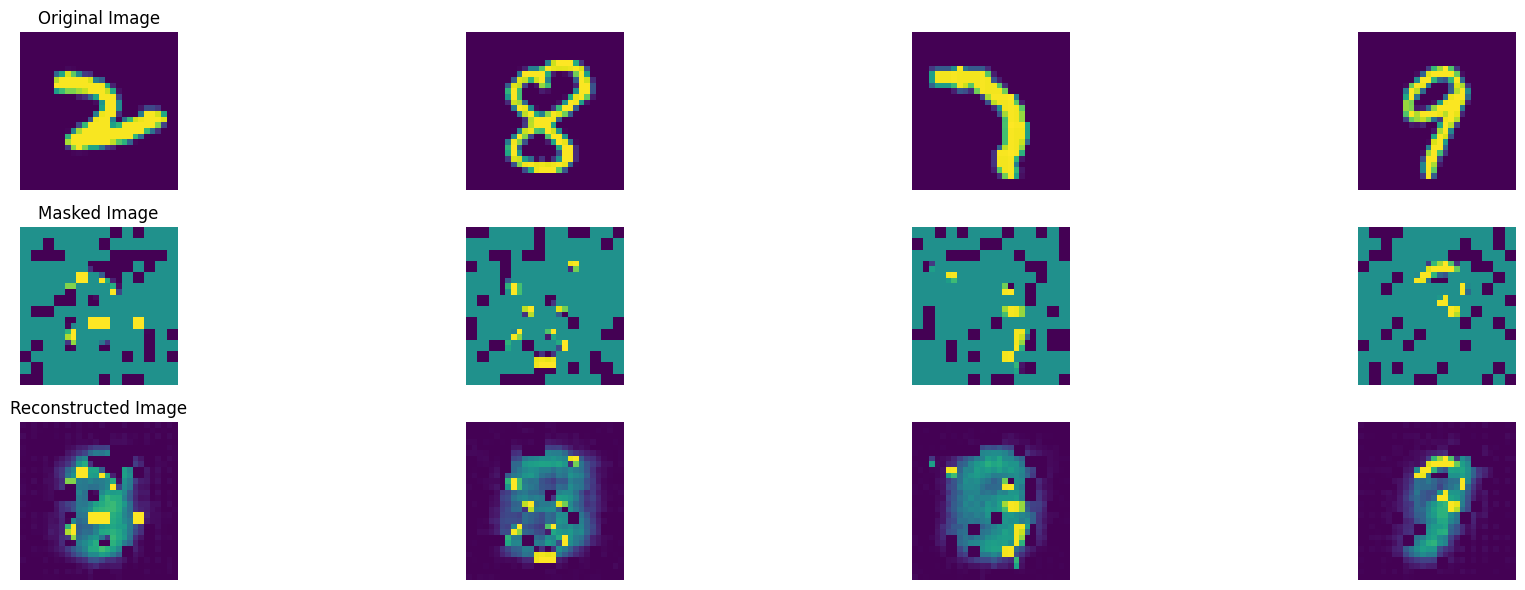

100%|██████████| 188/188 [00:40<00:00,  4.63it/s]


In epoch 18, average traning loss is 0.2454817440915615.
=================== EPOCH:  19  ===================


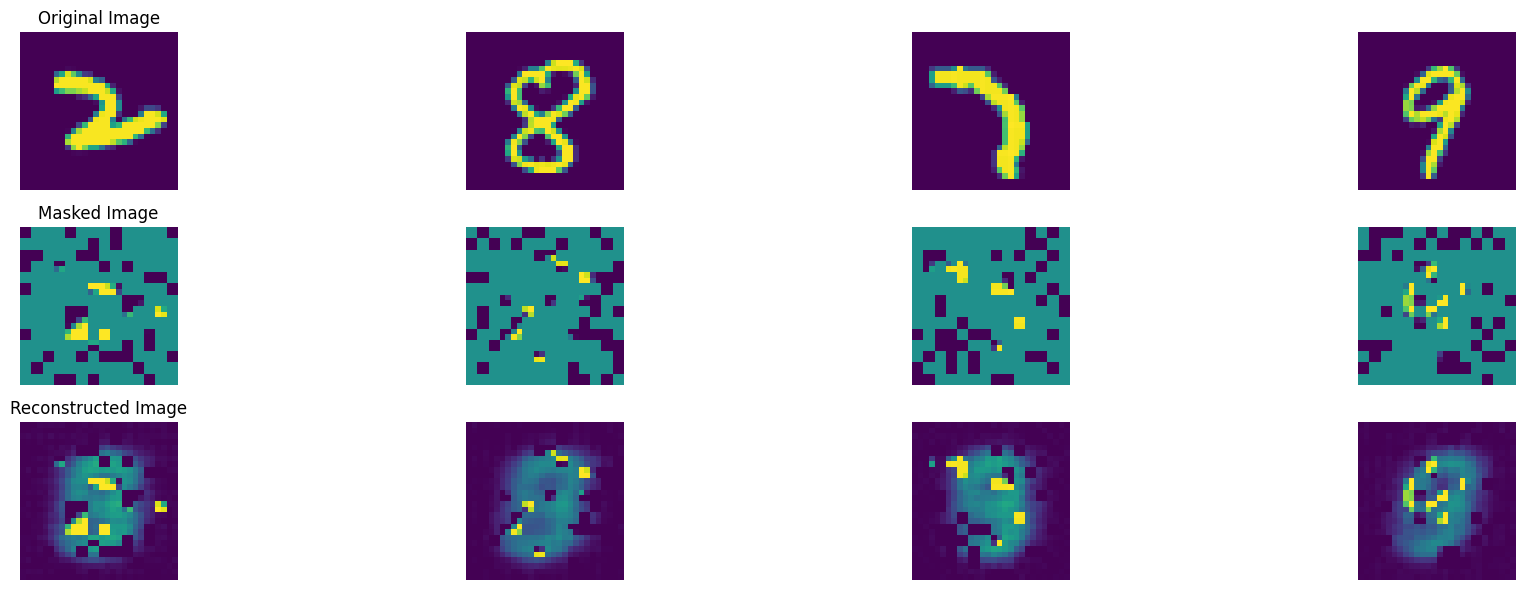

100%|██████████| 188/188 [00:41<00:00,  4.57it/s]


In epoch 19, average traning loss is 0.2431755249012024.
=================== EPOCH:  20  ===================


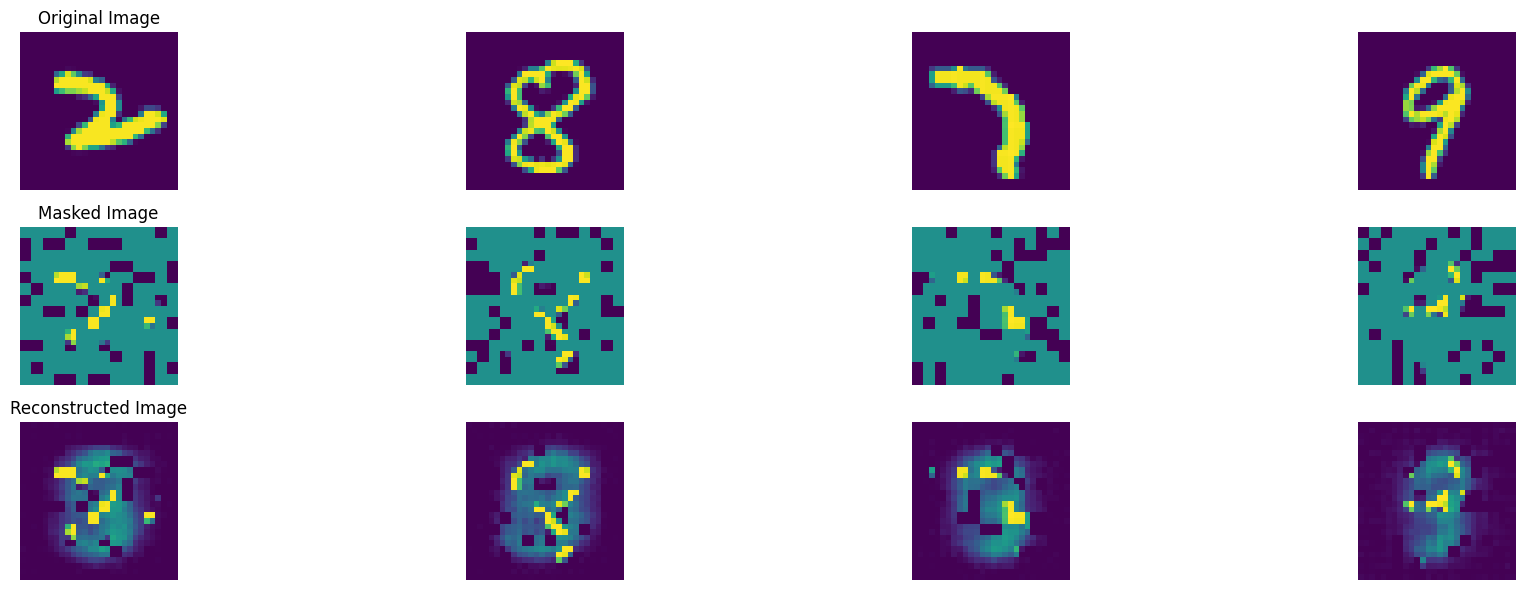

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 20, average traning loss is 0.24100797686805117.
=================== EPOCH:  21  ===================


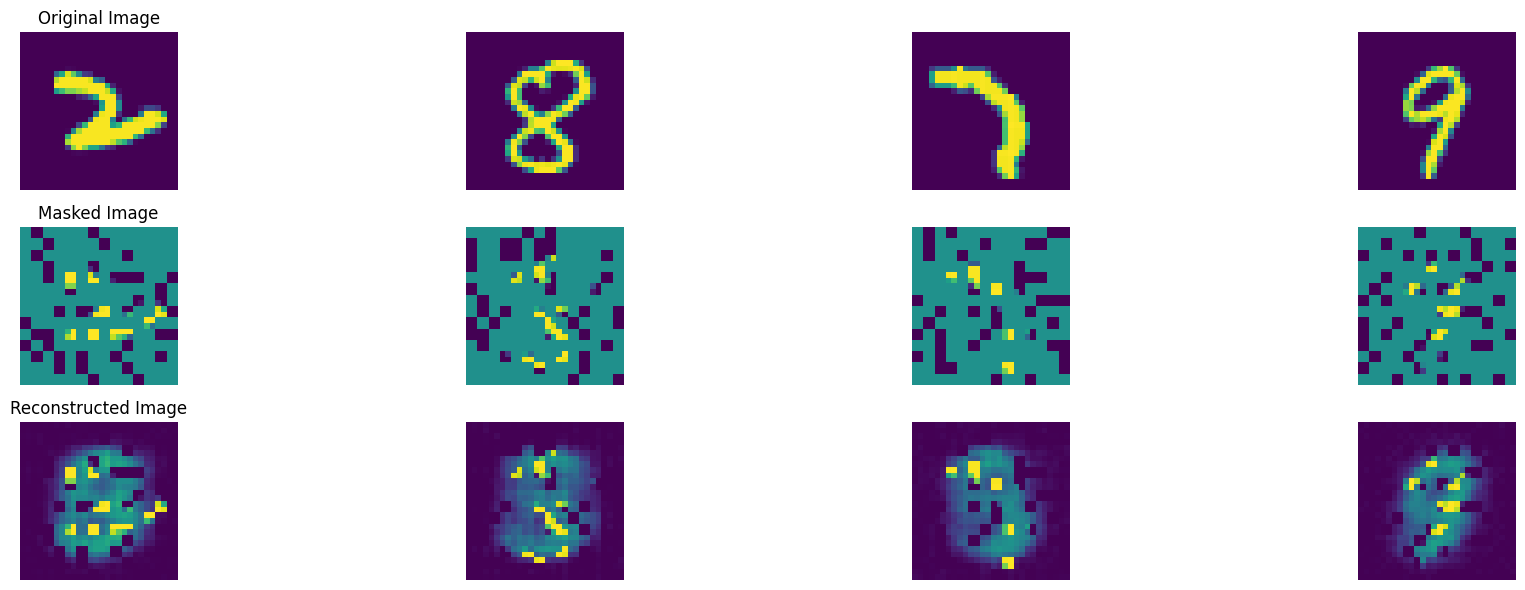

100%|██████████| 188/188 [00:40<00:00,  4.61it/s]


In epoch 21, average traning loss is 0.23860255169107558.
=================== EPOCH:  22  ===================


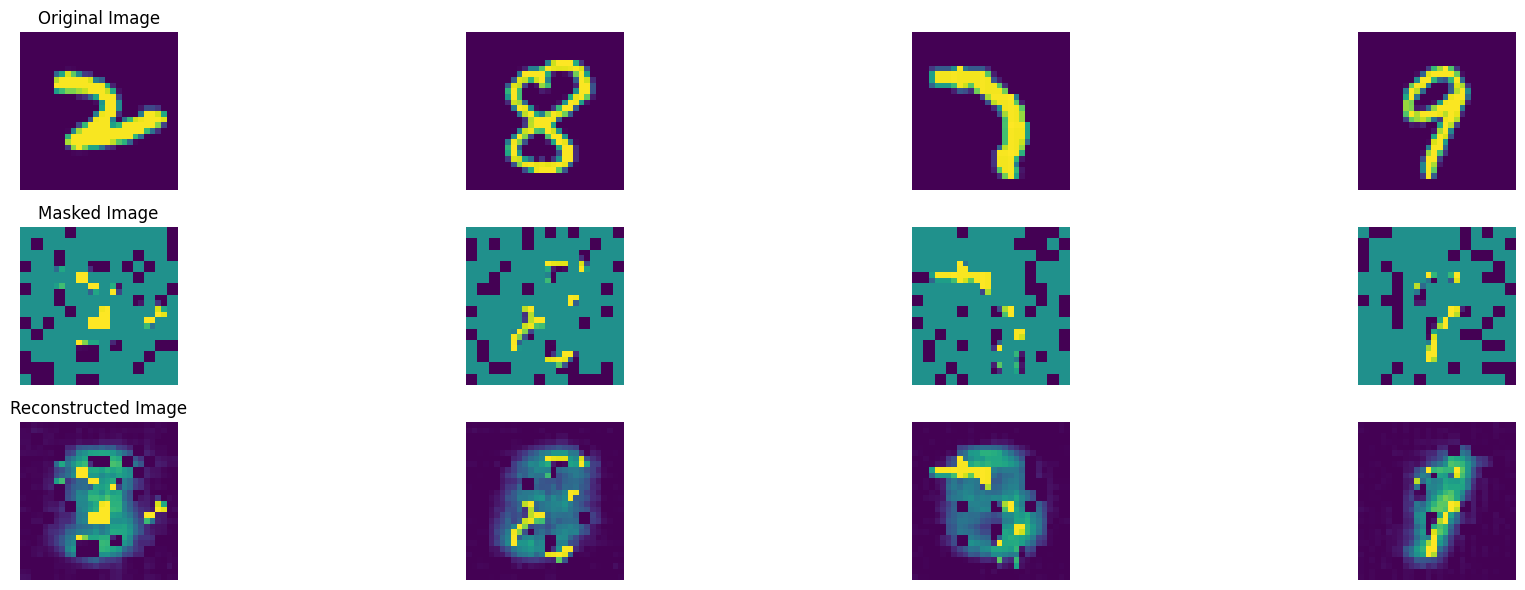

100%|██████████| 188/188 [00:40<00:00,  4.61it/s]


In epoch 22, average traning loss is 0.23583314575730485.
=================== EPOCH:  23  ===================


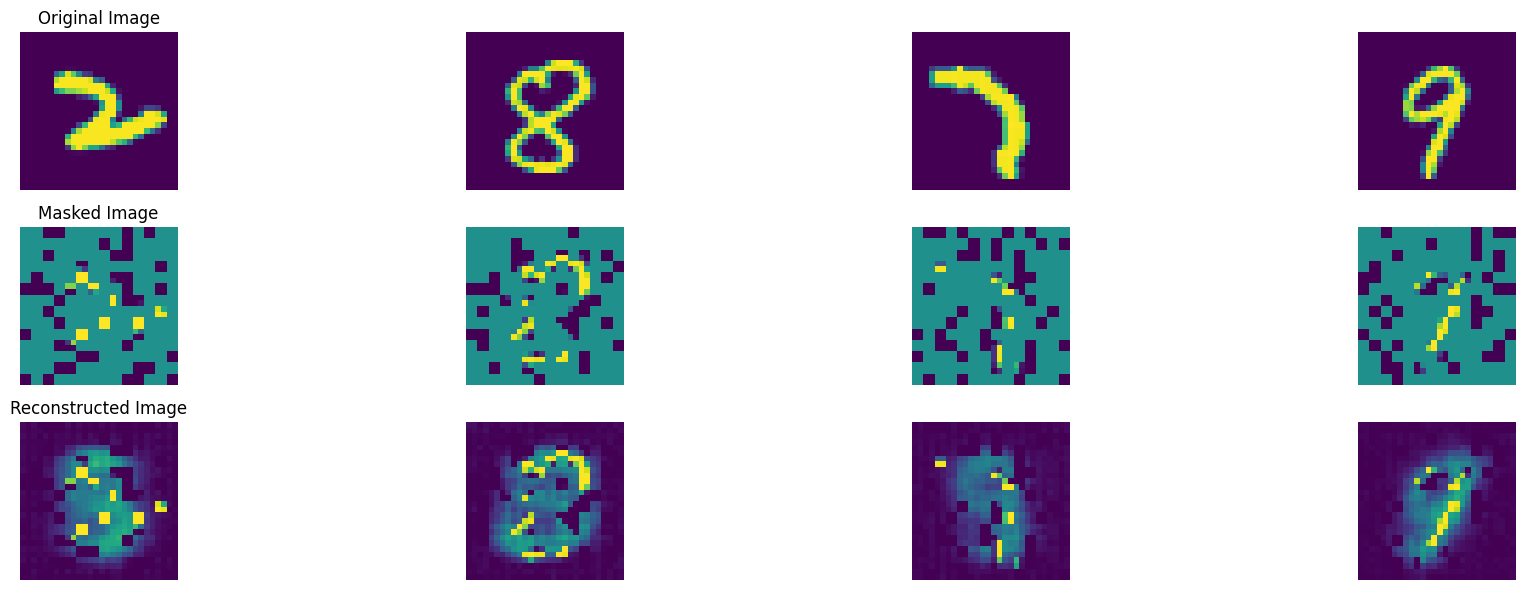

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 23, average traning loss is 0.23259067051905266.
=================== EPOCH:  24  ===================


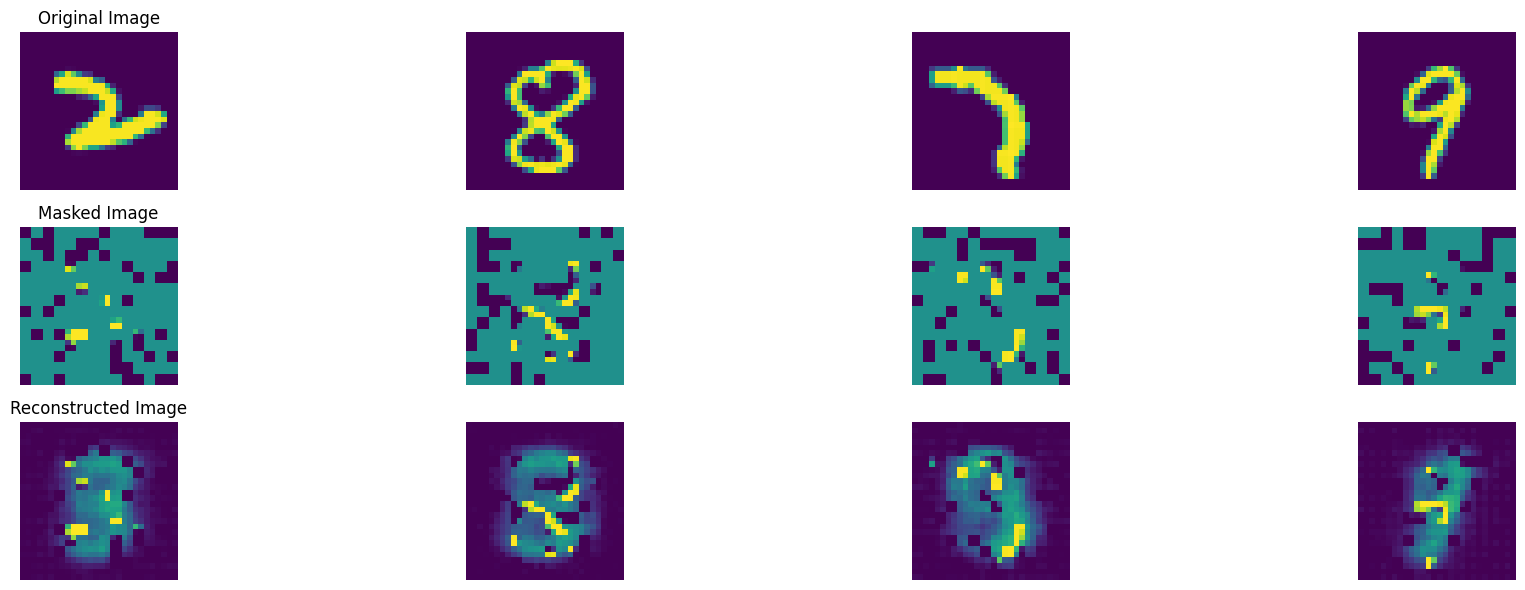

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 24, average traning loss is 0.2293705996522244.
=================== EPOCH:  25  ===================


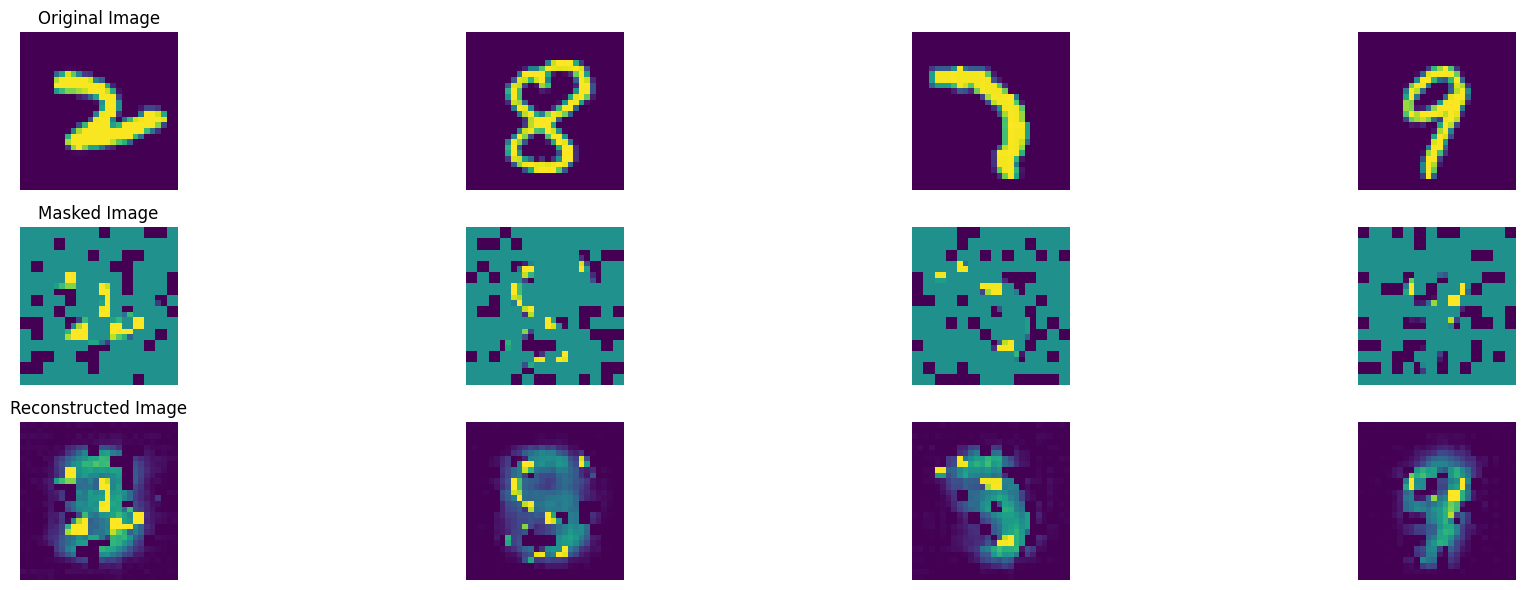

100%|██████████| 188/188 [00:41<00:00,  4.54it/s]


In epoch 25, average traning loss is 0.22605411415087415.
=================== EPOCH:  26  ===================


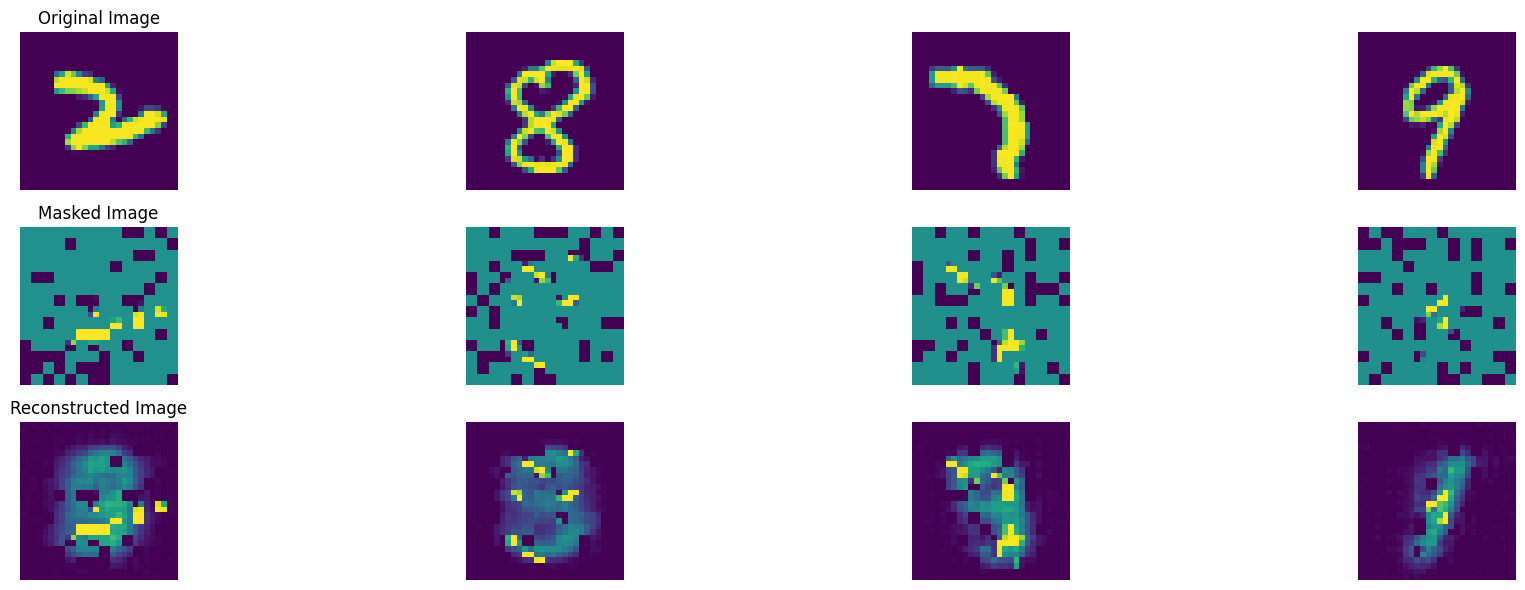

100%|██████████| 188/188 [00:41<00:00,  4.56it/s]


In epoch 26, average traning loss is 0.22284168551893943.
=================== EPOCH:  27  ===================


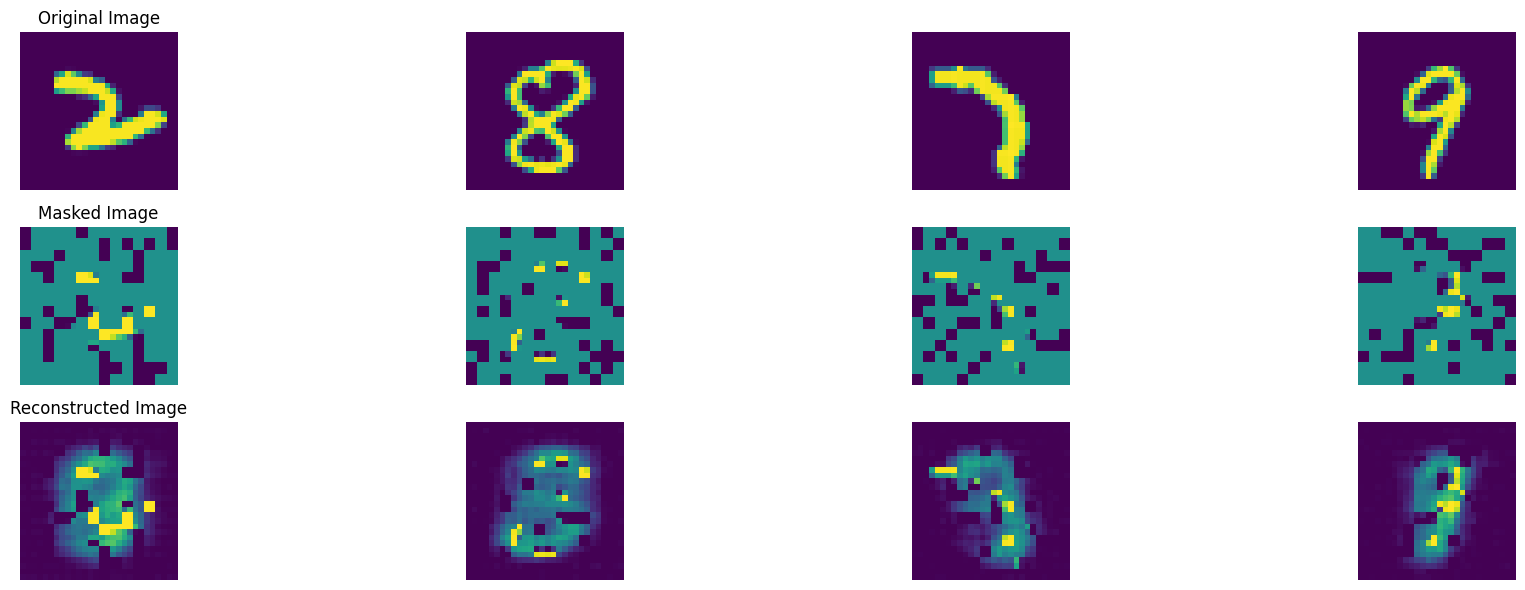

100%|██████████| 188/188 [00:40<00:00,  4.60it/s]


In epoch 27, average traning loss is 0.22066399209359858.
=================== EPOCH:  28  ===================


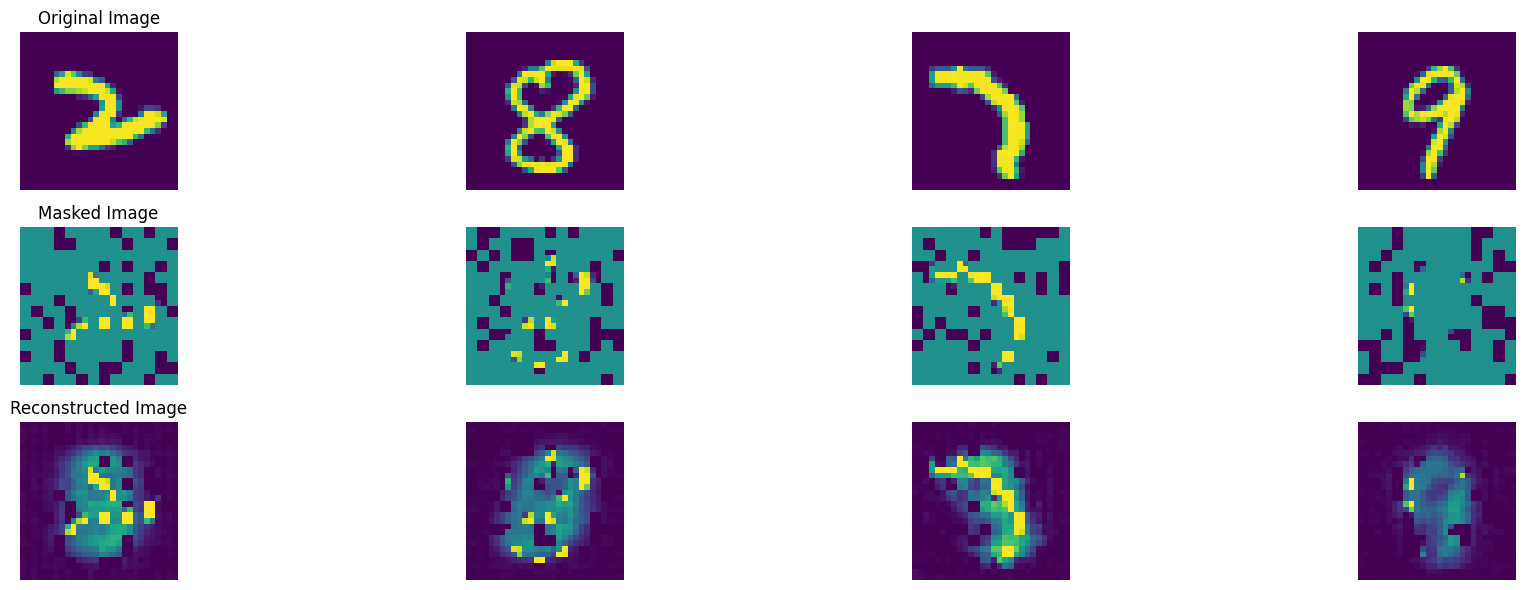

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 28, average traning loss is 0.21724530935604522.
=================== EPOCH:  29  ===================


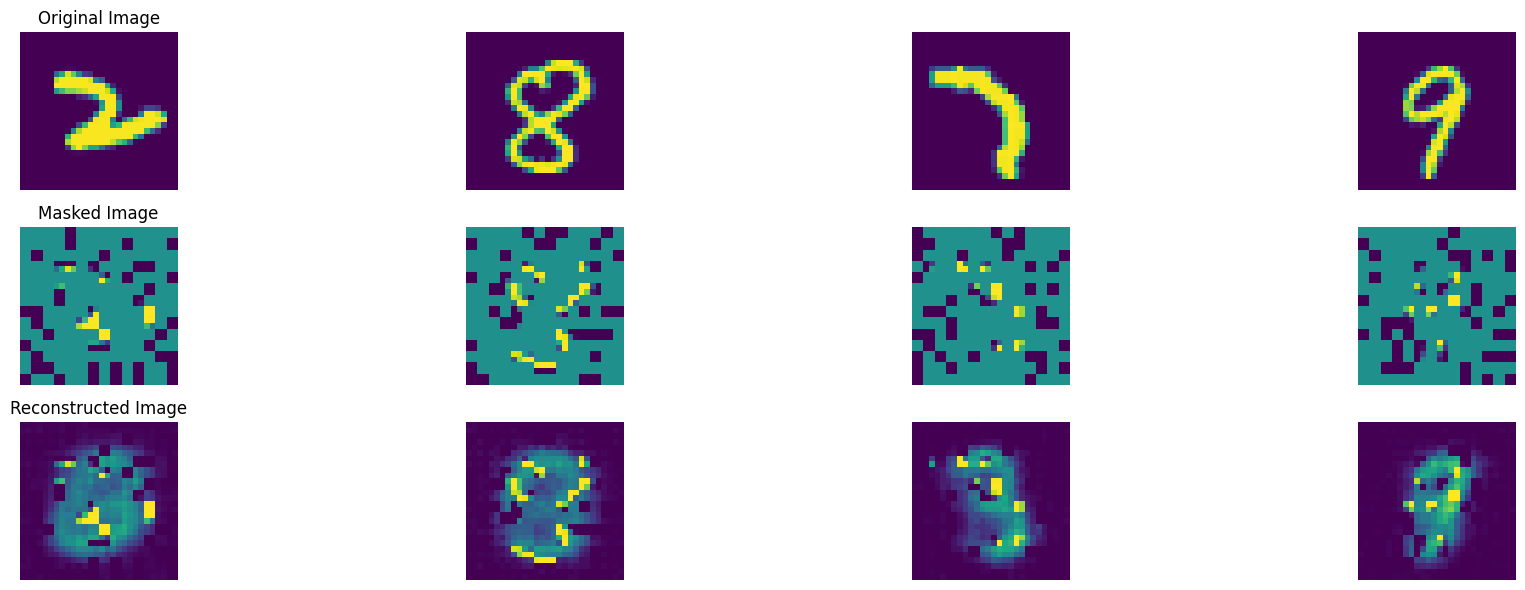

100%|██████████| 188/188 [00:41<00:00,  4.55it/s]


In epoch 29, average traning loss is 0.21444207580482705.
=================== EPOCH:  30  ===================


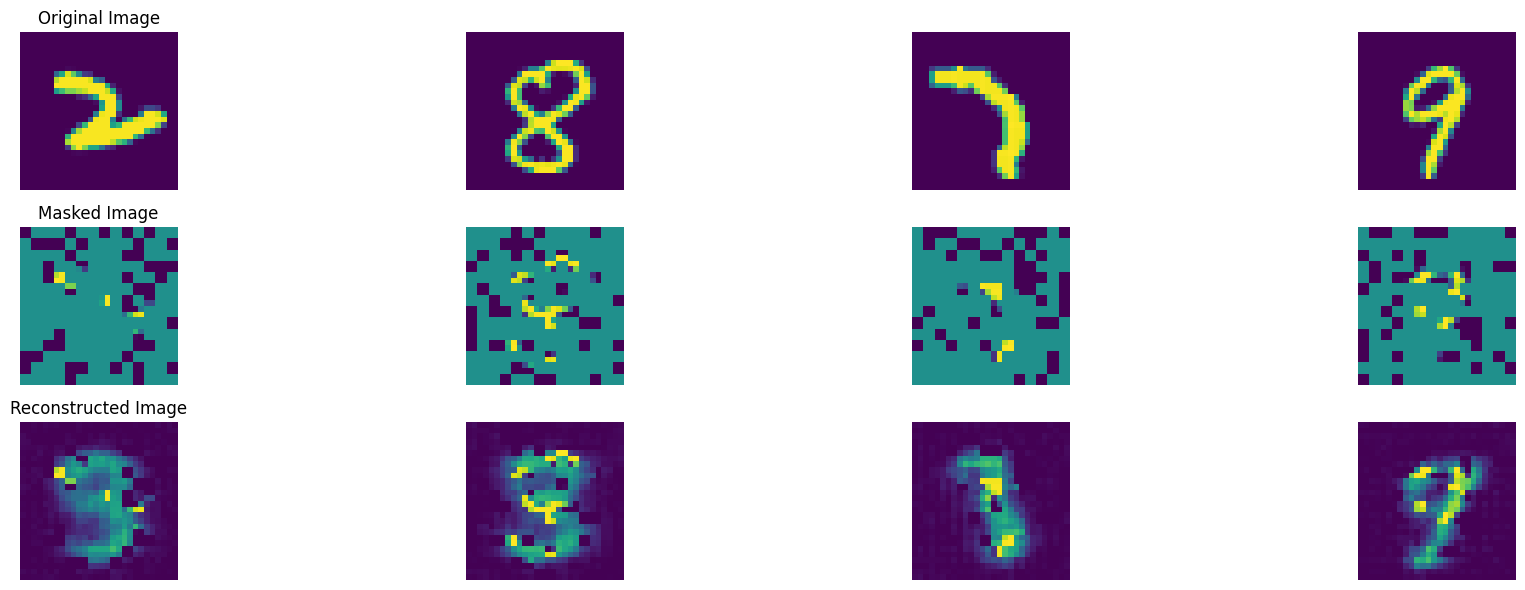

100%|██████████| 188/188 [00:41<00:00,  4.57it/s]


In epoch 30, average traning loss is 0.21140329008723827.
=================== EPOCH:  31  ===================


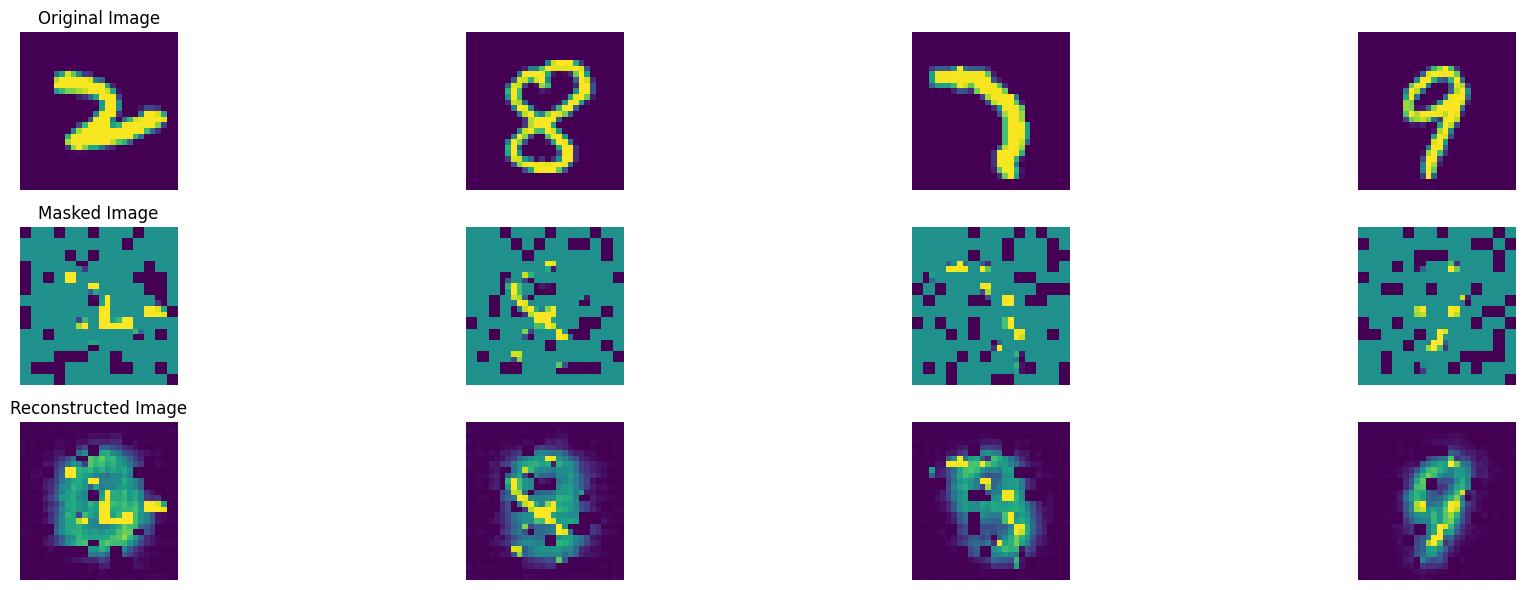

100%|██████████| 188/188 [00:40<00:00,  4.64it/s]


In epoch 31, average traning loss is 0.2084092285404814.
=================== EPOCH:  32  ===================


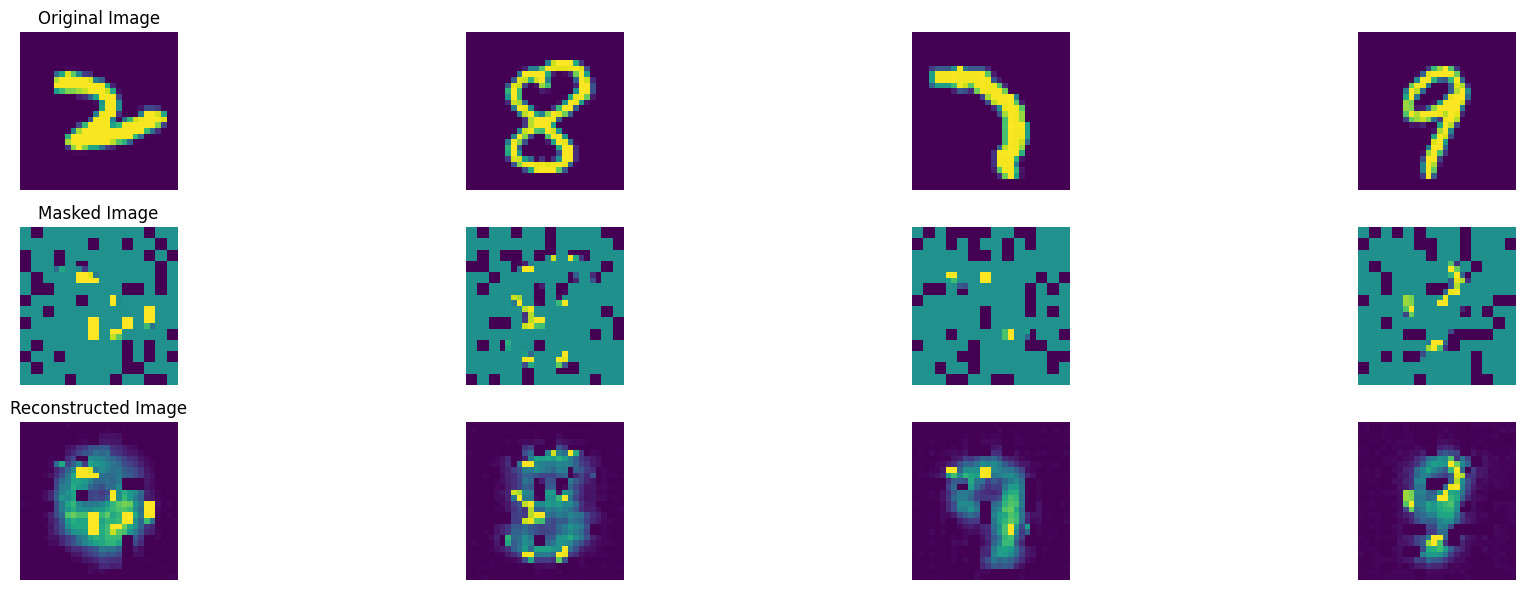

100%|██████████| 188/188 [00:39<00:00,  4.79it/s]


In epoch 32, average traning loss is 0.2055616868620223.
=================== EPOCH:  33  ===================


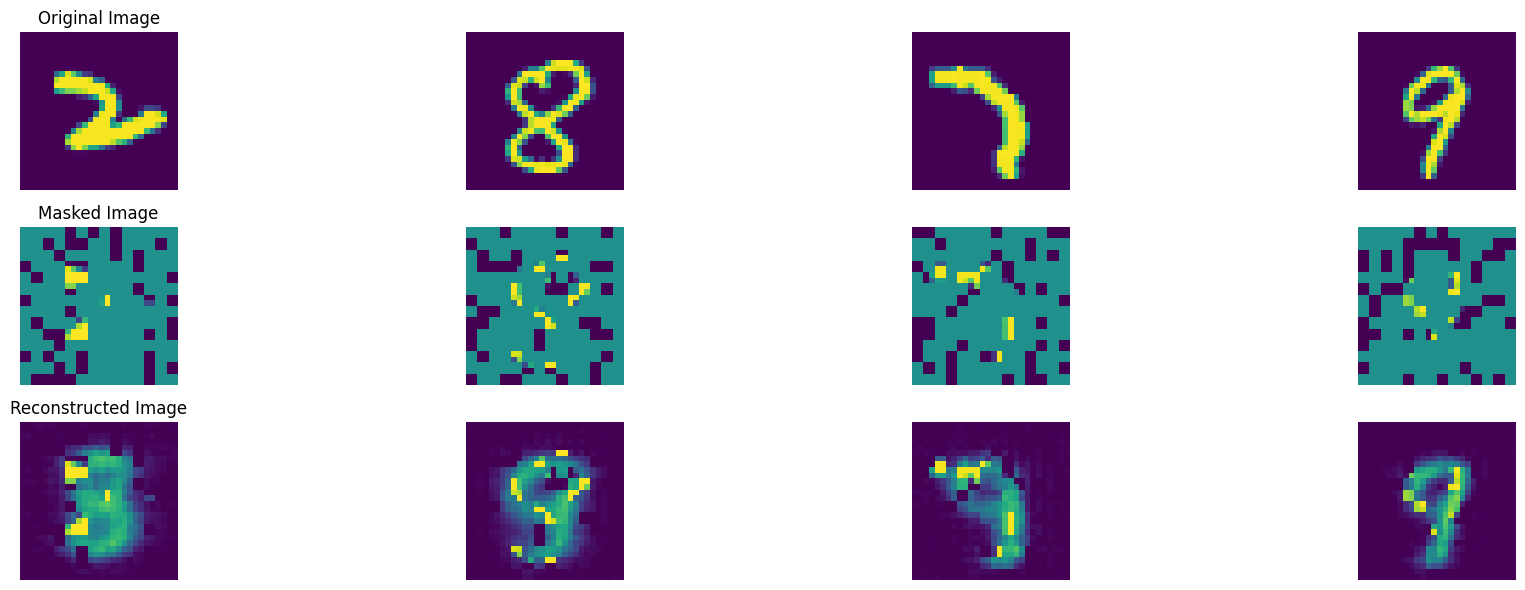

100%|██████████| 188/188 [00:39<00:00,  4.72it/s]


In epoch 33, average traning loss is 0.20244905400149366.
=================== EPOCH:  34  ===================


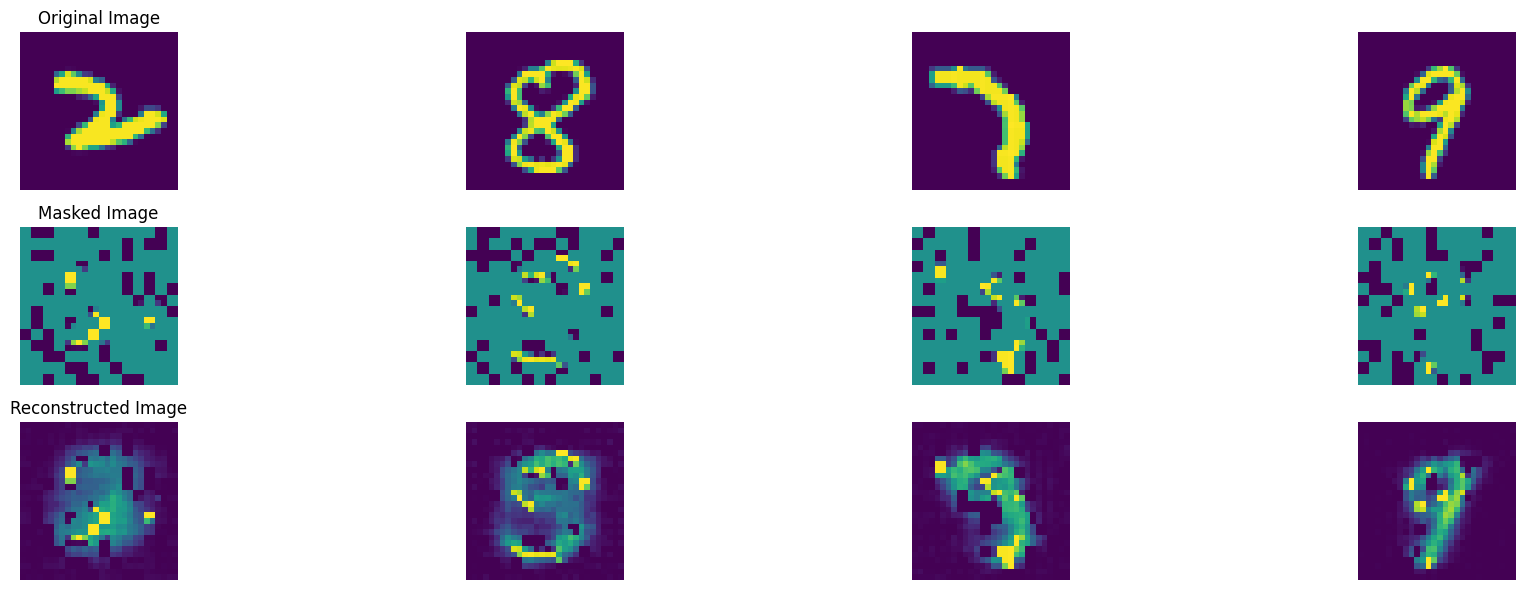

100%|██████████| 188/188 [00:40<00:00,  4.63it/s]


In epoch 34, average traning loss is 0.19922277458170626.
=================== EPOCH:  35  ===================


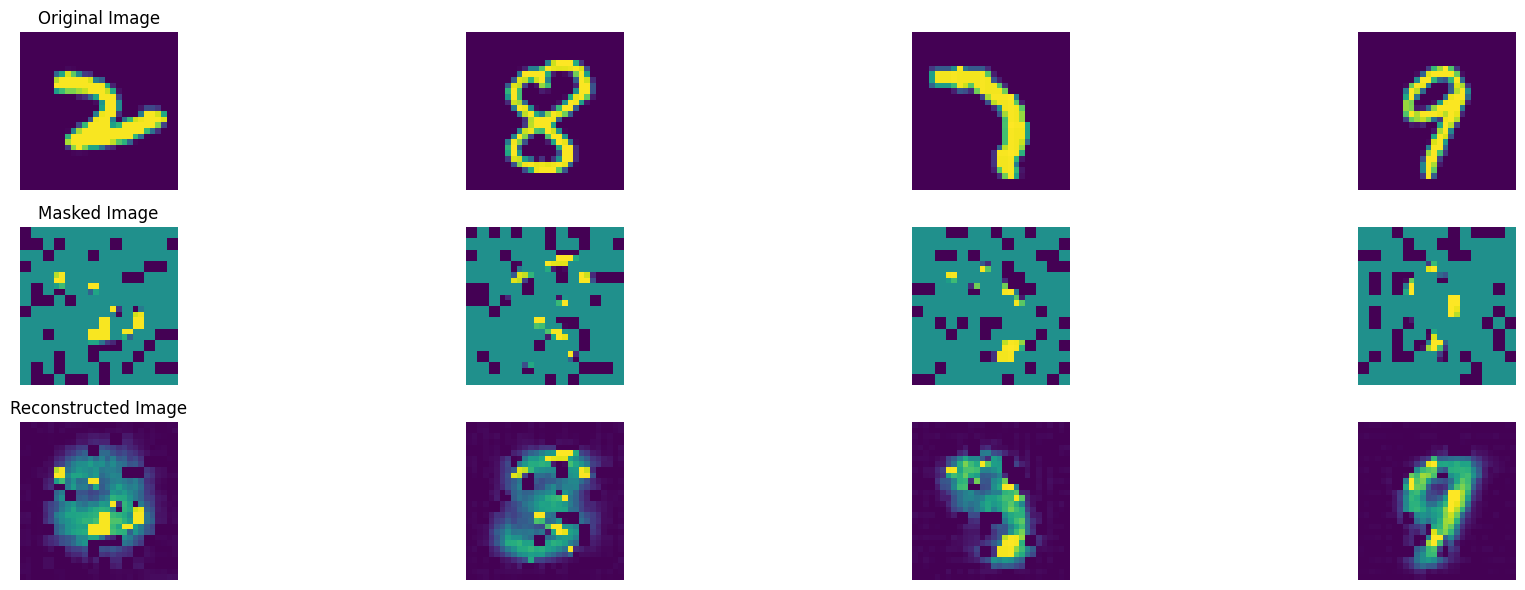

100%|██████████| 188/188 [00:40<00:00,  4.69it/s]


In epoch 35, average traning loss is 0.19564528049940758.
=================== EPOCH:  36  ===================


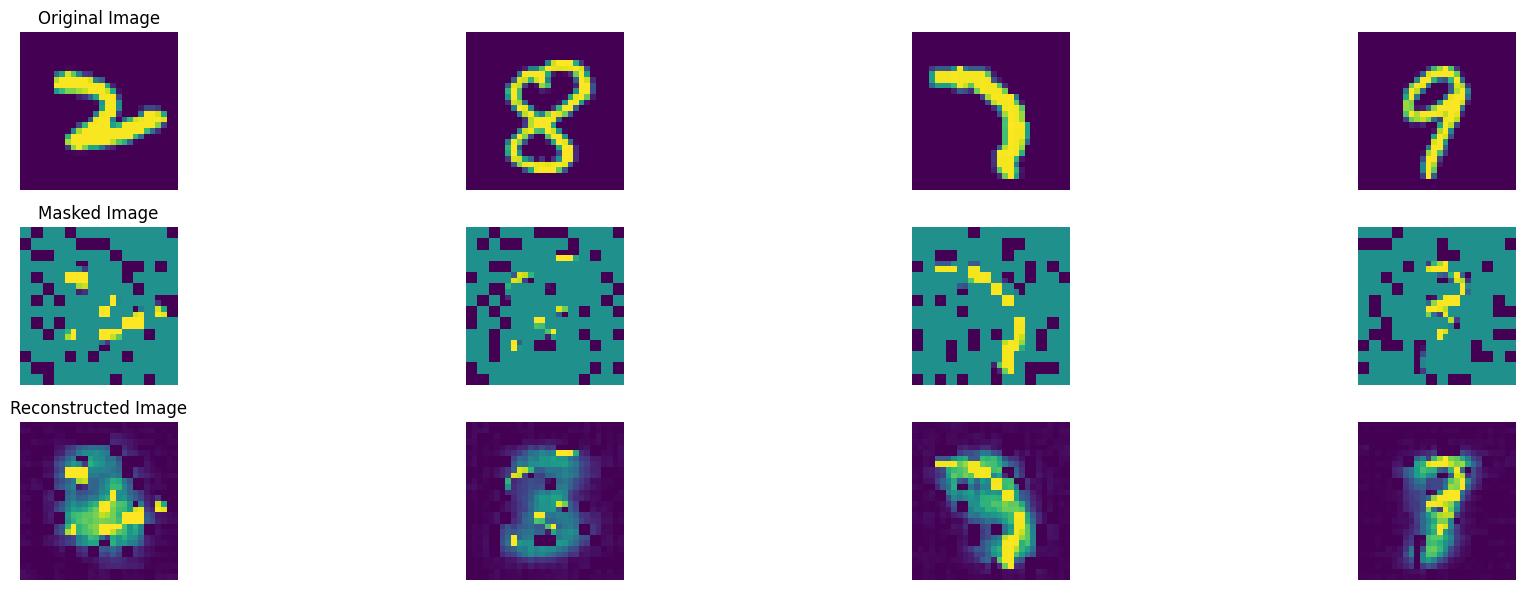

100%|██████████| 188/188 [00:39<00:00,  4.79it/s]


In epoch 36, average traning loss is 0.19318489326124497.
=================== EPOCH:  37  ===================


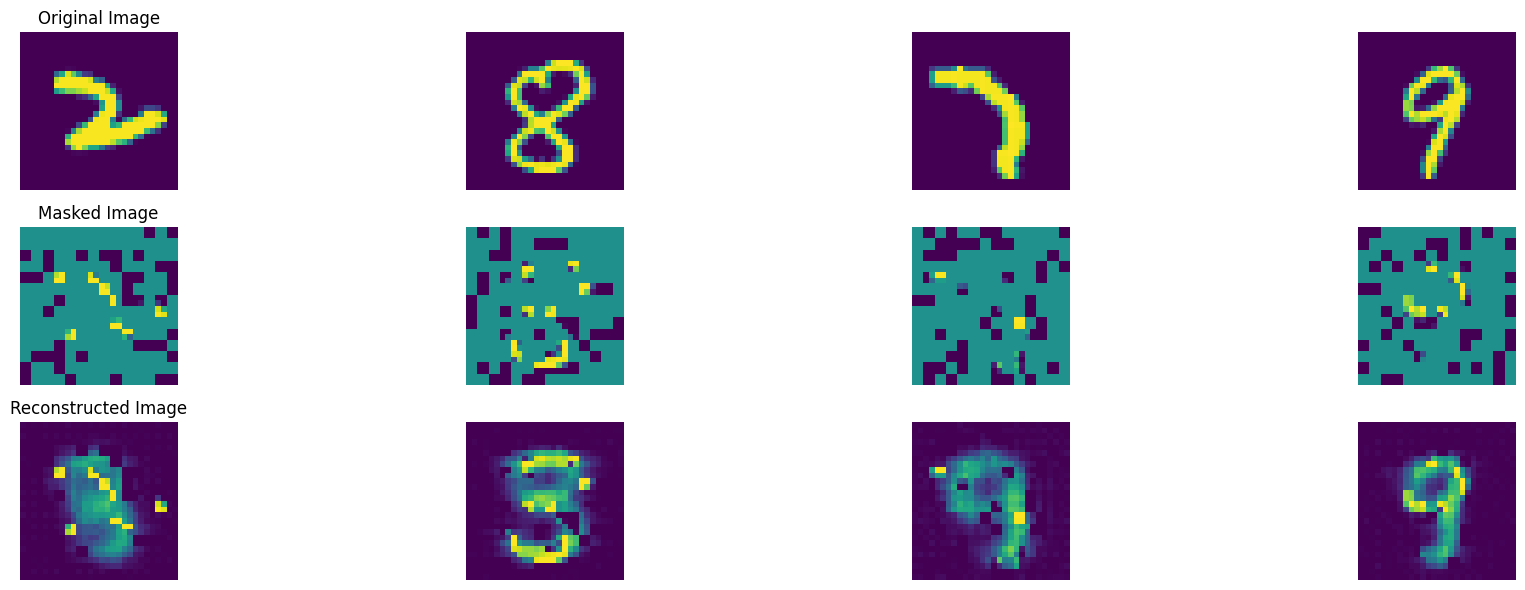

100%|██████████| 188/188 [00:39<00:00,  4.82it/s]


In epoch 37, average traning loss is 0.18960486193920703.
=================== EPOCH:  38  ===================


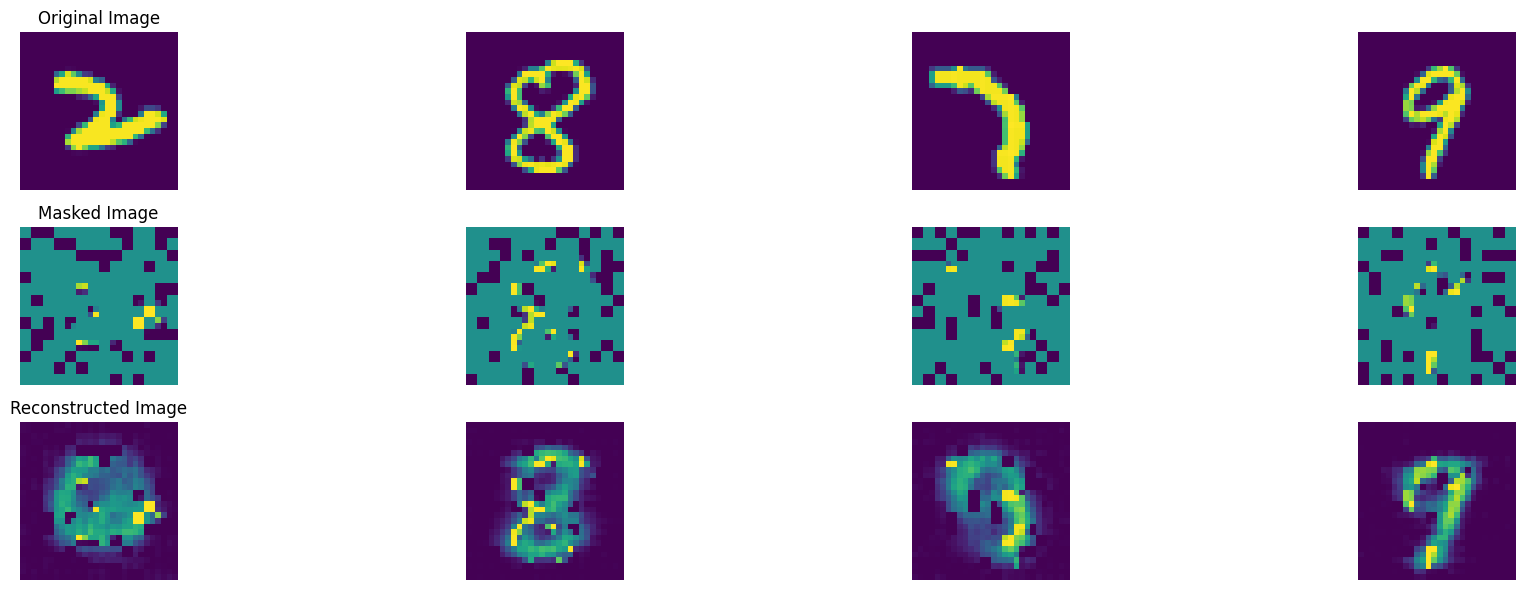

100%|██████████| 188/188 [00:39<00:00,  4.80it/s]


In epoch 38, average traning loss is 0.18687757683244158.
=================== EPOCH:  39  ===================


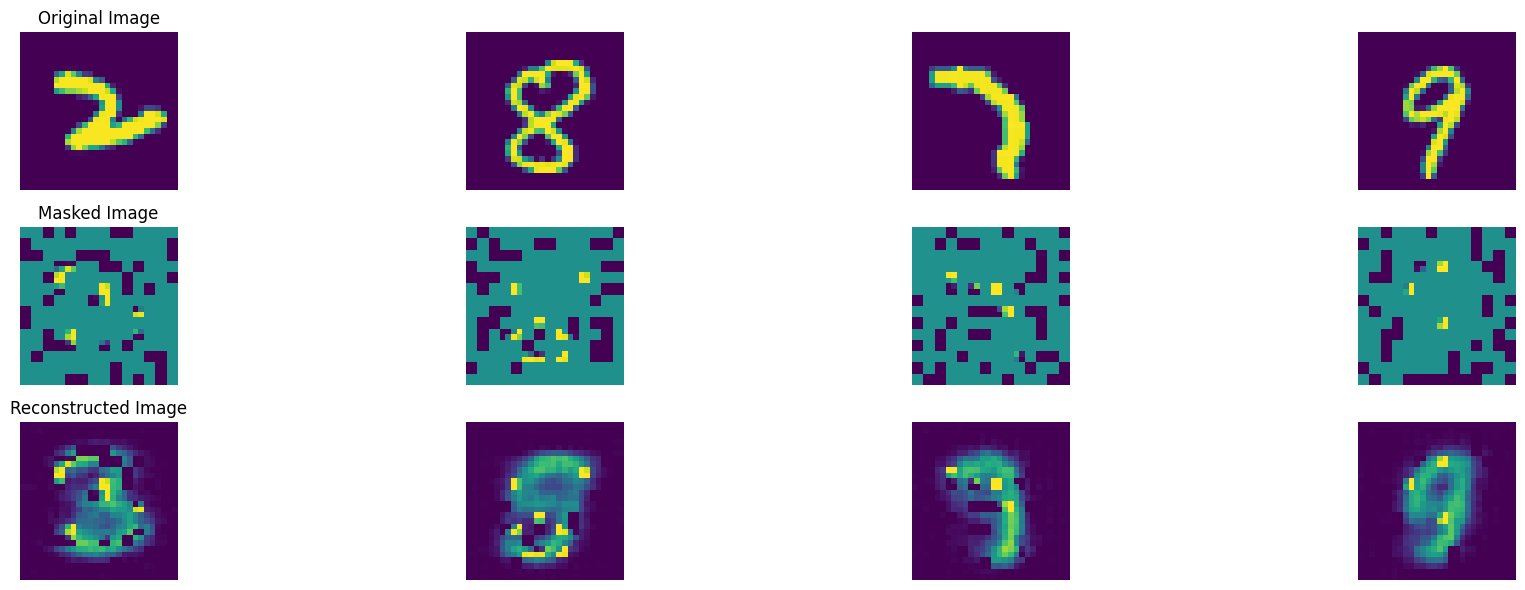

100%|██████████| 188/188 [00:40<00:00,  4.64it/s]


In epoch 39, average traning loss is 0.1839500954969132.
=================== EPOCH:  40  ===================


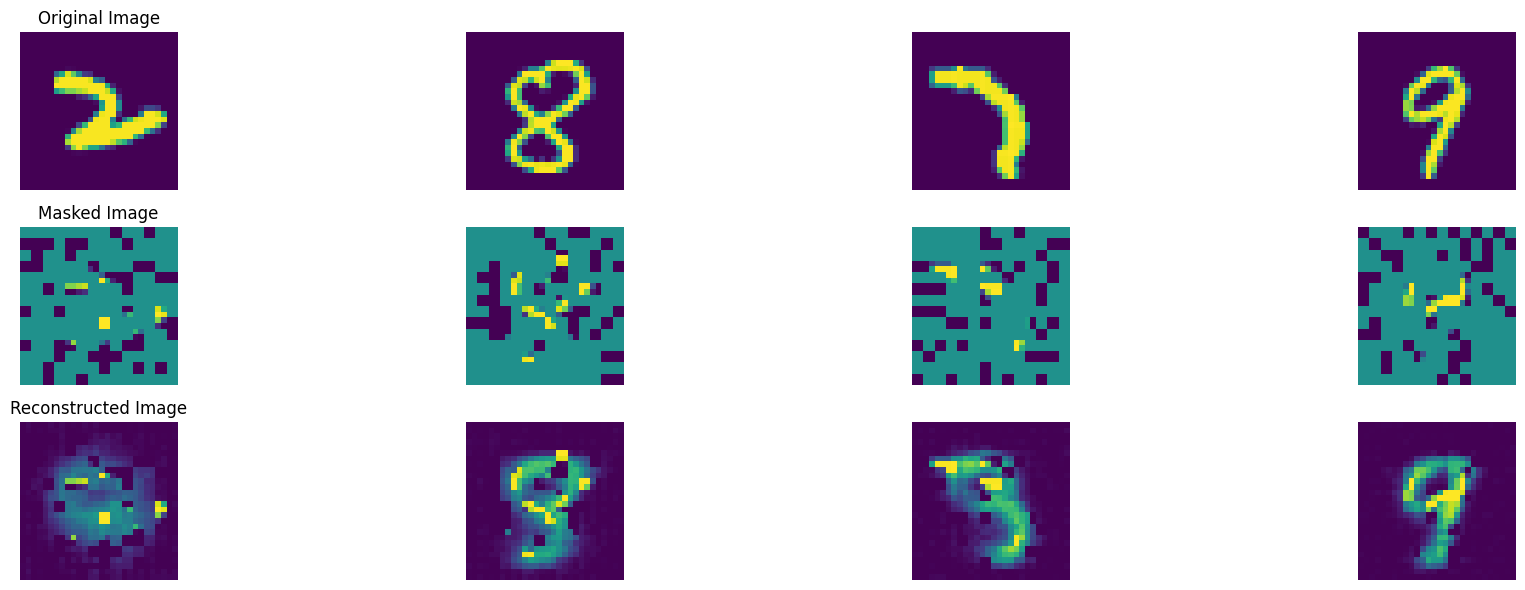

100%|██████████| 188/188 [00:39<00:00,  4.71it/s]


In epoch 40, average traning loss is 0.18098429978844968.
=================== EPOCH:  41  ===================


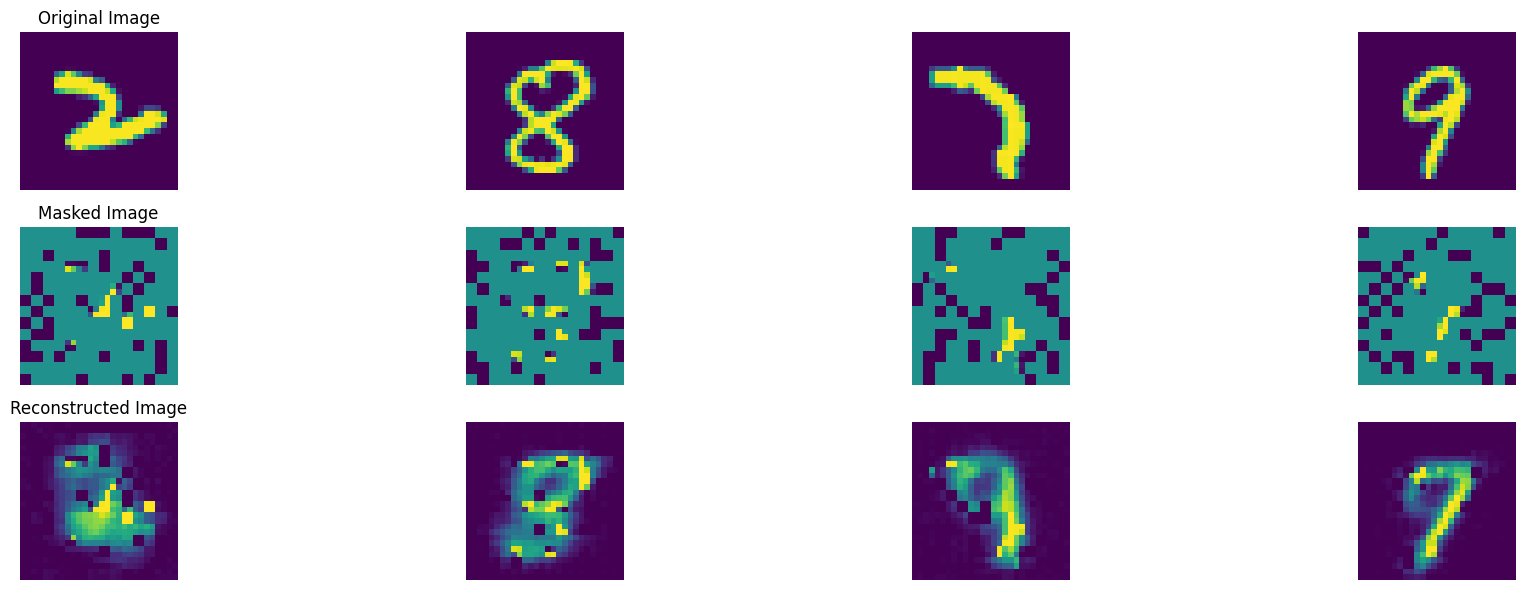

100%|██████████| 188/188 [00:40<00:00,  4.64it/s]


In epoch 41, average traning loss is 0.17660721431070187.
=================== EPOCH:  42  ===================


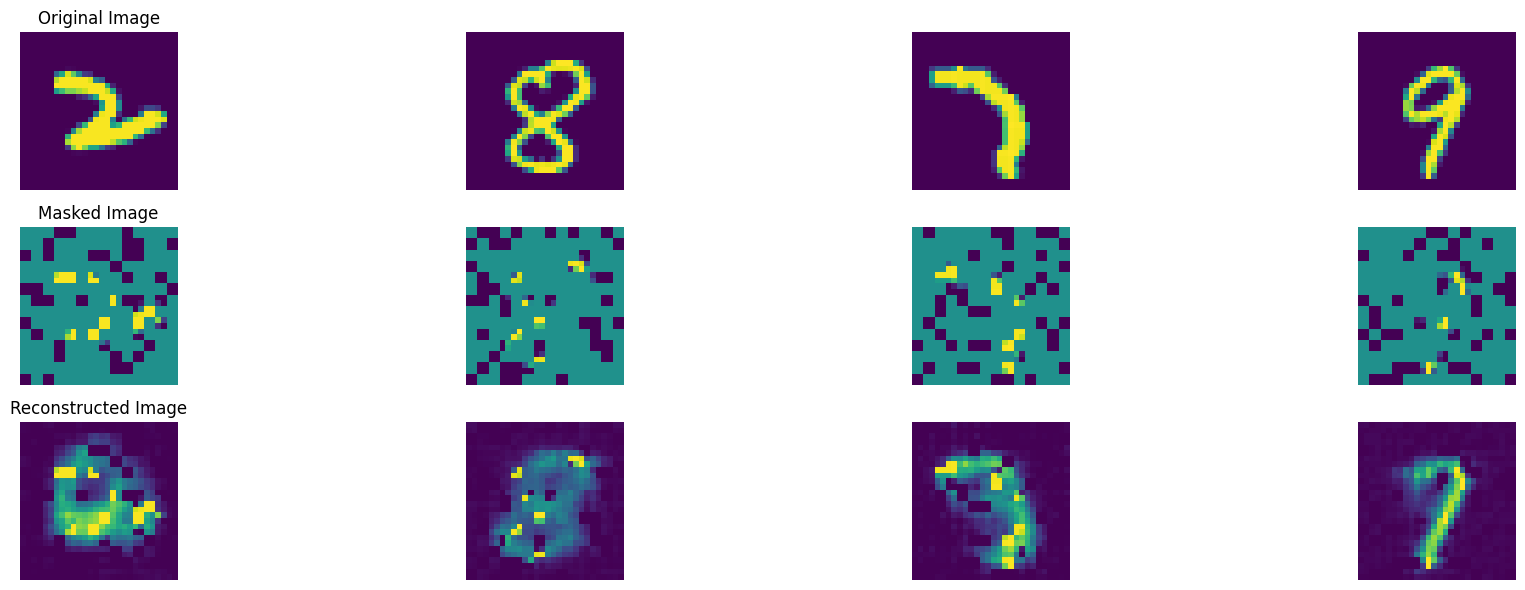

100%|██████████| 188/188 [00:40<00:00,  4.61it/s]


In epoch 42, average traning loss is 0.17303656913498613.
=================== EPOCH:  43  ===================


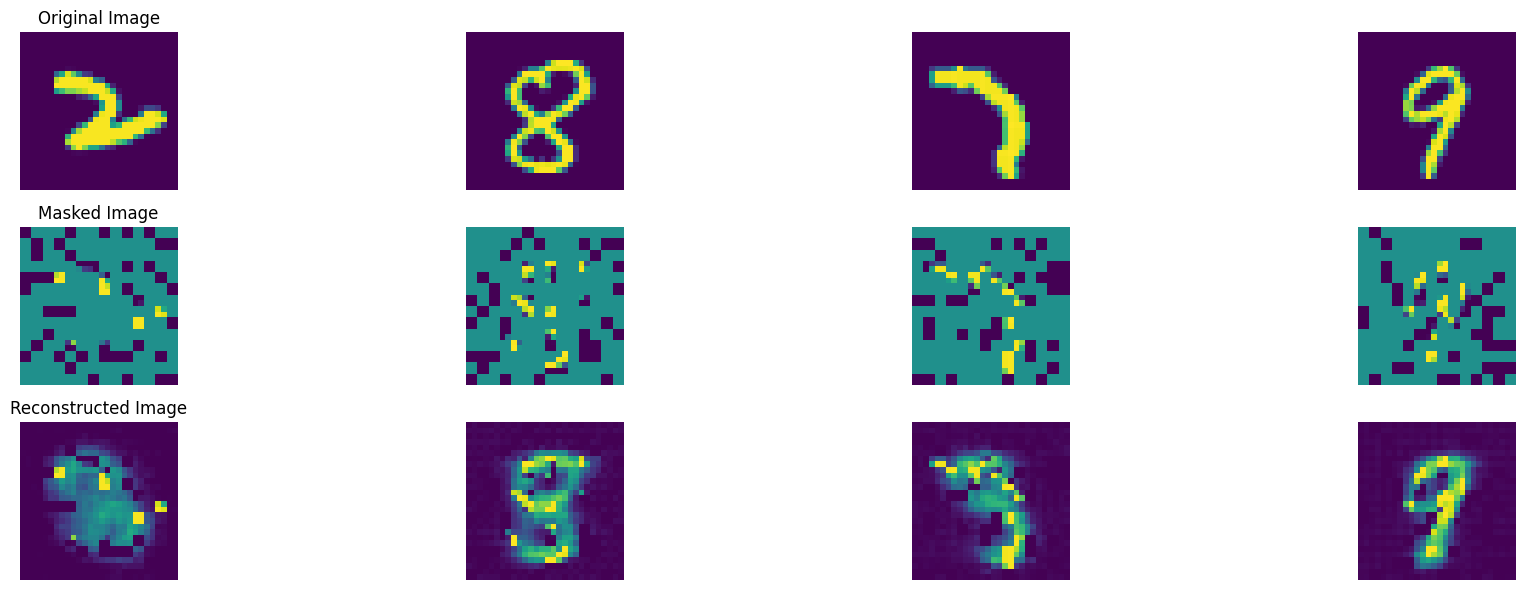

100%|██████████| 188/188 [00:40<00:00,  4.61it/s]


In epoch 43, average traning loss is 0.16969363399325532.
=================== EPOCH:  44  ===================


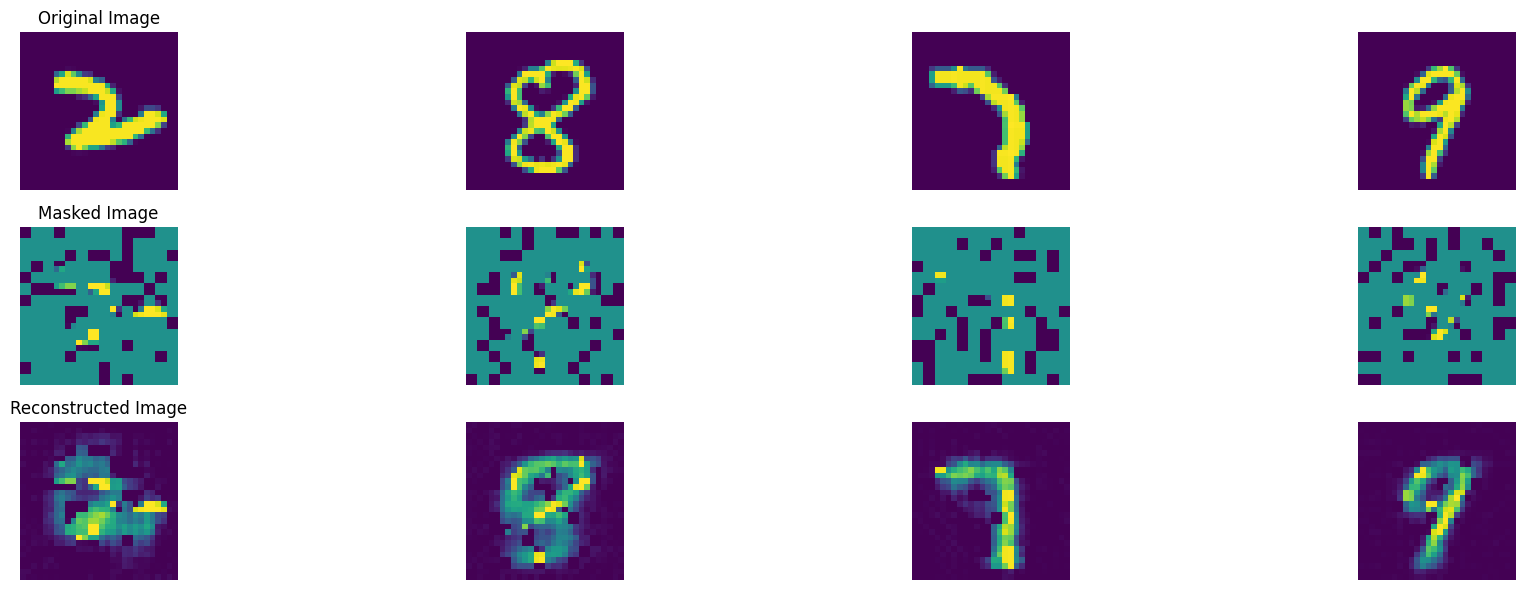

100%|██████████| 188/188 [00:40<00:00,  4.60it/s]


In epoch 44, average traning loss is 0.1664896656541114.
=================== EPOCH:  45  ===================


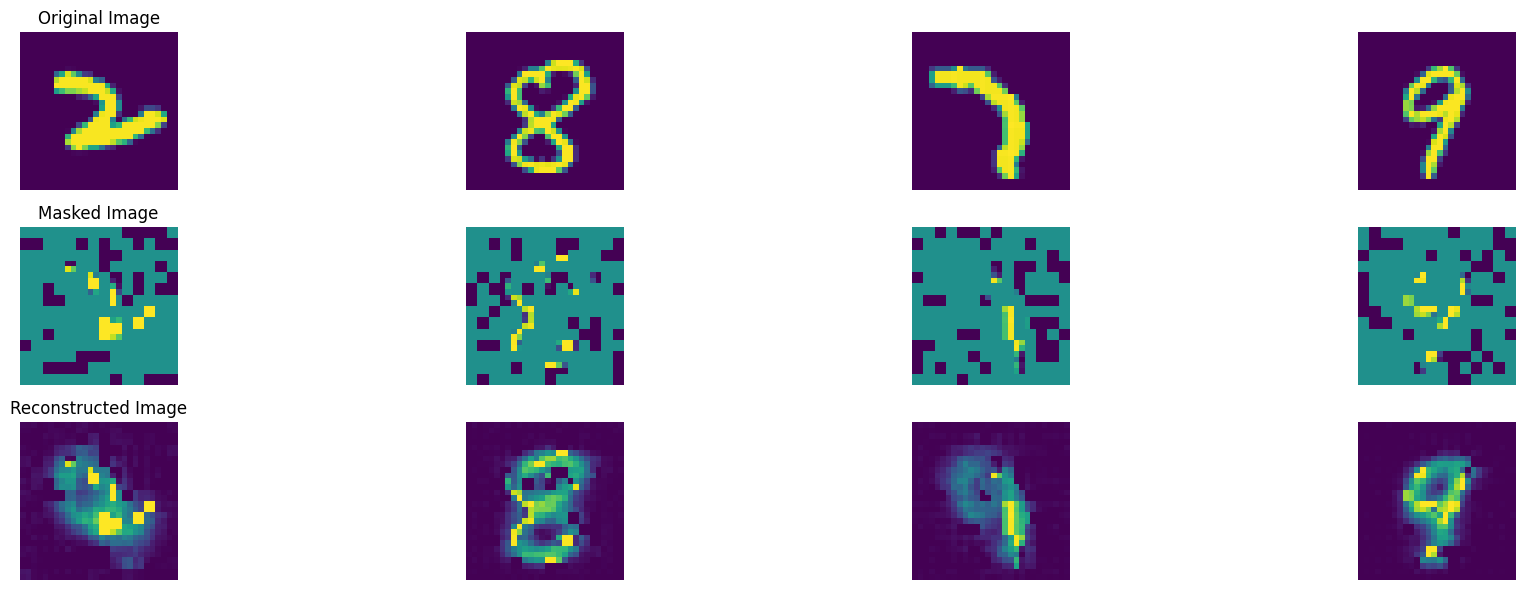

100%|██████████| 188/188 [00:40<00:00,  4.59it/s]


In epoch 45, average traning loss is 0.16302808223569648.
=================== EPOCH:  46  ===================


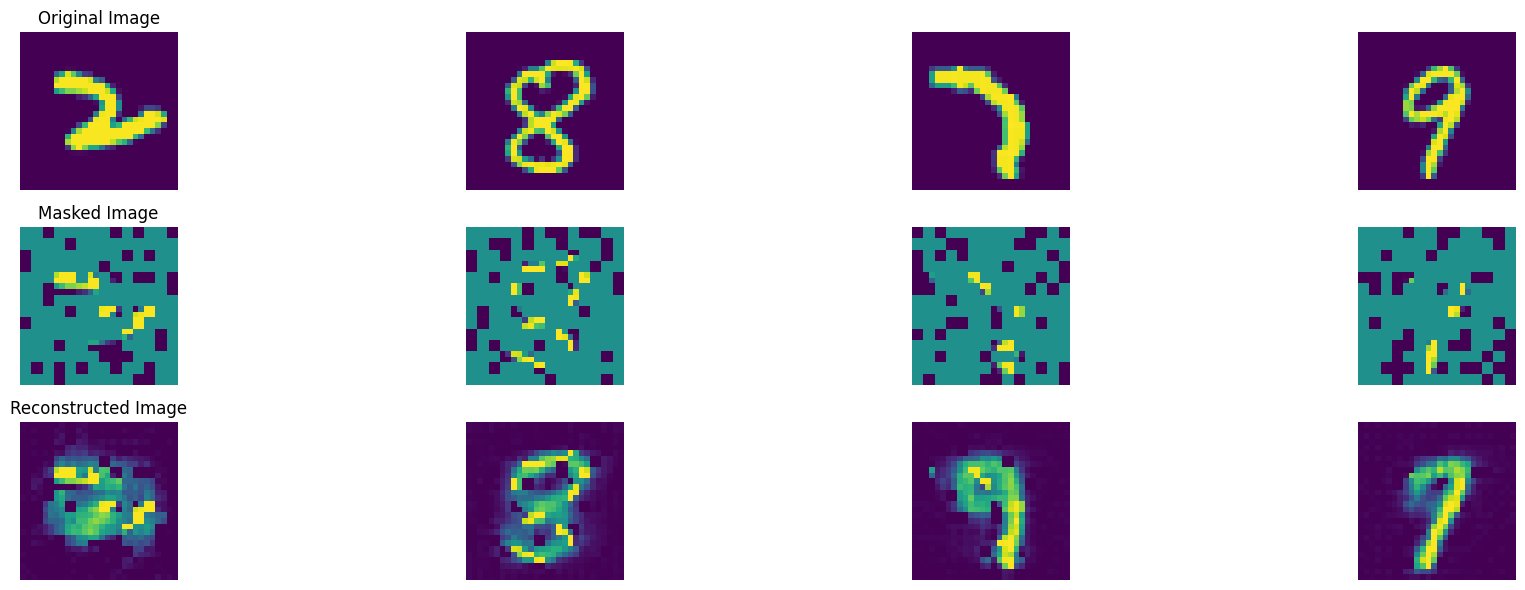

100%|██████████| 188/188 [00:40<00:00,  4.60it/s]


In epoch 46, average traning loss is 0.1600082022078494.
=================== EPOCH:  47  ===================


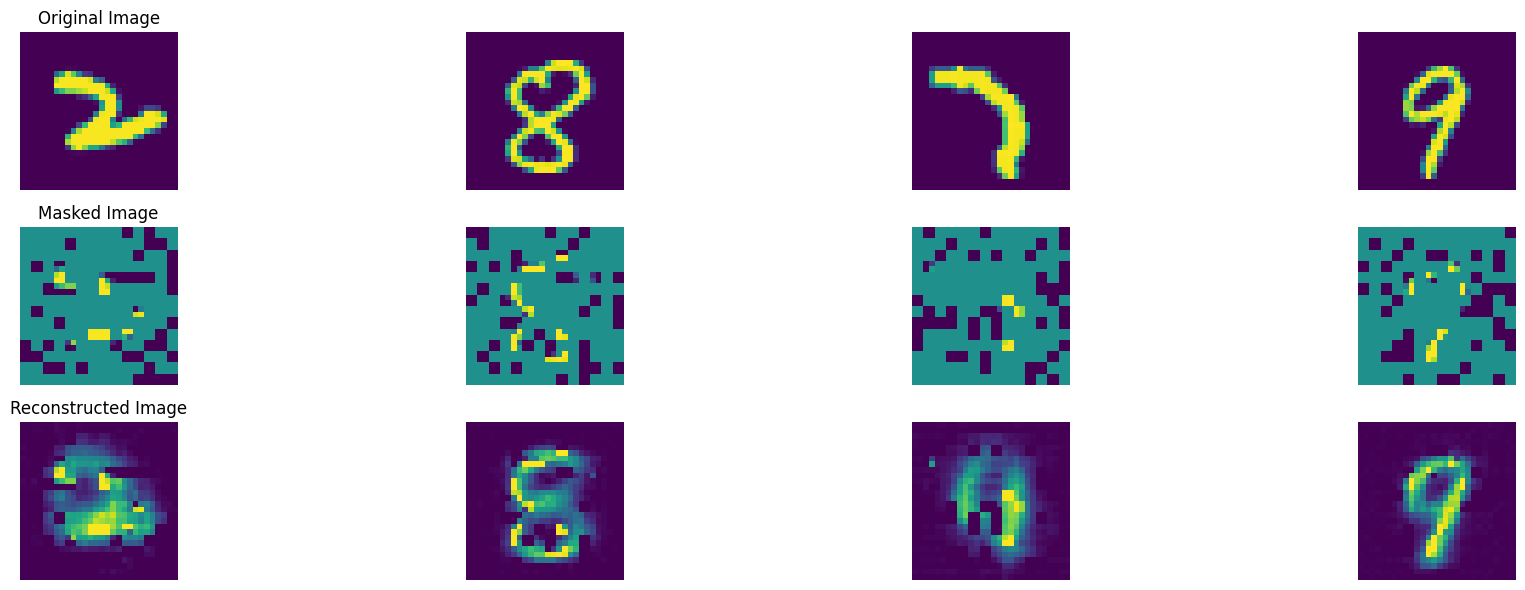

100%|██████████| 188/188 [00:40<00:00,  4.59it/s]


In epoch 47, average traning loss is 0.1570594737187345.
=================== EPOCH:  48  ===================


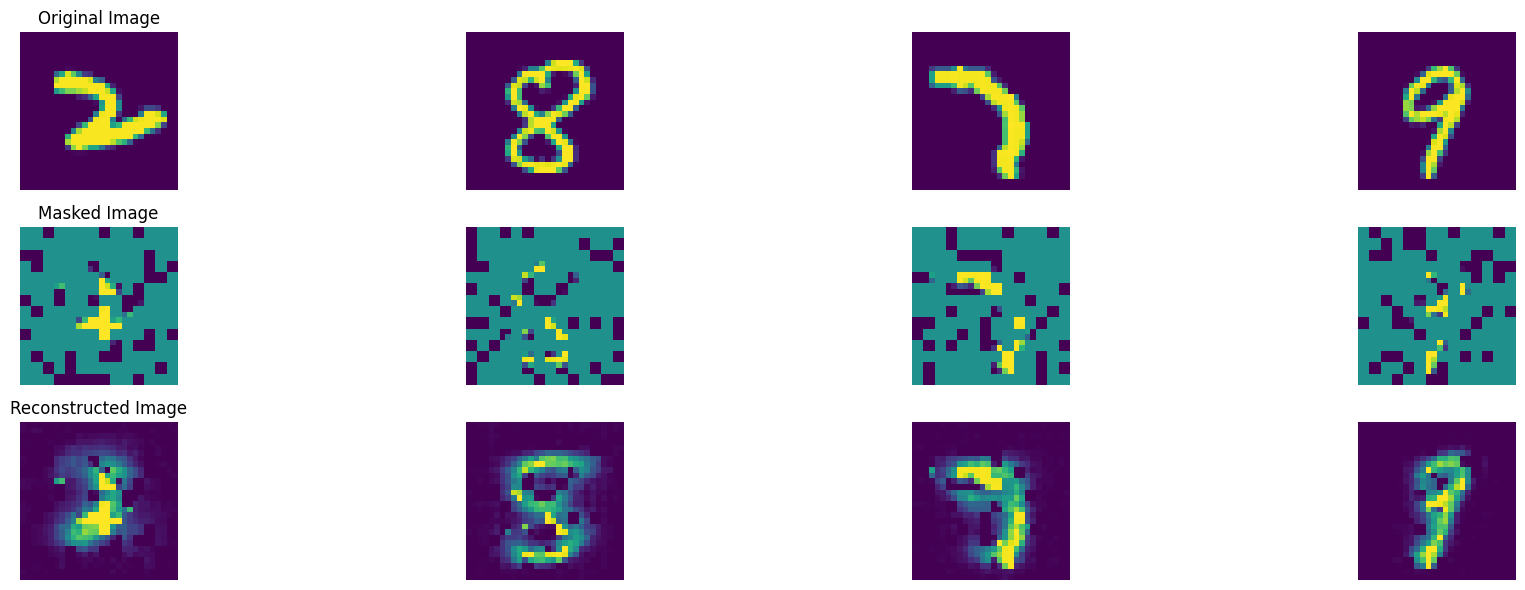

100%|██████████| 188/188 [00:41<00:00,  4.57it/s]


In epoch 48, average traning loss is 0.15302292986753138.
=================== EPOCH:  49  ===================


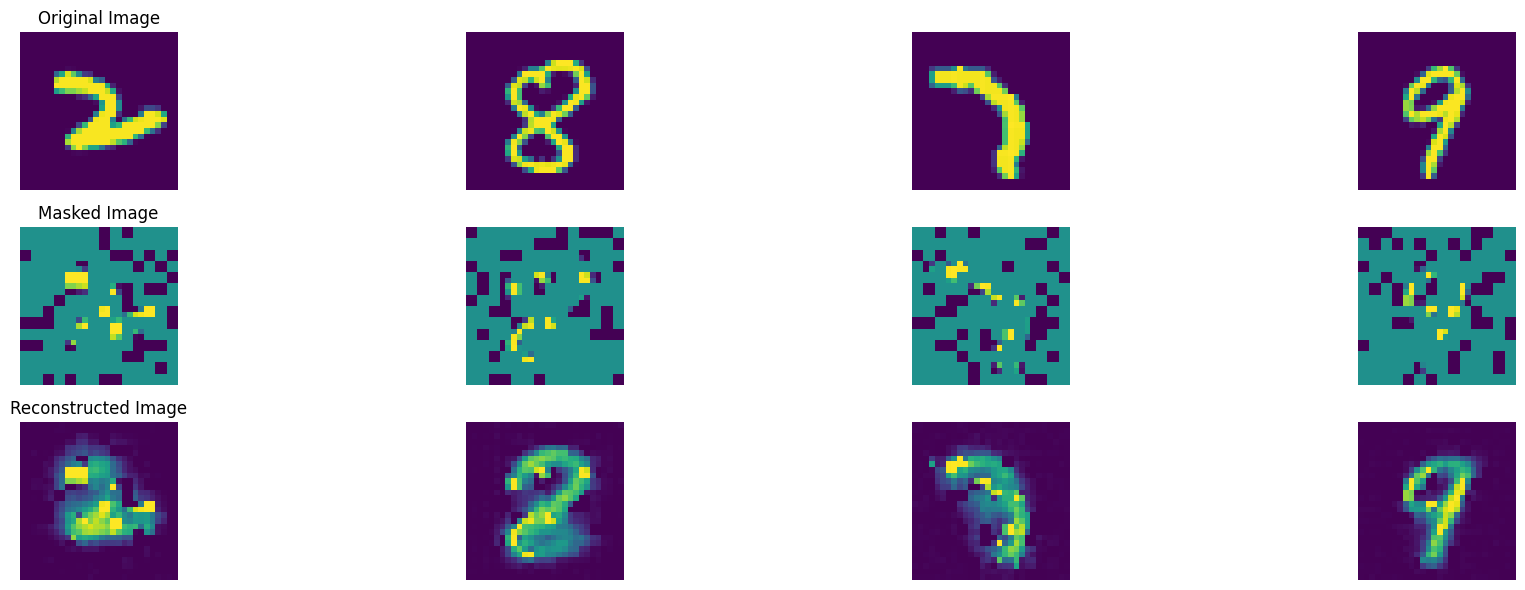

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 49, average traning loss is 0.1503441129276093.
=================== EPOCH:  50  ===================


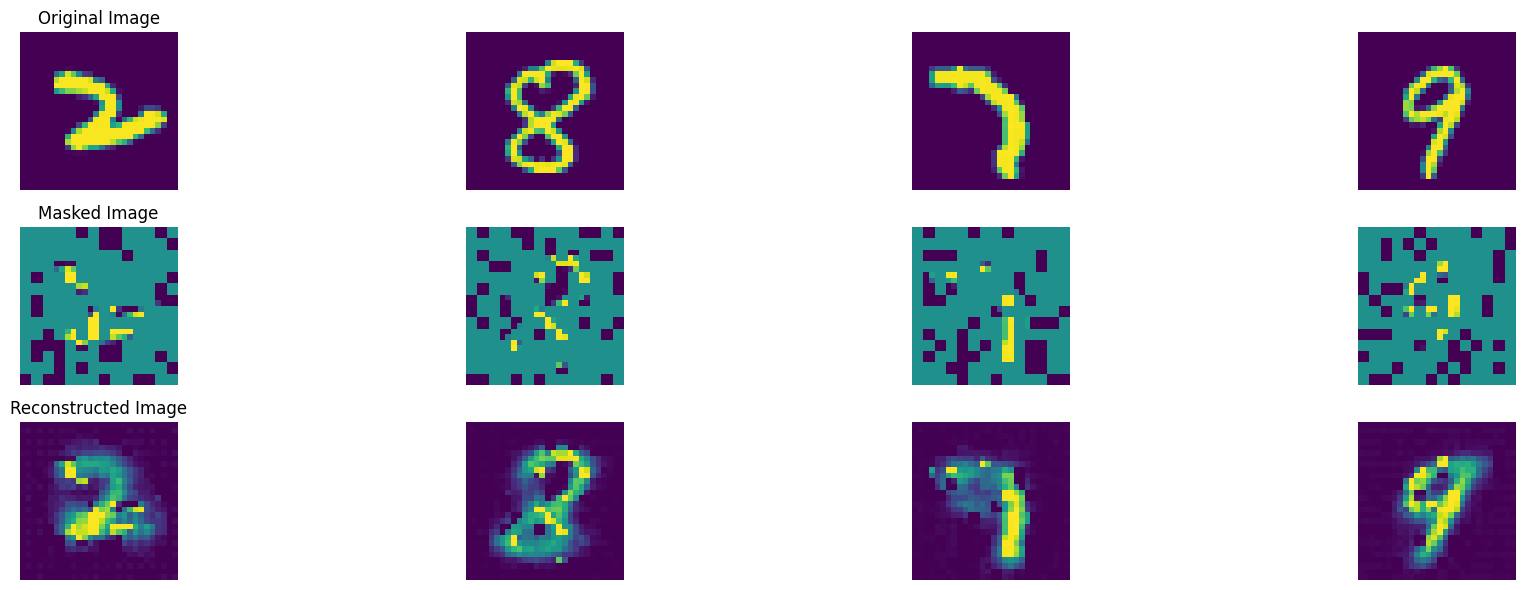

100%|██████████| 188/188 [00:40<00:00,  4.59it/s]


In epoch 50, average traning loss is 0.1474919501454272.
=================== EPOCH:  51  ===================


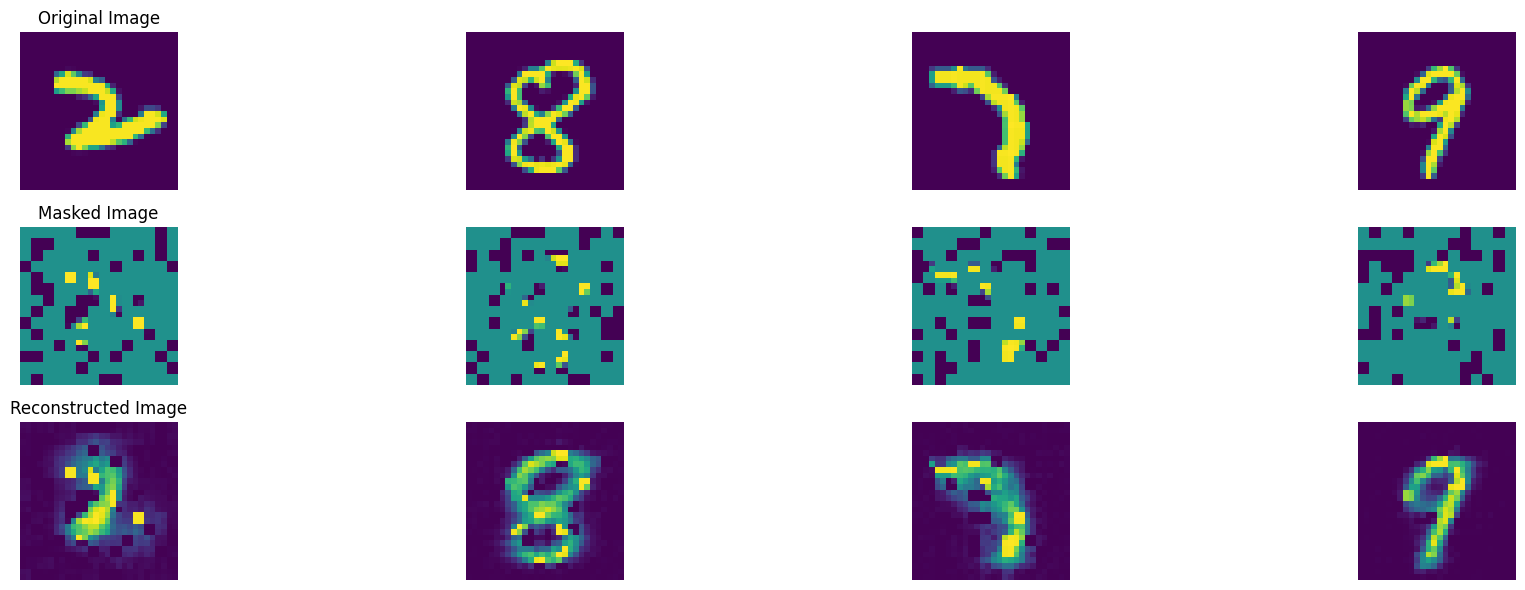

100%|██████████| 188/188 [00:41<00:00,  4.57it/s]


In epoch 51, average traning loss is 0.14446246560583723.
=================== EPOCH:  52  ===================


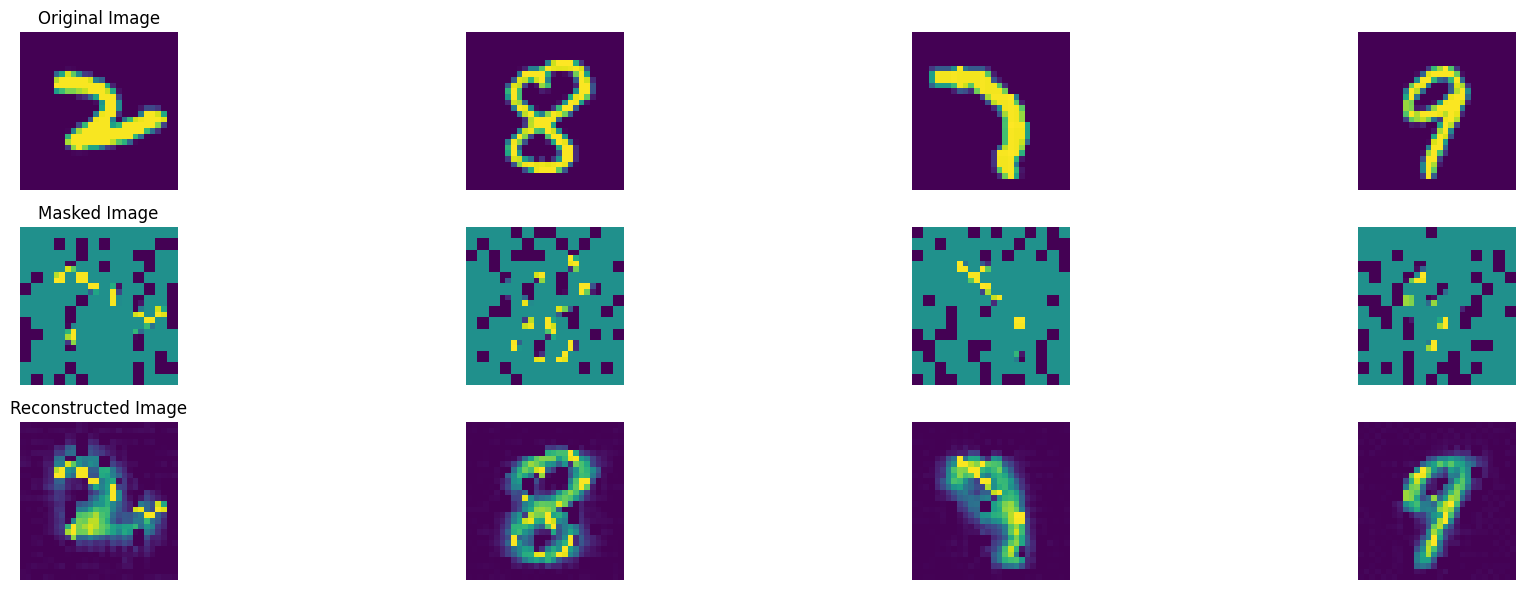

100%|██████████| 188/188 [00:41<00:00,  4.56it/s]


In epoch 52, average traning loss is 0.14112984959749467.
=================== EPOCH:  53  ===================


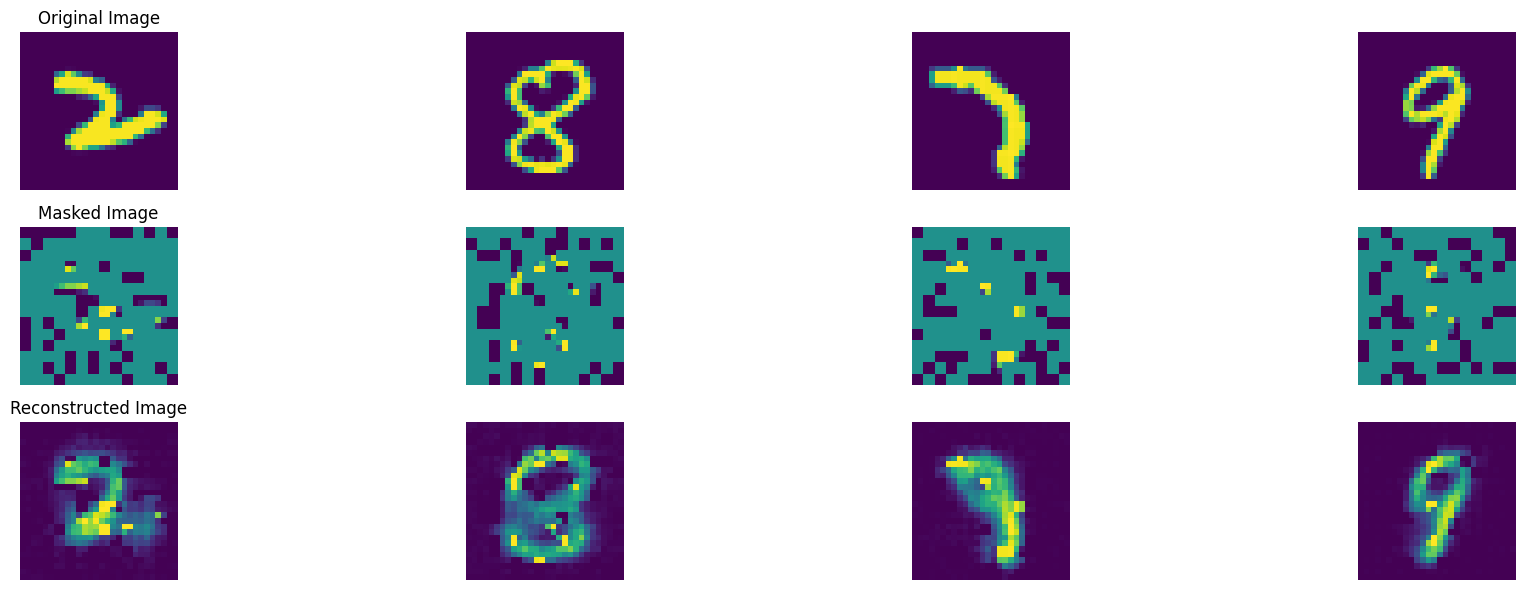

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 53, average traning loss is 0.1381561260749685.
=================== EPOCH:  54  ===================


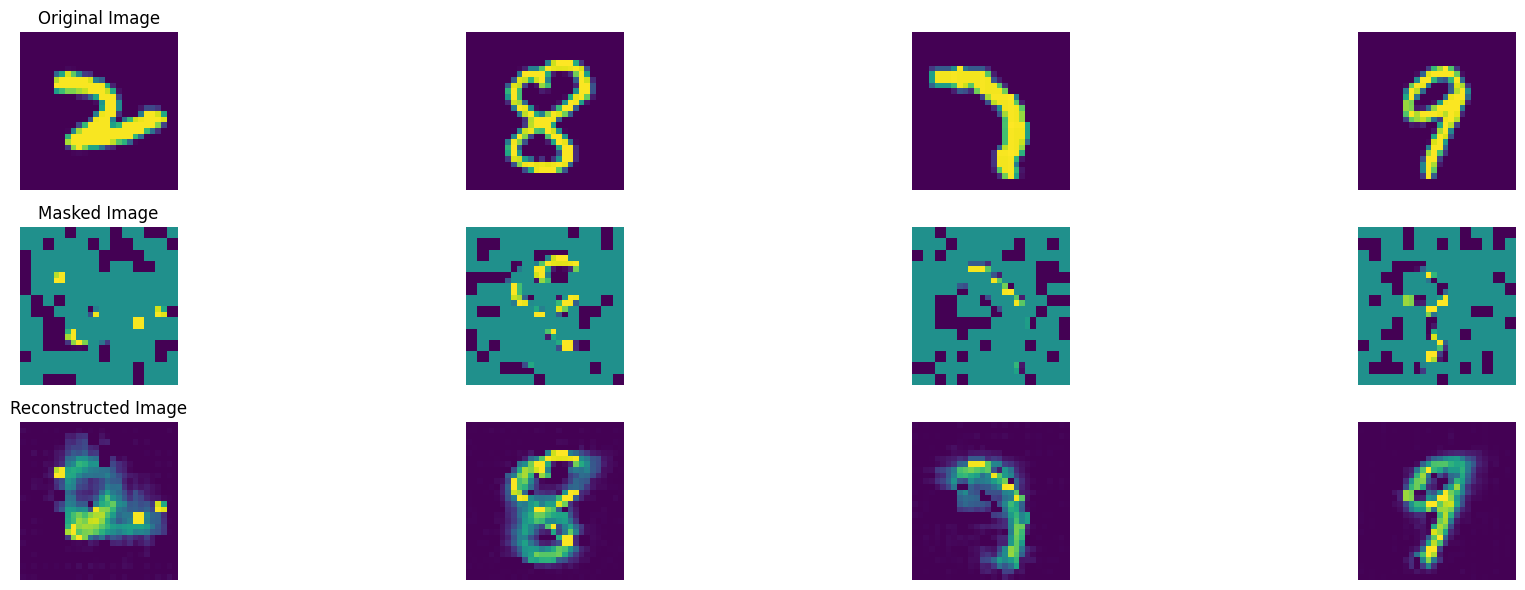

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 54, average traning loss is 0.13510399894352923.
=================== EPOCH:  55  ===================


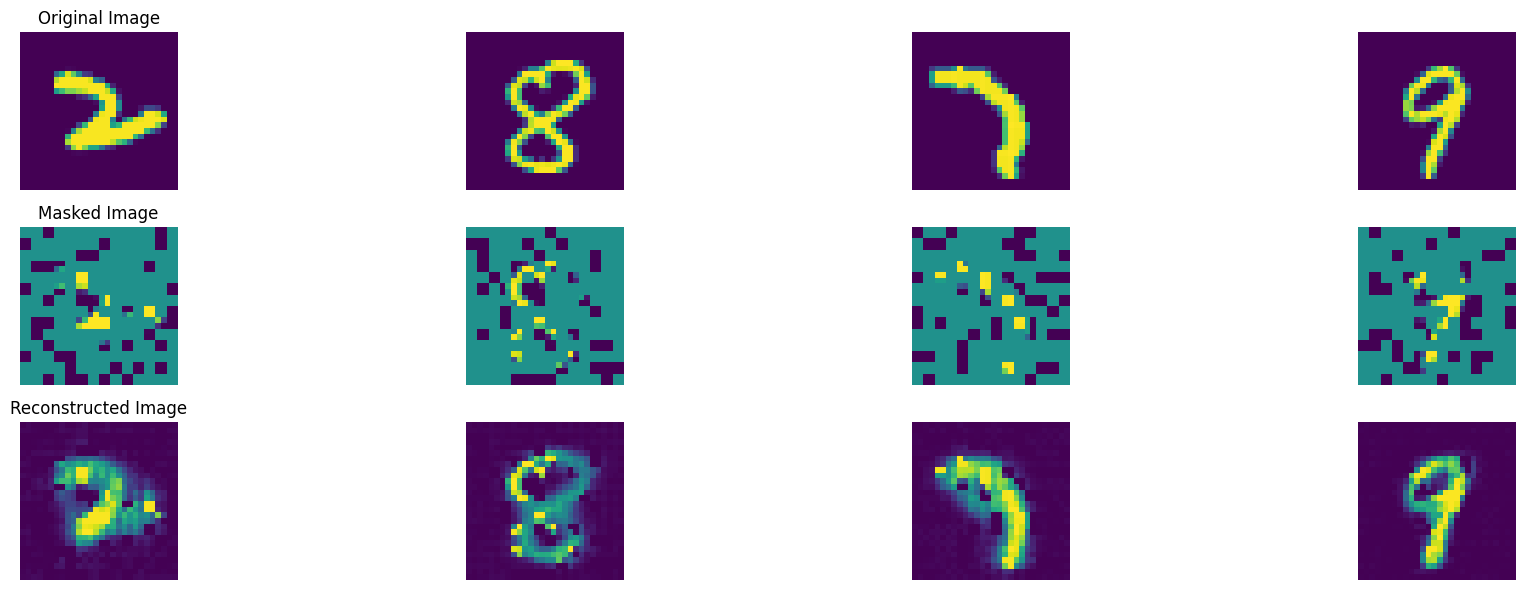

100%|██████████| 188/188 [00:41<00:00,  4.57it/s]


In epoch 55, average traning loss is 0.1323880203306041.
=================== EPOCH:  56  ===================


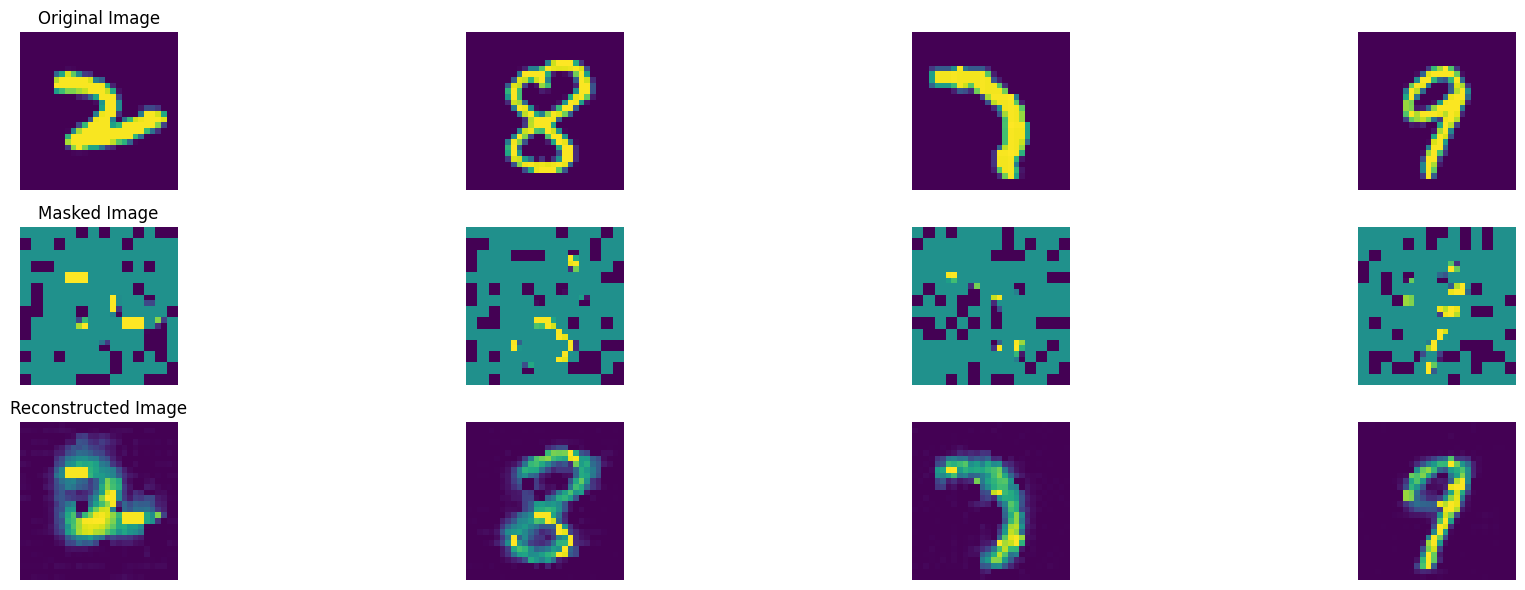

100%|██████████| 188/188 [00:39<00:00,  4.76it/s]


In epoch 56, average traning loss is 0.12946193657339888.
=================== EPOCH:  57  ===================


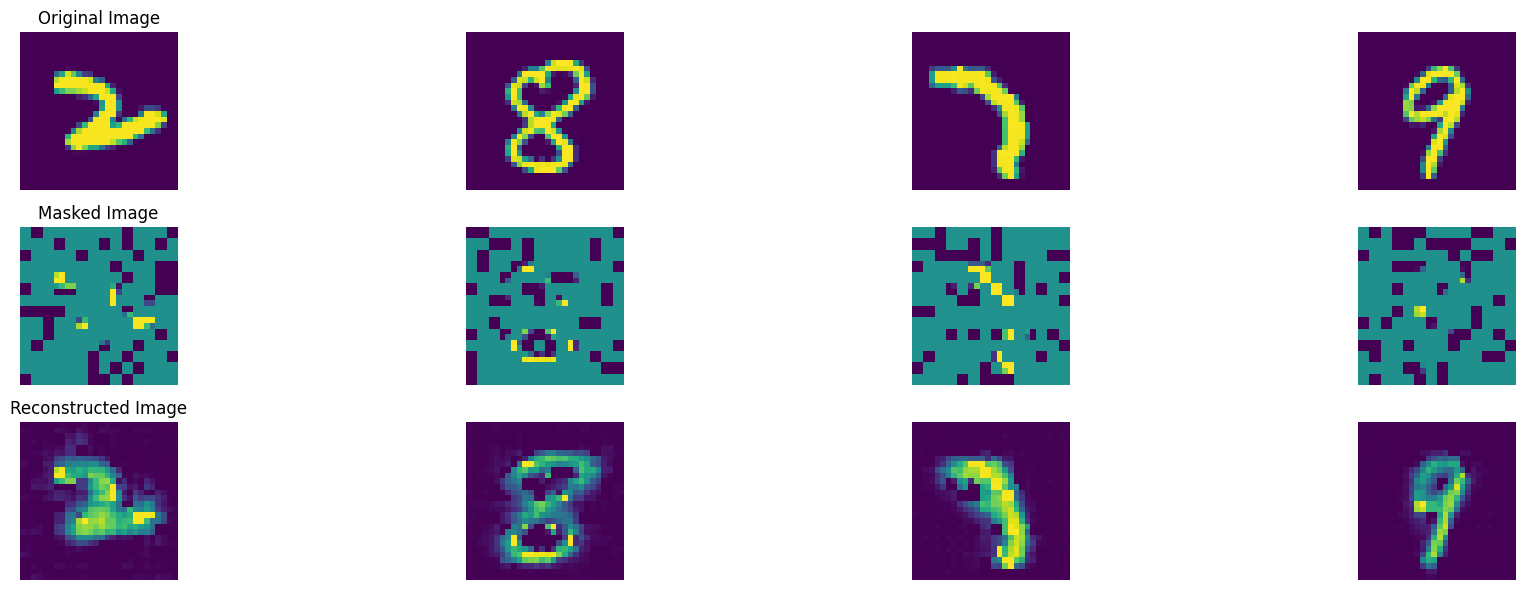

100%|██████████| 188/188 [00:40<00:00,  4.66it/s]


In epoch 57, average traning loss is 0.12660717417268044.
=================== EPOCH:  58  ===================


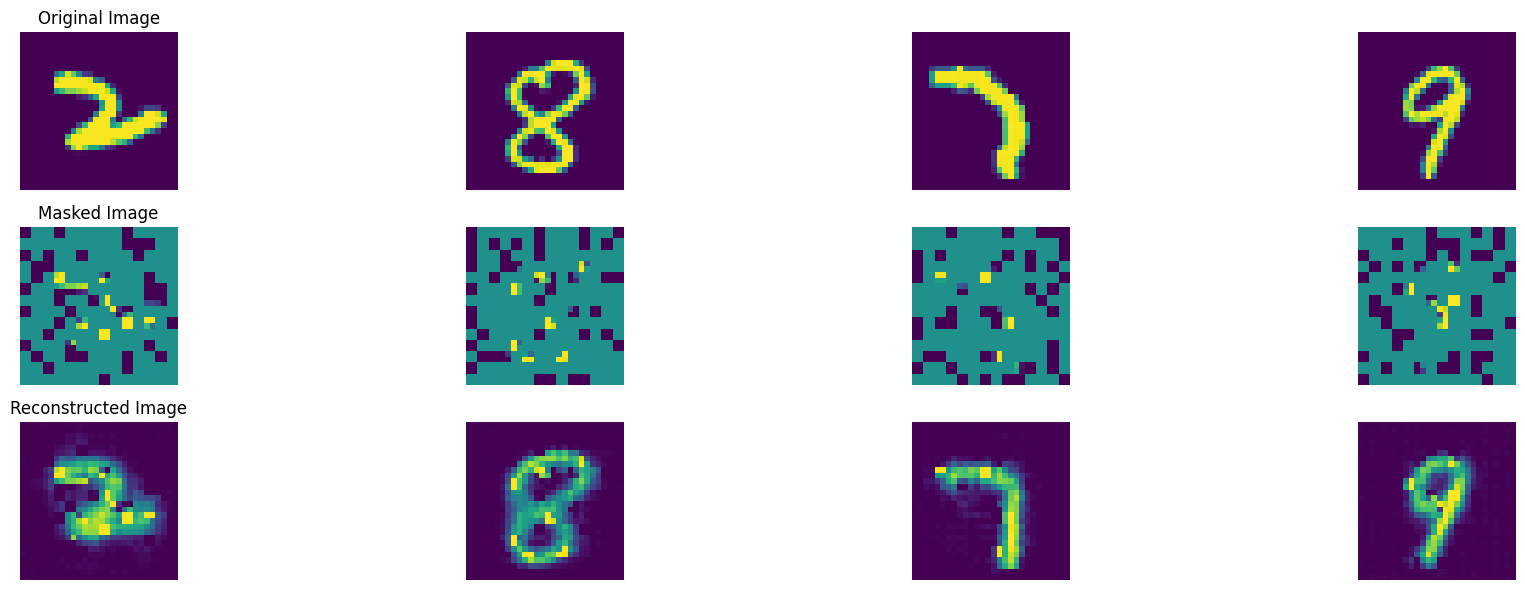

100%|██████████| 188/188 [00:39<00:00,  4.81it/s]


In epoch 58, average traning loss is 0.12405058059920655.
=================== EPOCH:  59  ===================


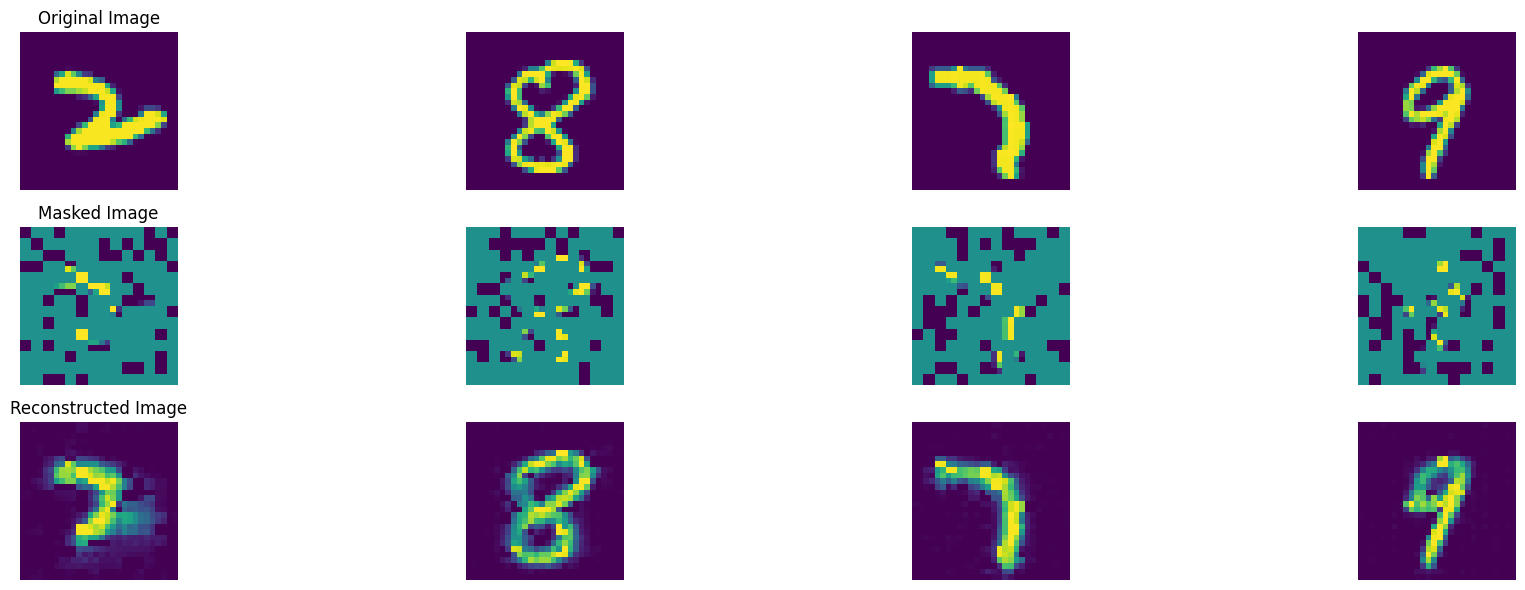

100%|██████████| 188/188 [00:38<00:00,  4.85it/s]


In epoch 59, average traning loss is 0.12136766591921766.
=================== EPOCH:  60  ===================


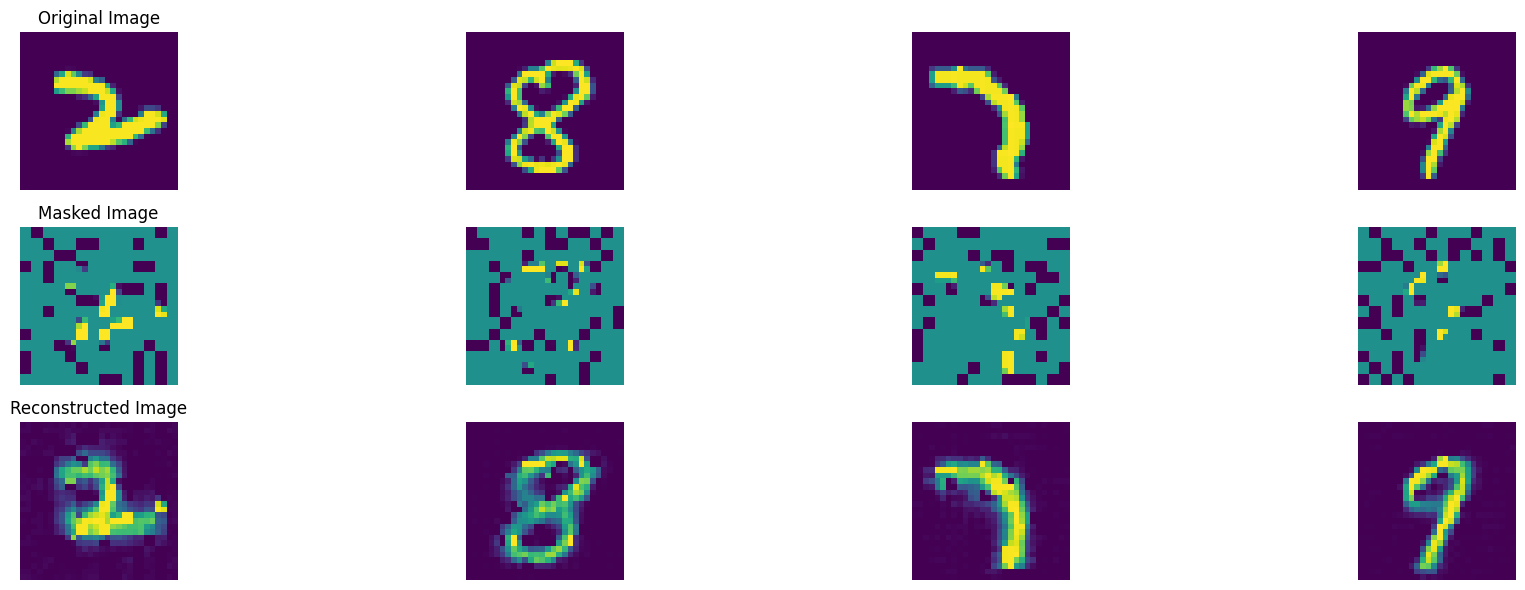

100%|██████████| 188/188 [00:39<00:00,  4.80it/s]


In epoch 60, average traning loss is 0.118706340921369.
=================== EPOCH:  61  ===================


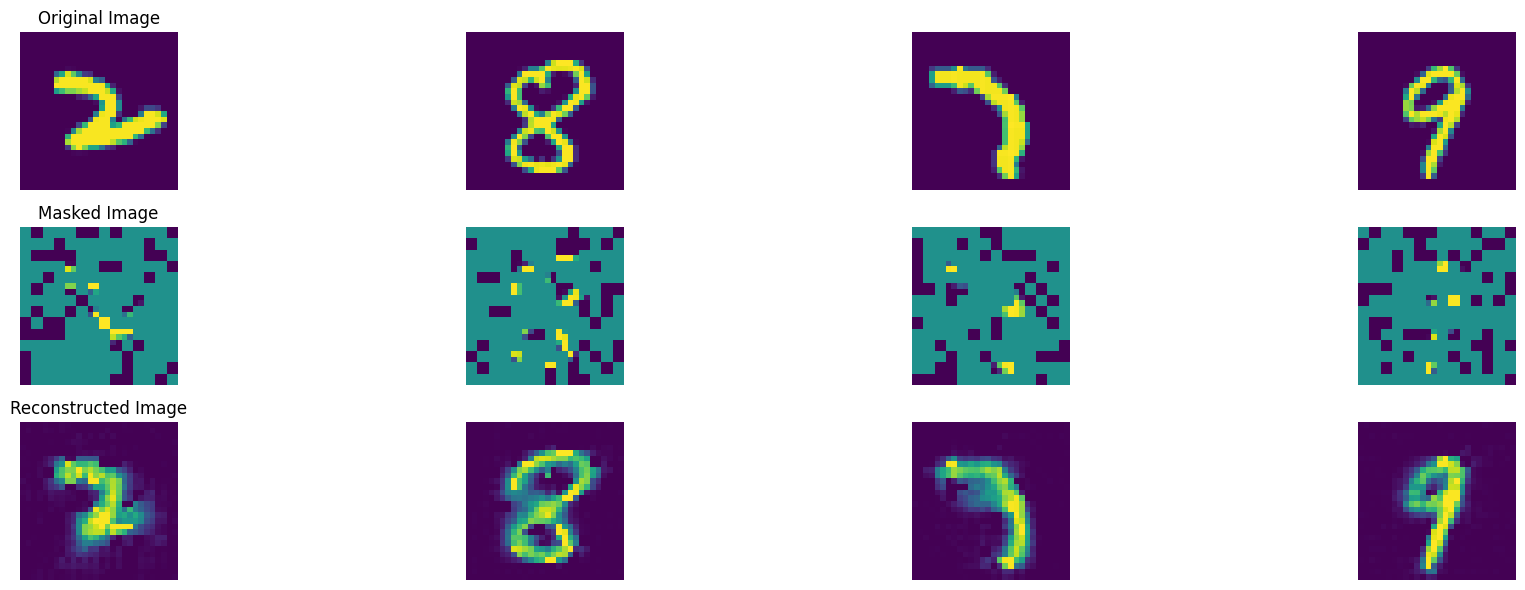

100%|██████████| 188/188 [00:39<00:00,  4.81it/s]


In epoch 61, average traning loss is 0.11648970132971063.
=================== EPOCH:  62  ===================


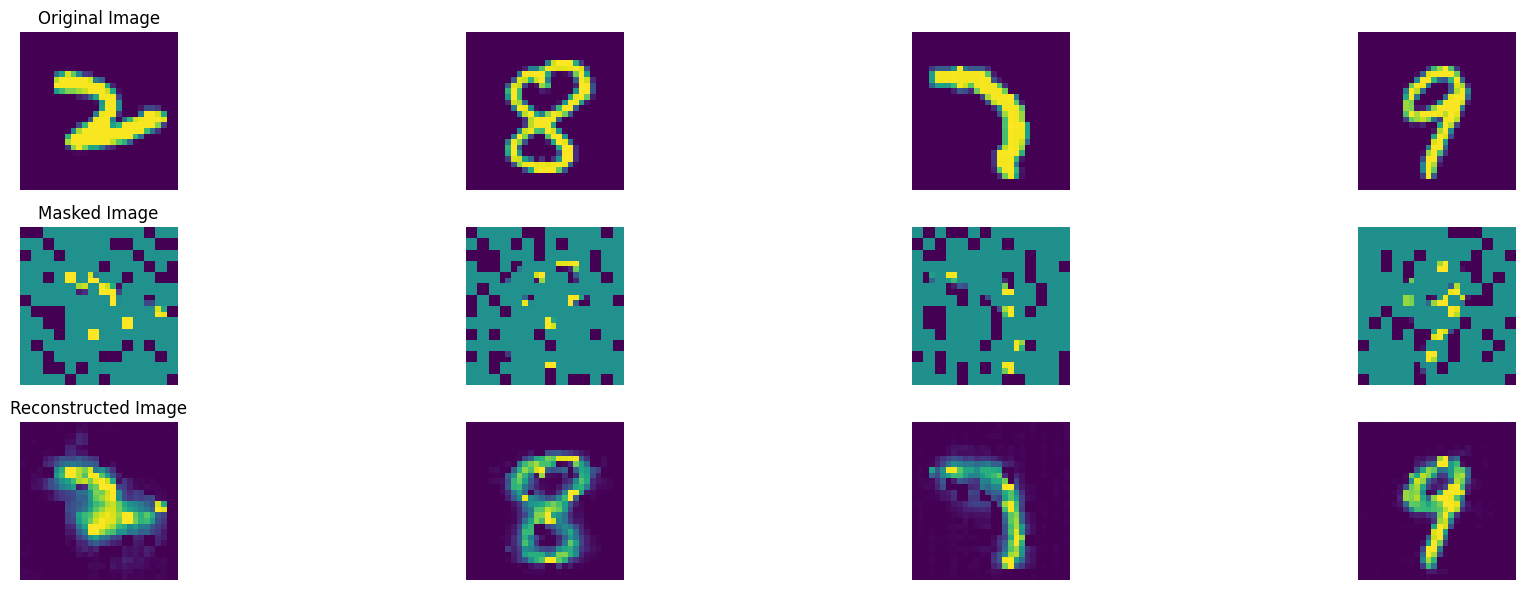

100%|██████████| 188/188 [00:39<00:00,  4.70it/s]


In epoch 62, average traning loss is 0.1138854776608183.
=================== EPOCH:  63  ===================


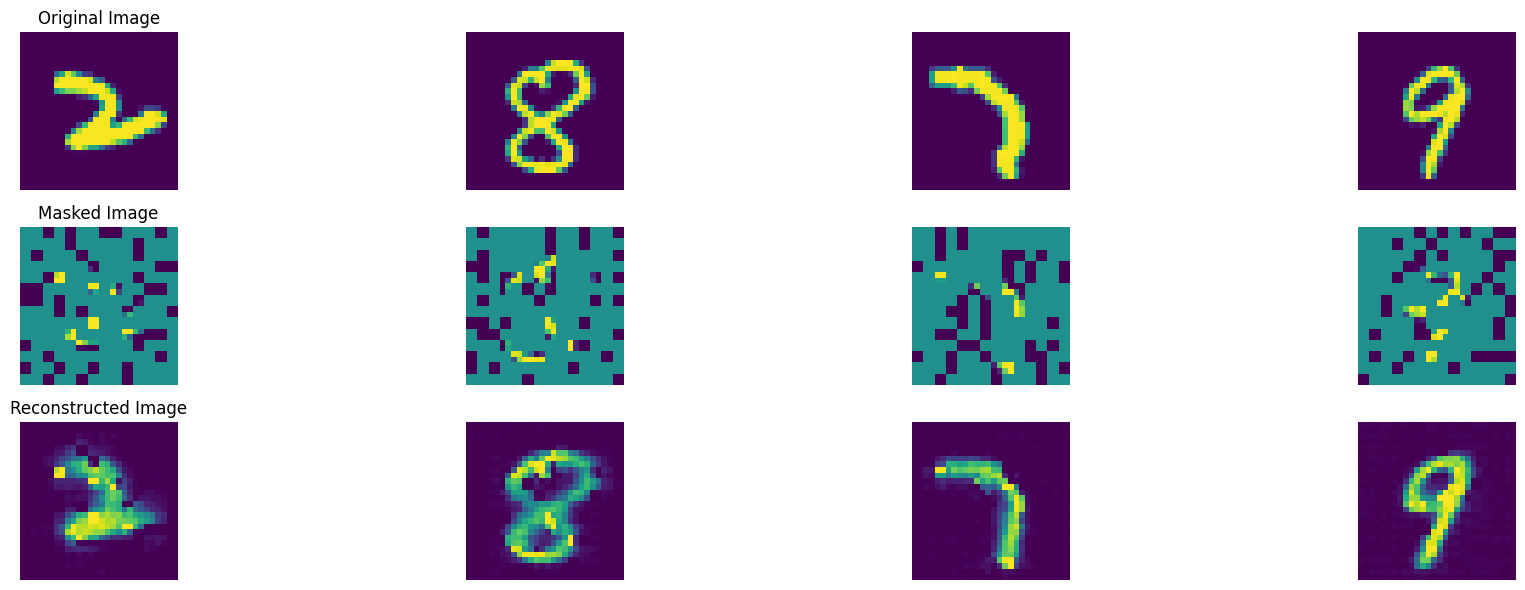

100%|██████████| 188/188 [00:40<00:00,  4.61it/s]


In epoch 63, average traning loss is 0.11109182452584834.
=================== EPOCH:  64  ===================


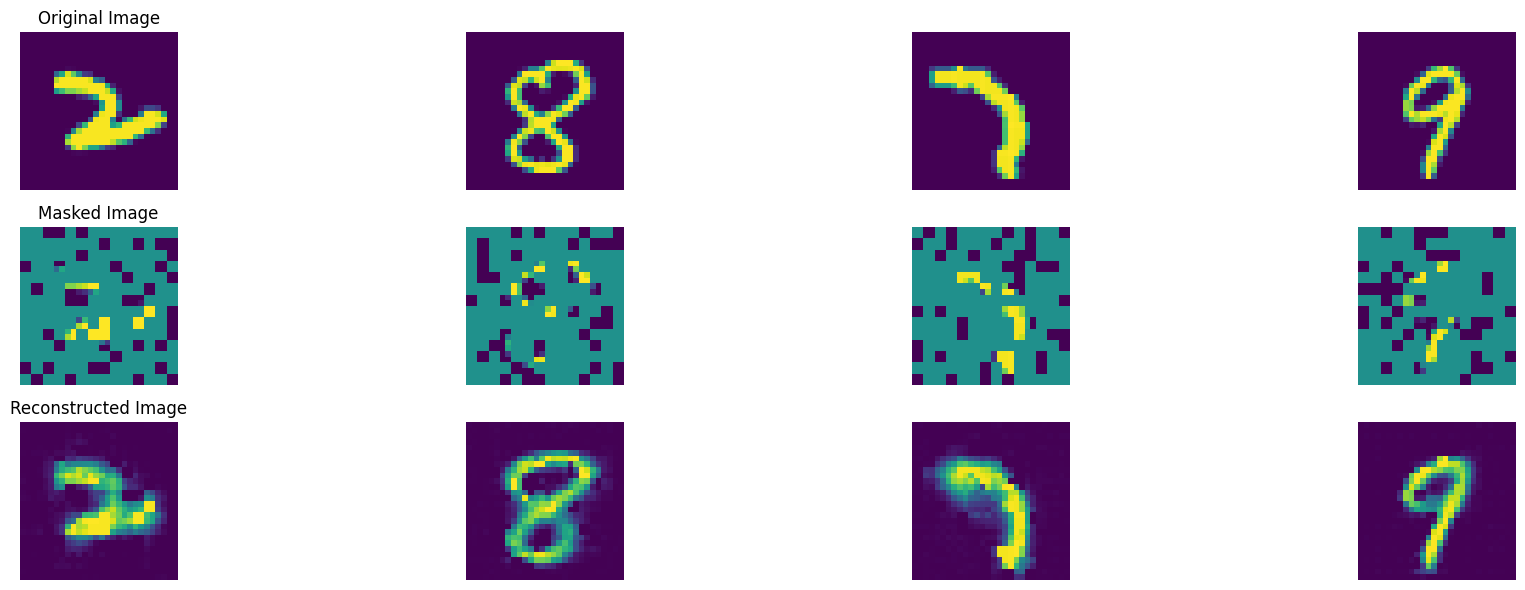

100%|██████████| 188/188 [00:40<00:00,  4.60it/s]


In epoch 64, average traning loss is 0.10865113797022942.
=================== EPOCH:  65  ===================


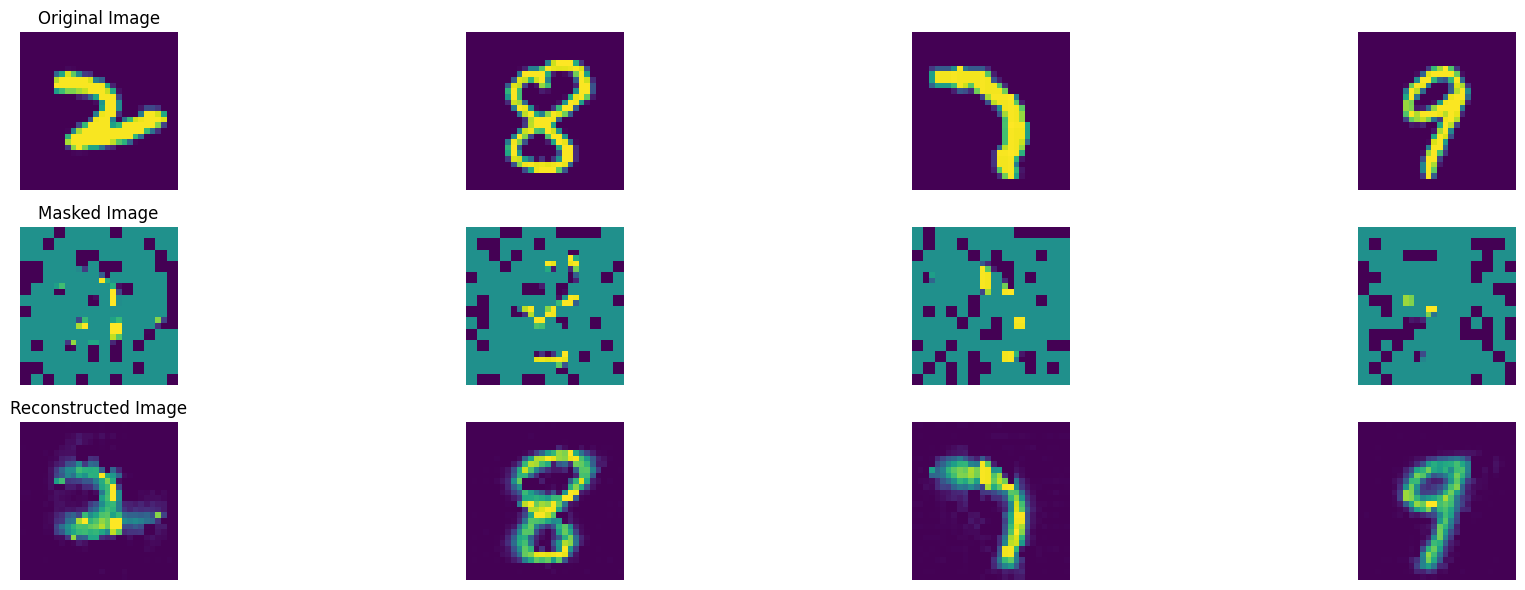

100%|██████████| 188/188 [00:40<00:00,  4.60it/s]


In epoch 65, average traning loss is 0.10616926817183799.
=================== EPOCH:  66  ===================


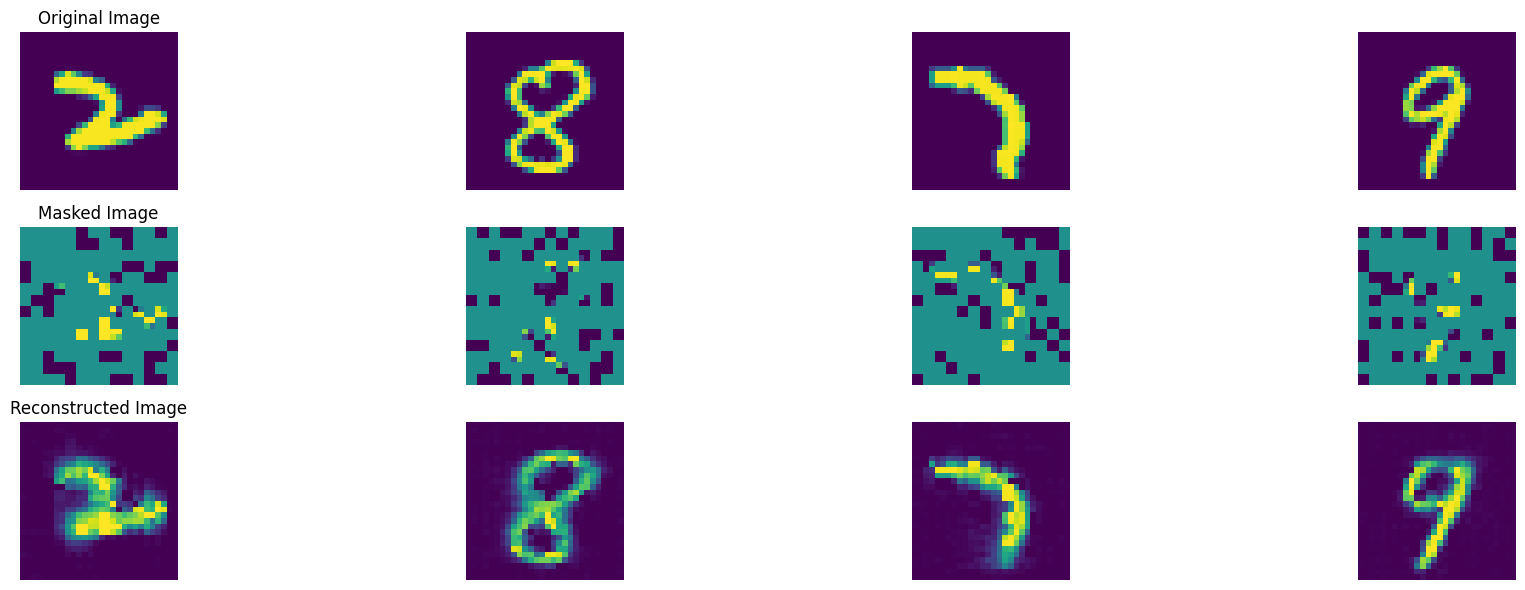

100%|██████████| 188/188 [00:39<00:00,  4.73it/s]


In epoch 66, average traning loss is 0.10347857017149316.
=================== EPOCH:  67  ===================


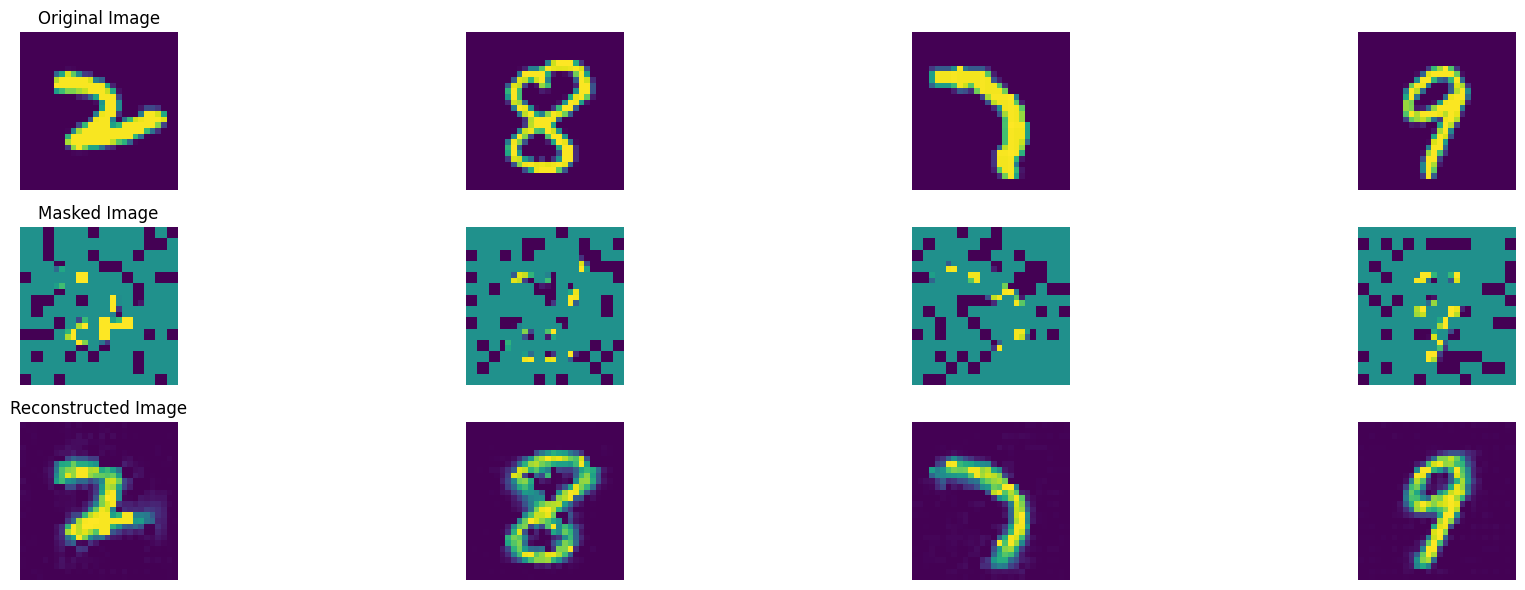

100%|██████████| 188/188 [00:38<00:00,  4.86it/s]


In epoch 67, average traning loss is 0.10166543611186615.
=================== EPOCH:  68  ===================


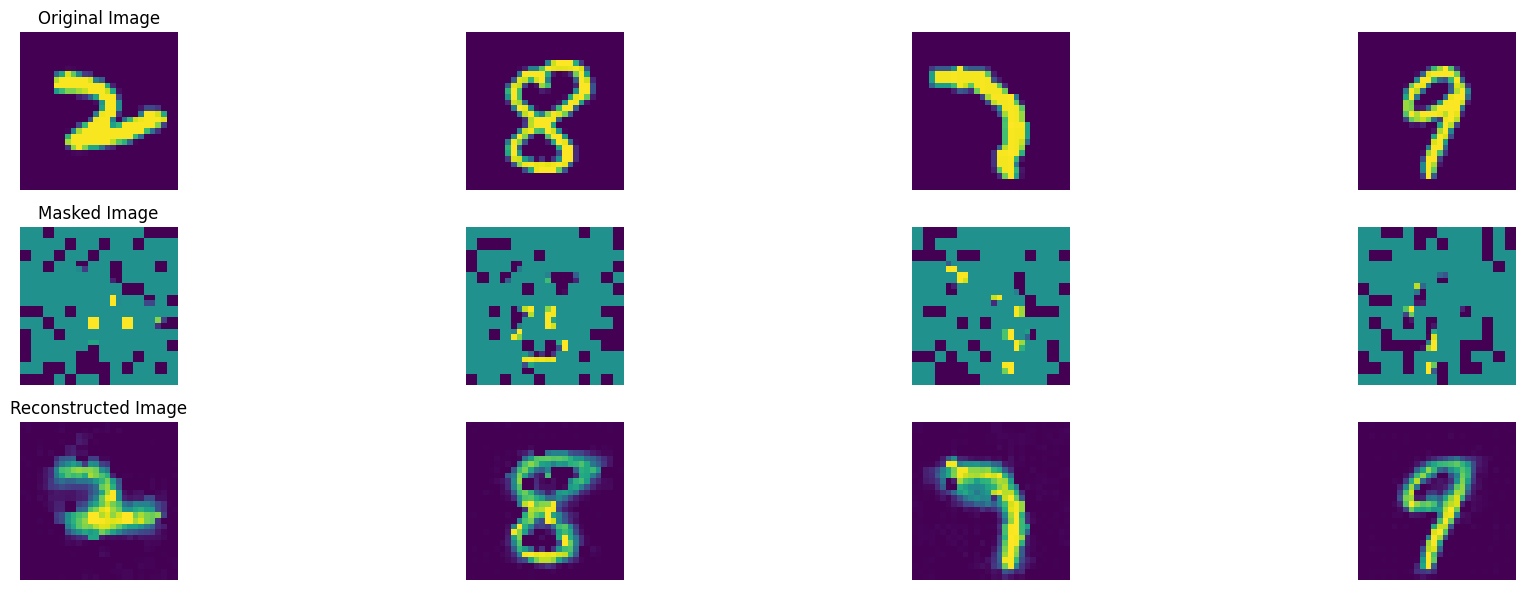

100%|██████████| 188/188 [00:39<00:00,  4.77it/s]


In epoch 68, average traning loss is 0.09990404871232966.
=================== EPOCH:  69  ===================


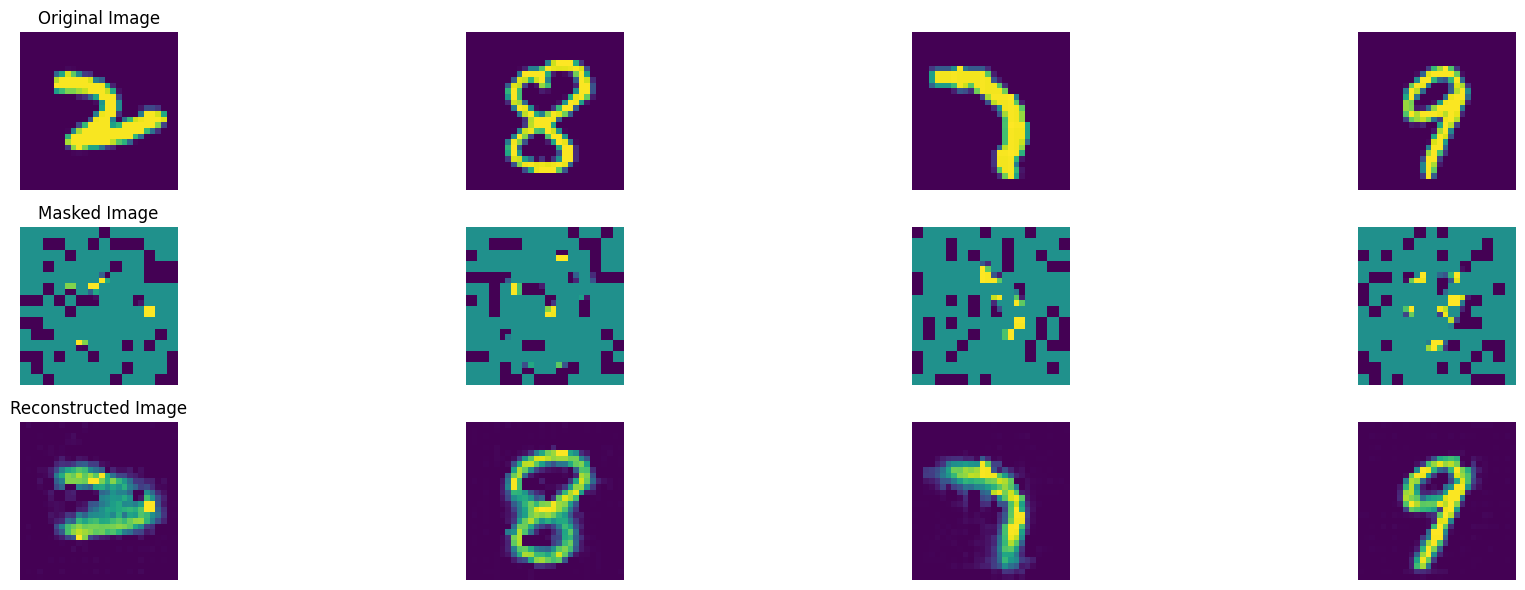

100%|██████████| 188/188 [00:40<00:00,  4.65it/s]


In epoch 69, average traning loss is 0.09808859645210682.
=================== EPOCH:  70  ===================


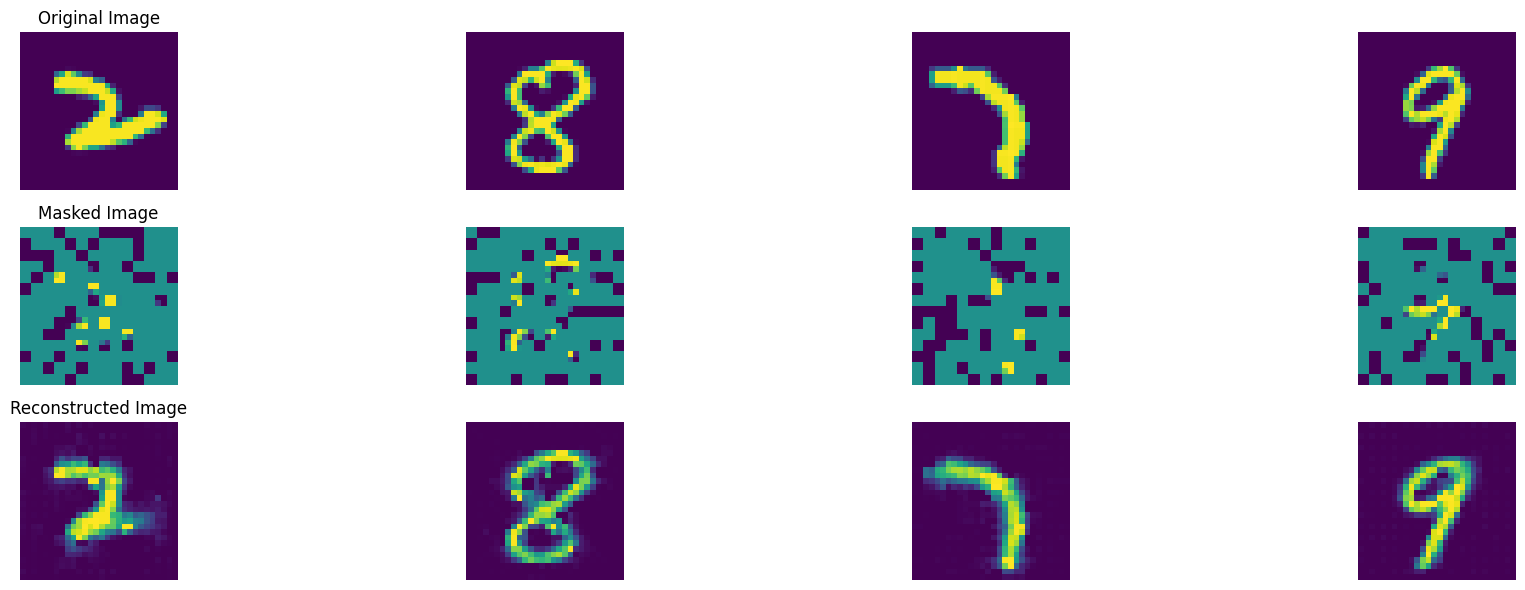

100%|██████████| 188/188 [00:40<00:00,  4.63it/s]


In epoch 70, average traning loss is 0.09652534416539872.
=================== EPOCH:  71  ===================


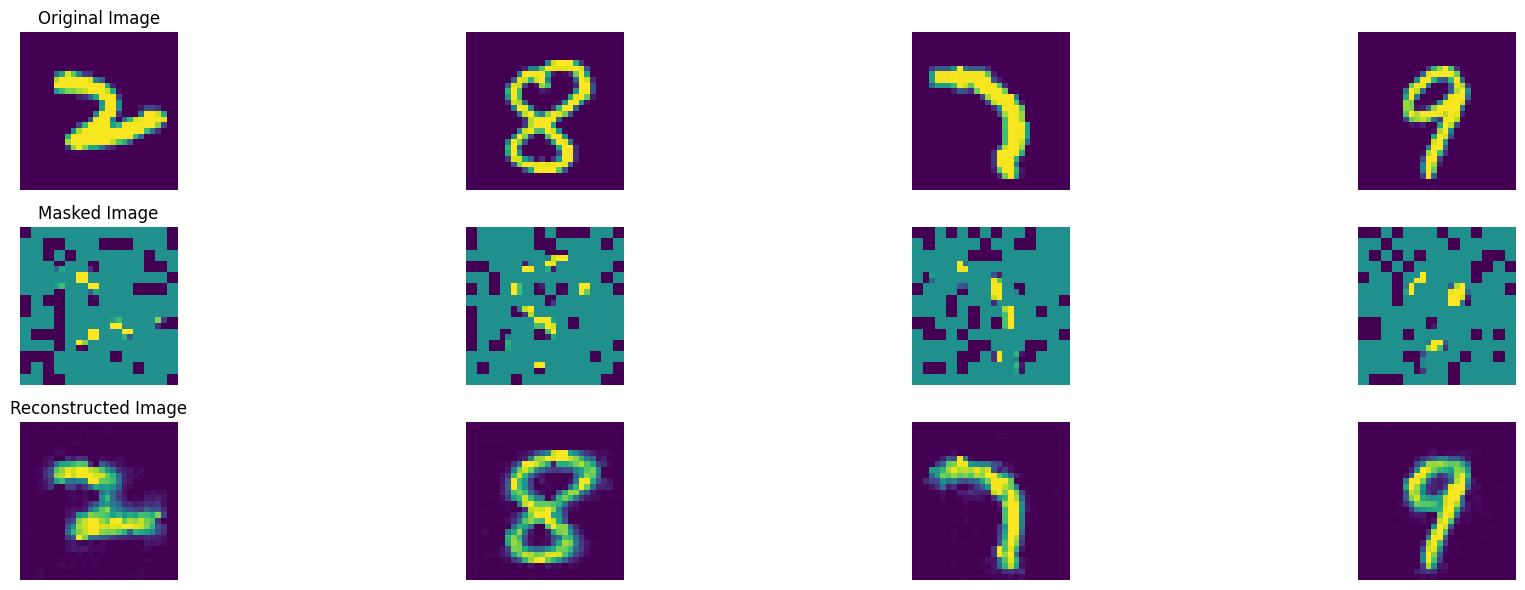

100%|██████████| 188/188 [00:39<00:00,  4.73it/s]


In epoch 71, average traning loss is 0.09497669073653982.
=================== EPOCH:  72  ===================


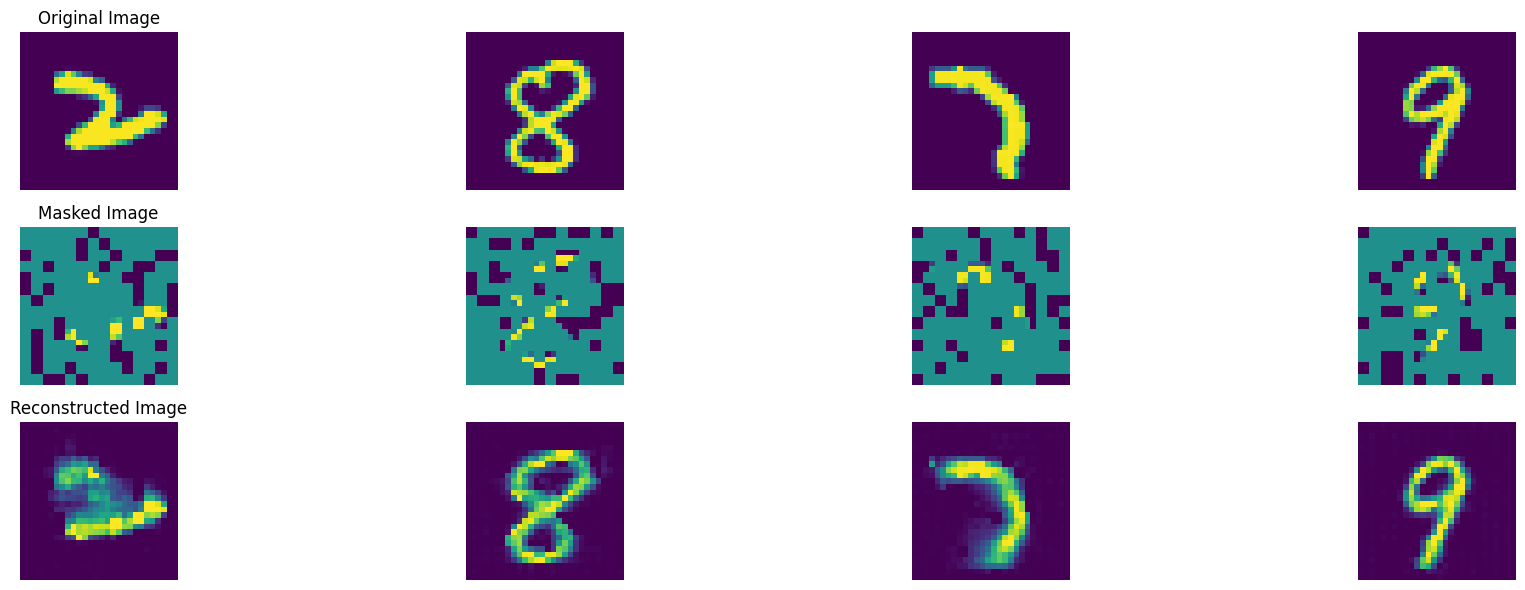

100%|██████████| 188/188 [00:40<00:00,  4.64it/s]


In epoch 72, average traning loss is 0.09343951865238079.
=================== EPOCH:  73  ===================


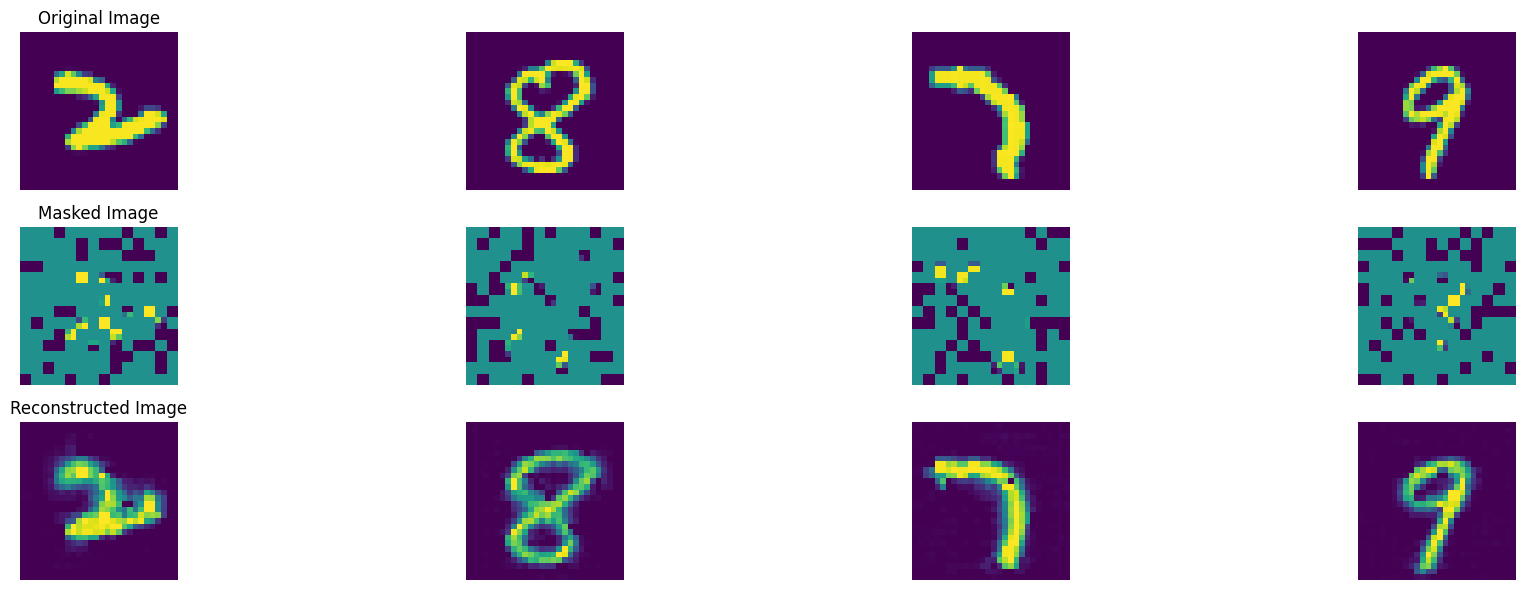

100%|██████████| 188/188 [00:39<00:00,  4.79it/s]


In epoch 73, average traning loss is 0.09245590730867487.
=================== EPOCH:  74  ===================


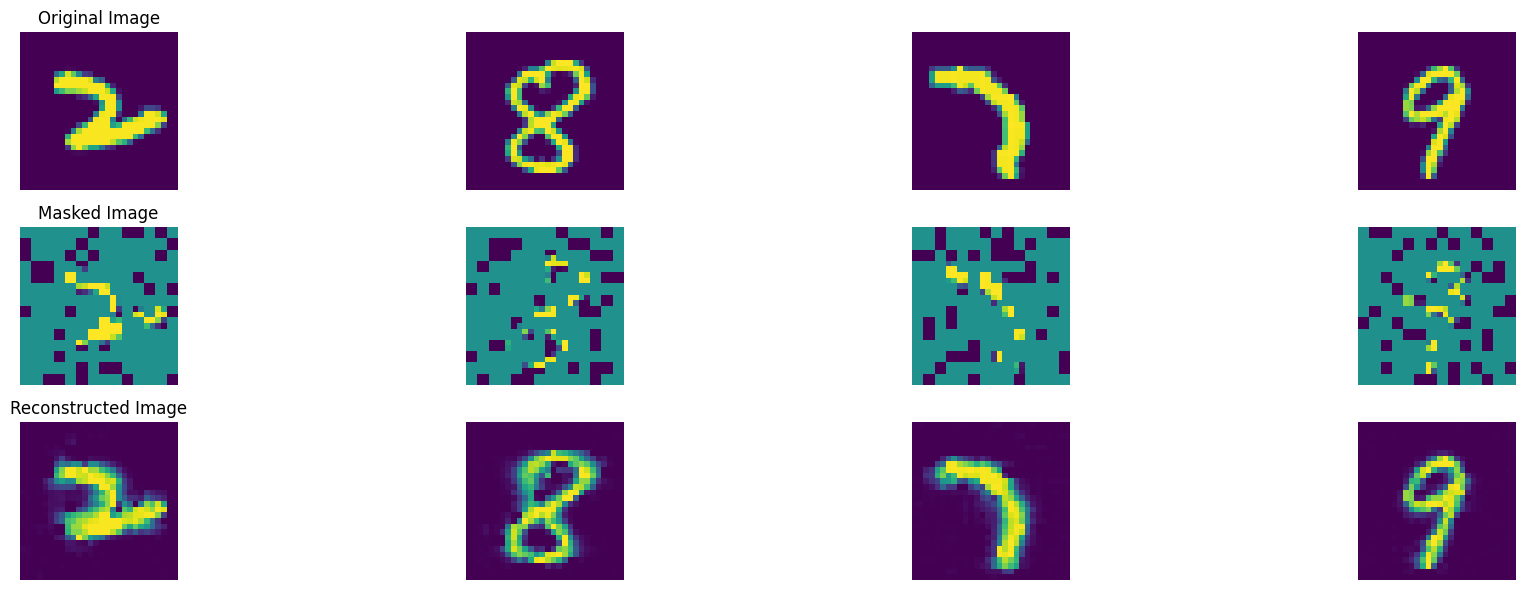

100%|██████████| 188/188 [00:40<00:00,  4.63it/s]


In epoch 74, average traning loss is 0.09140439771432826.
=================== EPOCH:  75  ===================


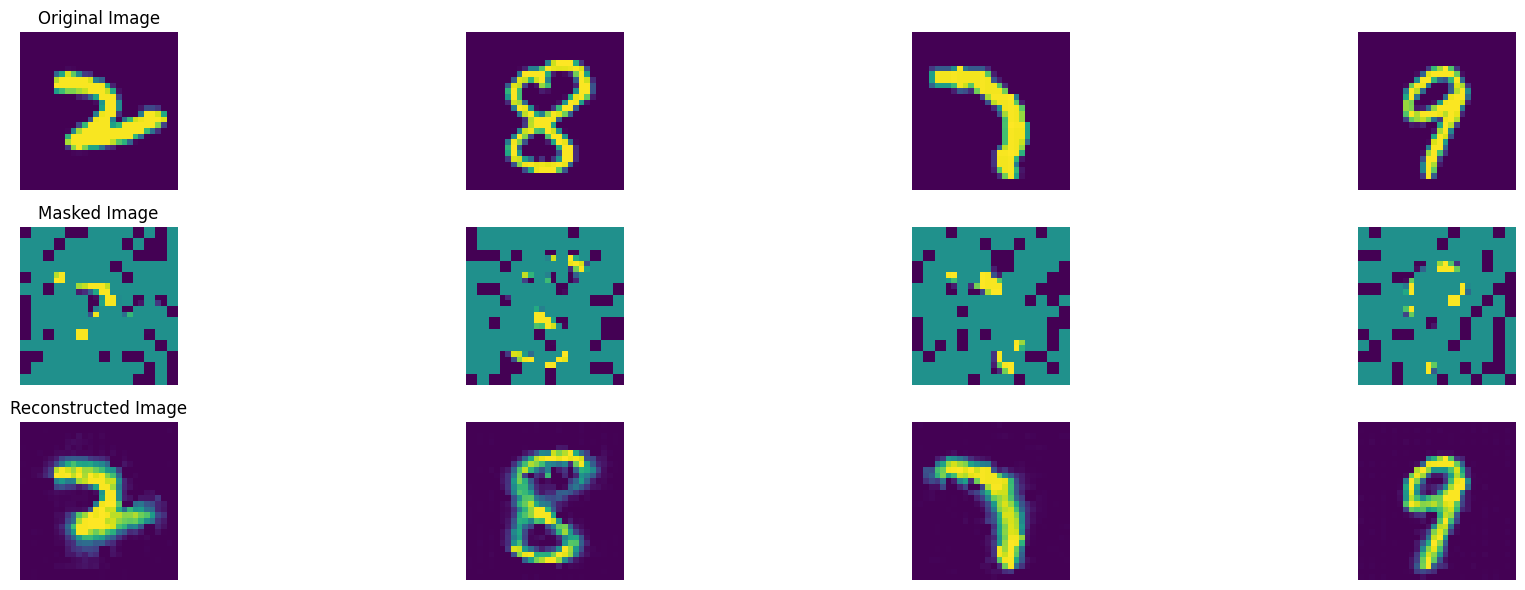

100%|██████████| 188/188 [00:41<00:00,  4.52it/s]


In epoch 75, average traning loss is 0.08981681500185043.
=================== EPOCH:  76  ===================


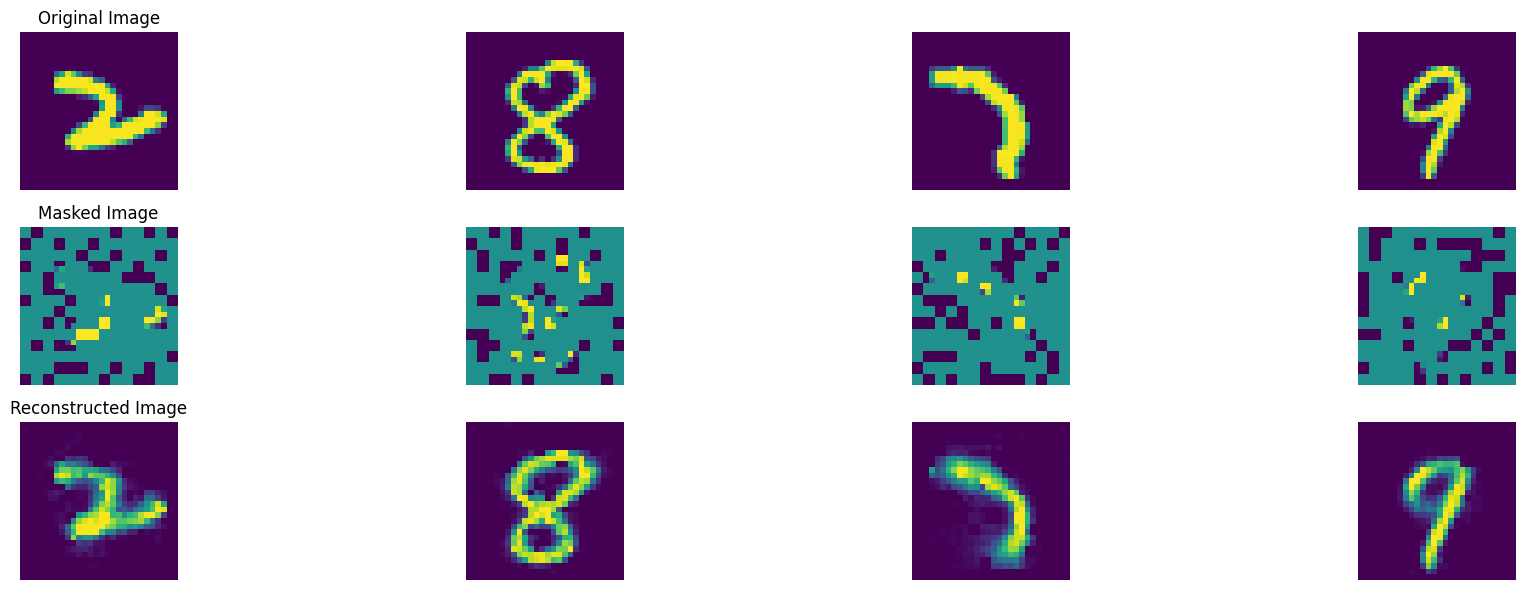

100%|██████████| 188/188 [00:41<00:00,  4.52it/s]


In epoch 76, average traning loss is 0.08900545695994763.
=================== EPOCH:  77  ===================


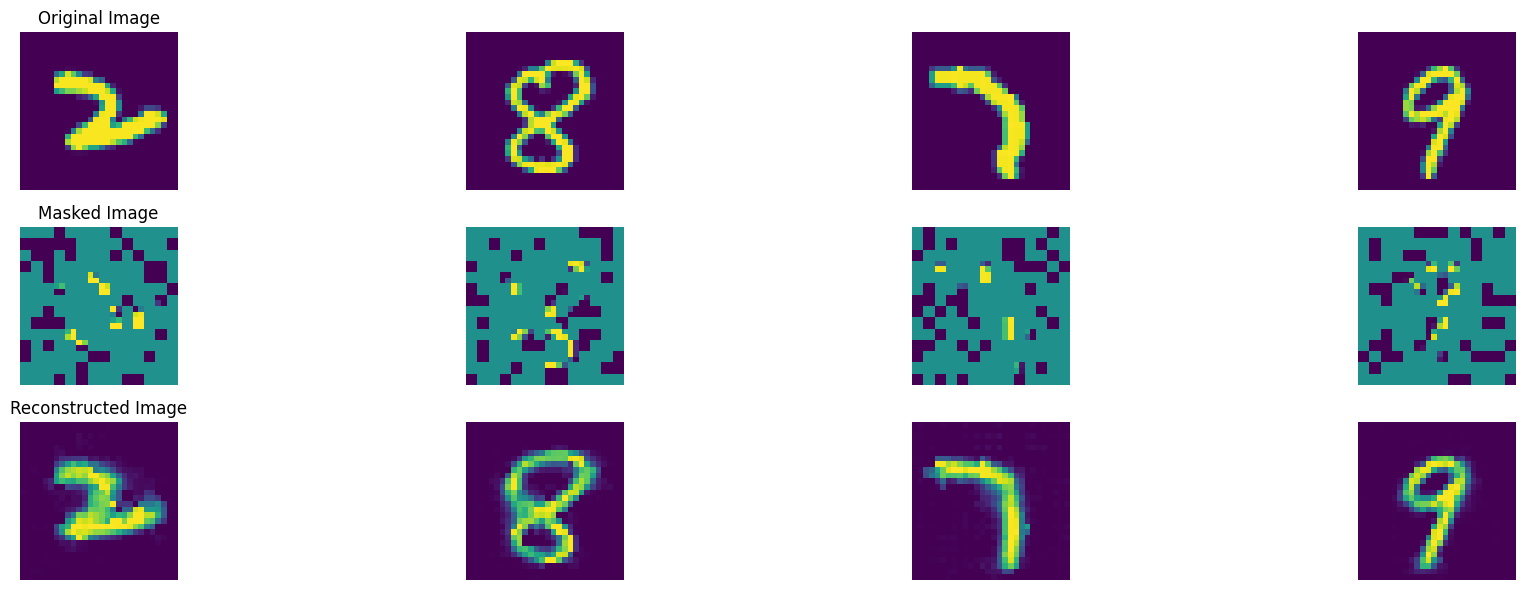

100%|██████████| 188/188 [00:42<00:00,  4.46it/s]


In epoch 77, average traning loss is 0.08827960479291196.
=================== EPOCH:  78  ===================


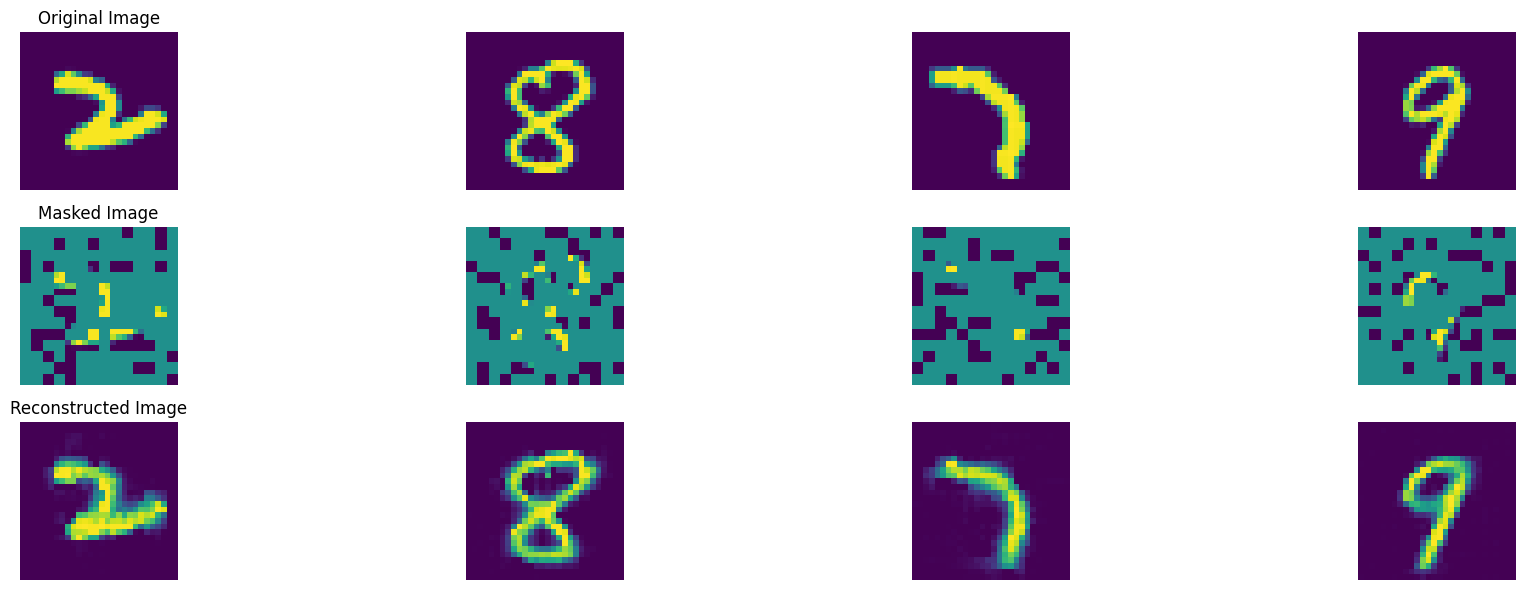

100%|██████████| 188/188 [00:41<00:00,  4.55it/s]


In epoch 78, average traning loss is 0.08709442512469089.
=================== EPOCH:  79  ===================


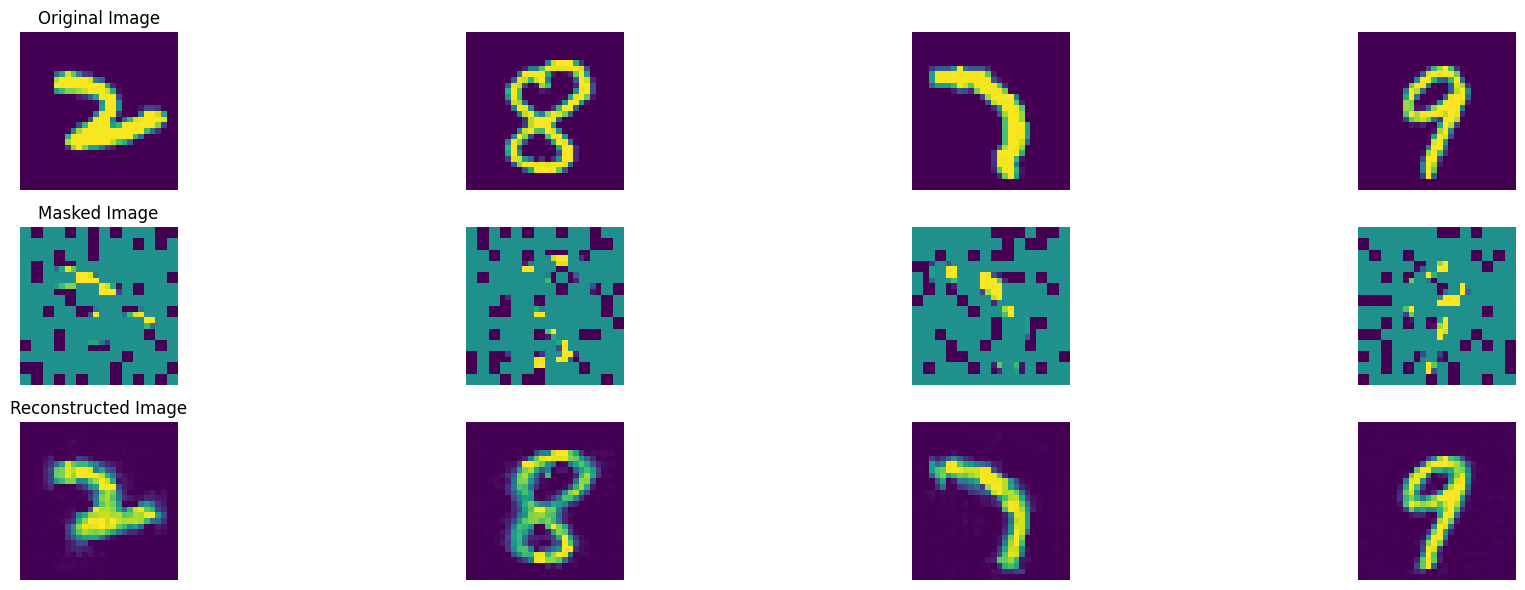

100%|██████████| 188/188 [00:41<00:00,  4.54it/s]


In epoch 79, average traning loss is 0.08638754705006772.
=================== EPOCH:  80  ===================


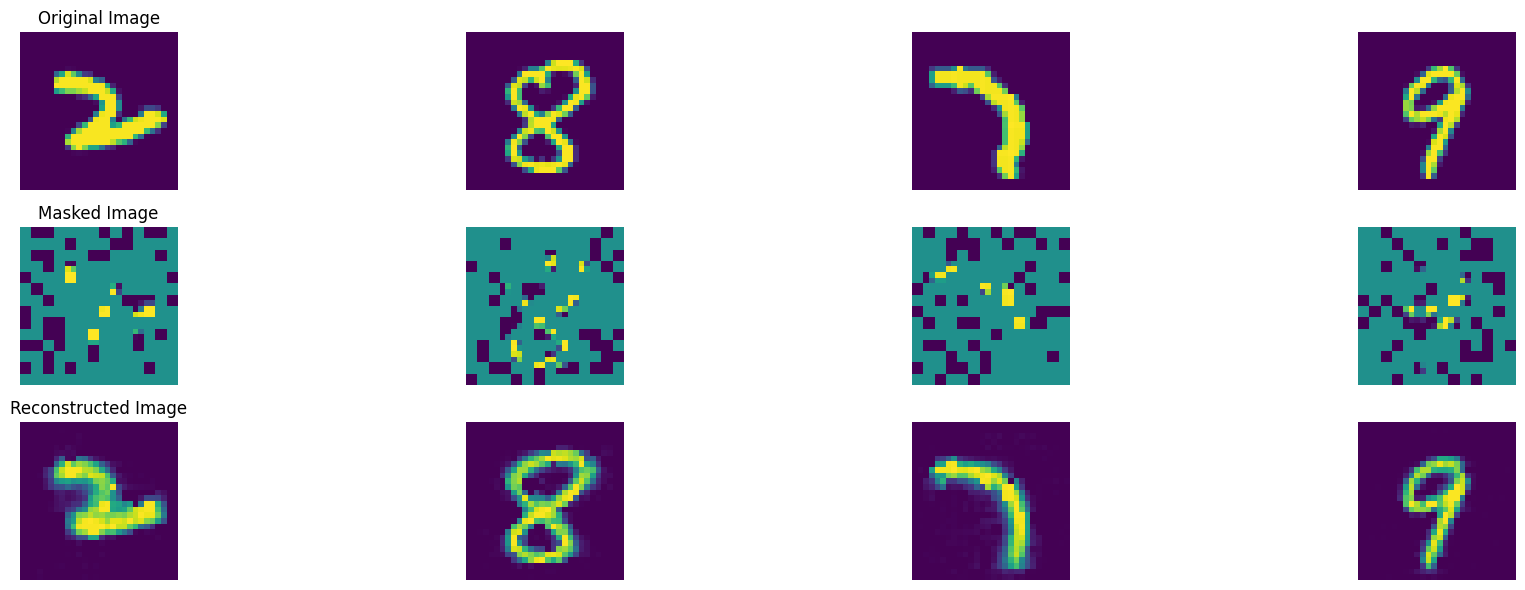

100%|██████████| 188/188 [00:41<00:00,  4.55it/s]


In epoch 80, average traning loss is 0.08599907072617653.
=================== EPOCH:  81  ===================


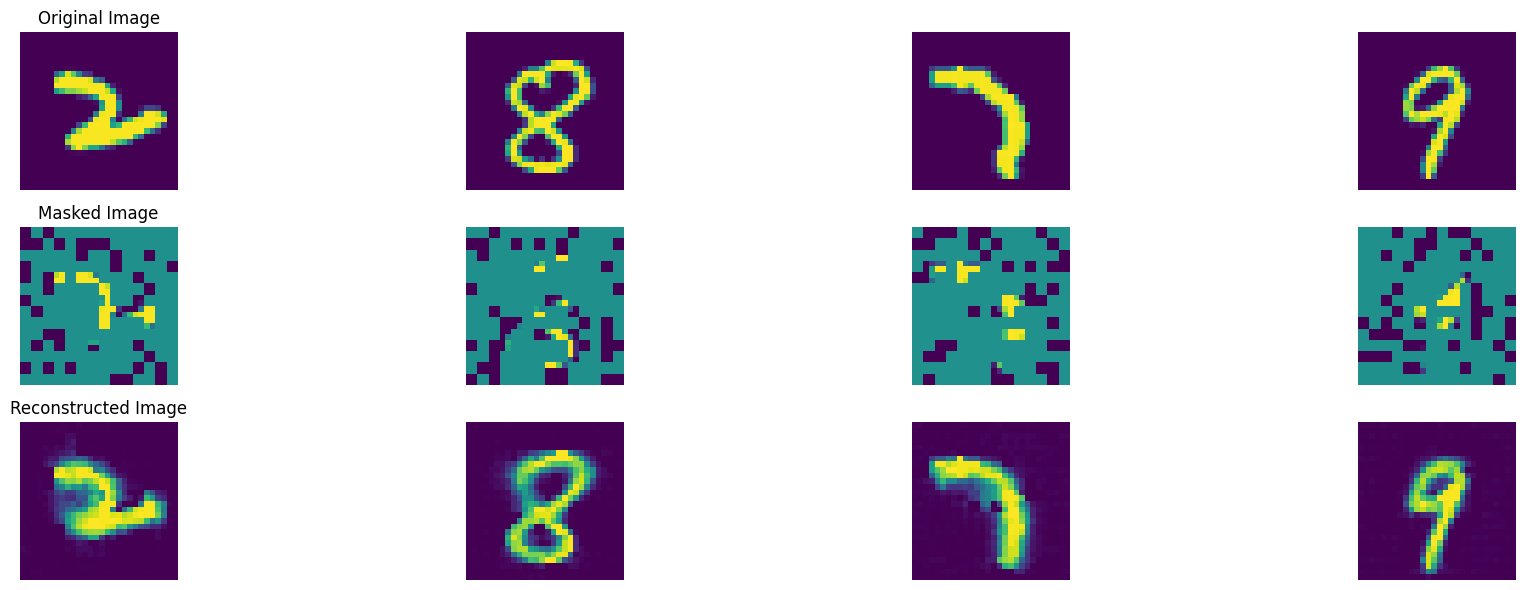

100%|██████████| 188/188 [00:41<00:00,  4.55it/s]


In epoch 81, average traning loss is 0.0851626121934424.
=================== EPOCH:  82  ===================


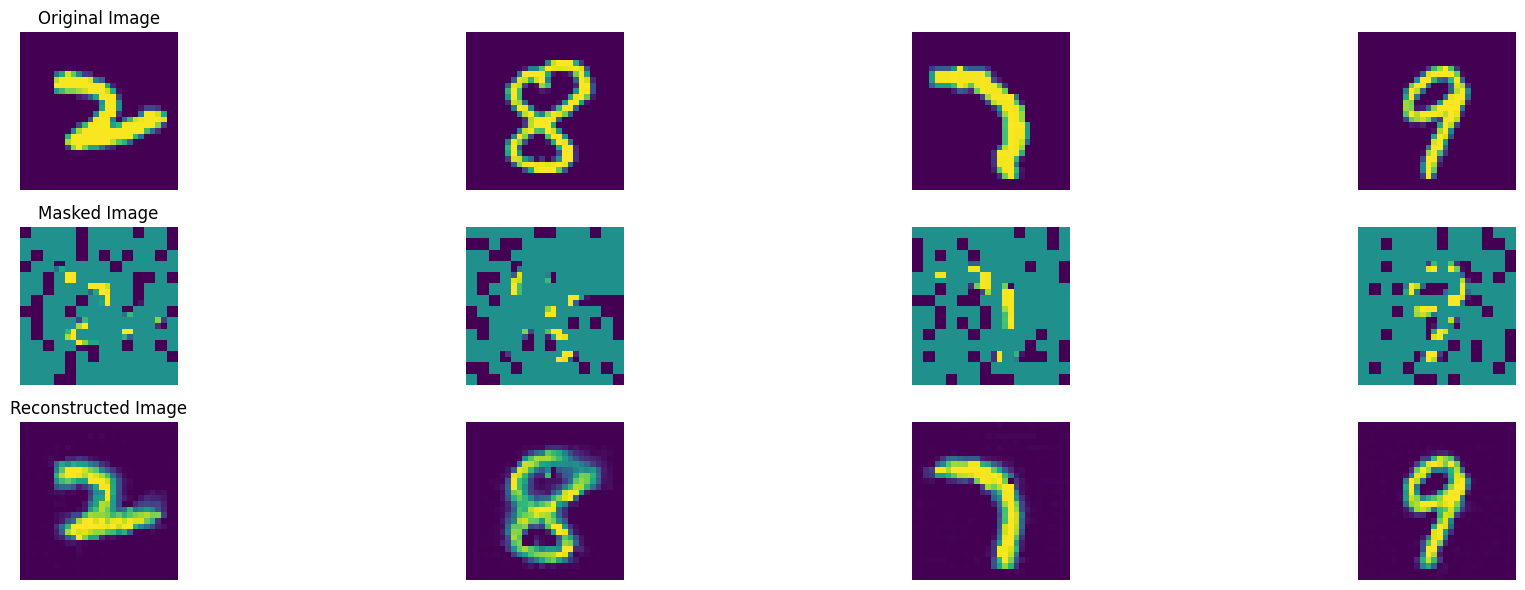

100%|██████████| 188/188 [00:41<00:00,  4.56it/s]


In epoch 82, average traning loss is 0.08463000101929015.
=================== EPOCH:  83  ===================


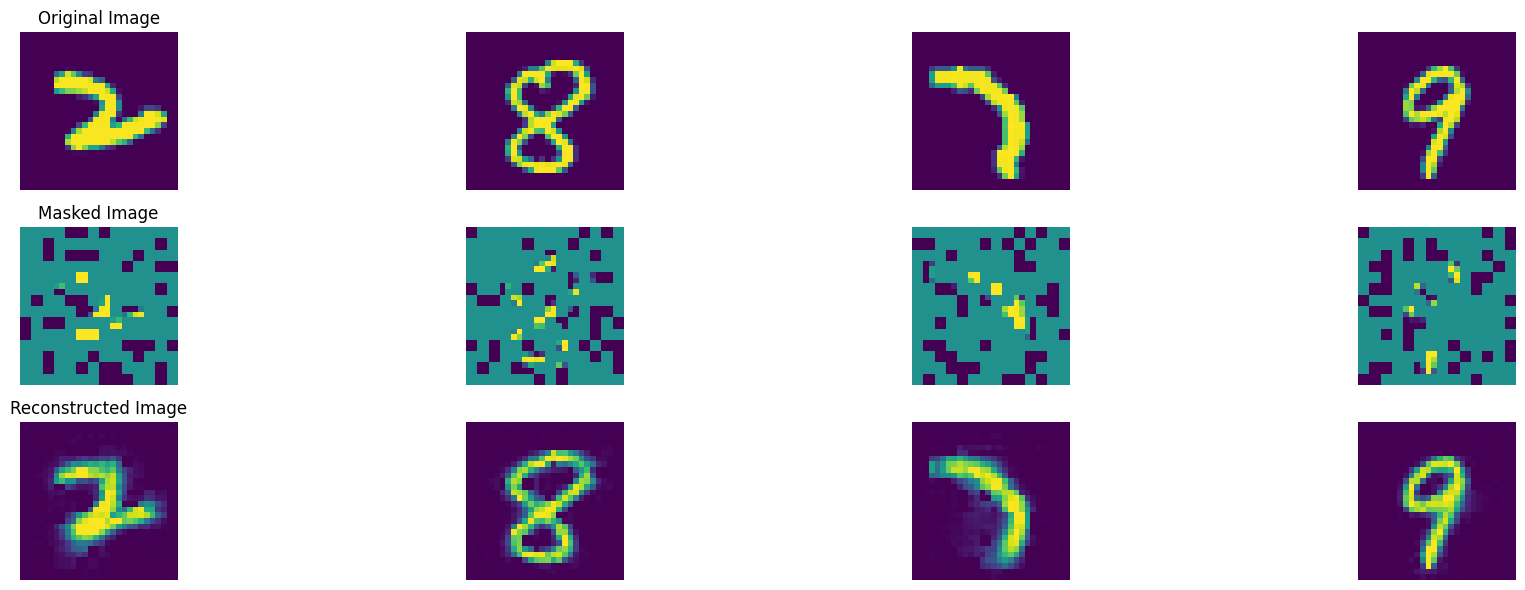

100%|██████████| 188/188 [00:41<00:00,  4.55it/s]


In epoch 83, average traning loss is 0.08389906969634776.
=================== EPOCH:  84  ===================


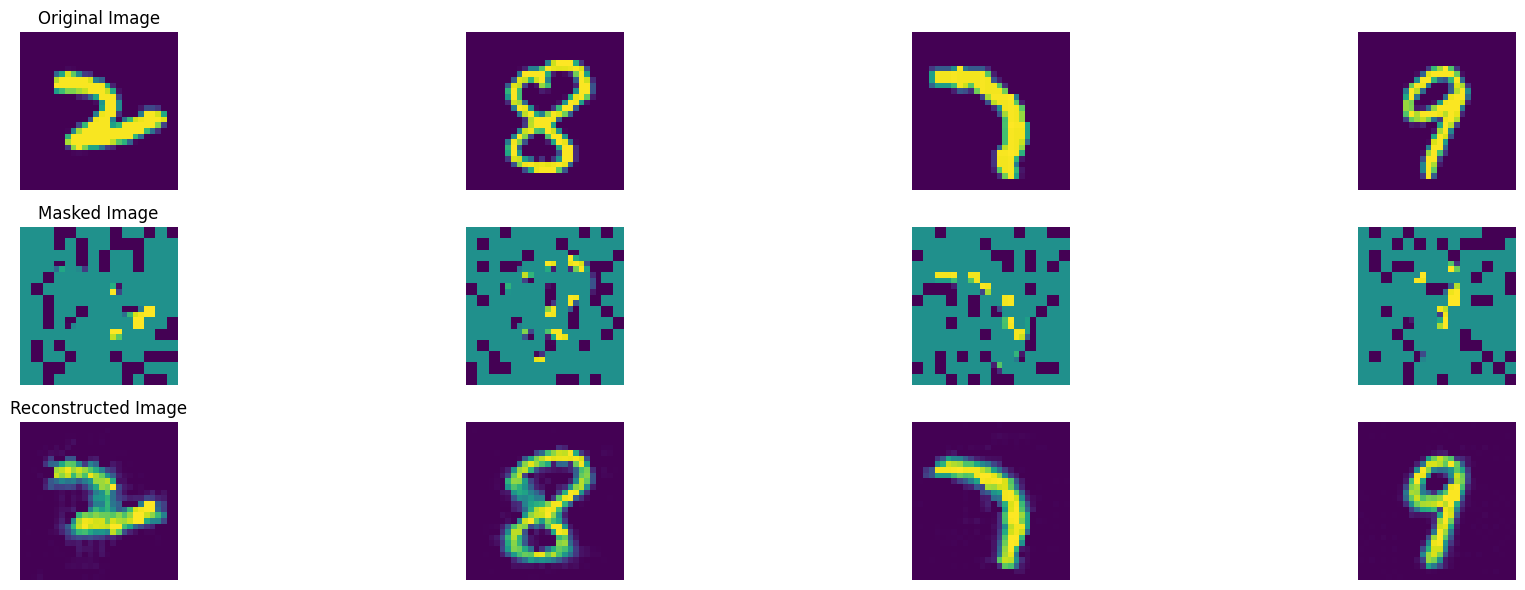

100%|██████████| 188/188 [00:41<00:00,  4.57it/s]


In epoch 84, average traning loss is 0.08325275909551914.
=================== EPOCH:  85  ===================


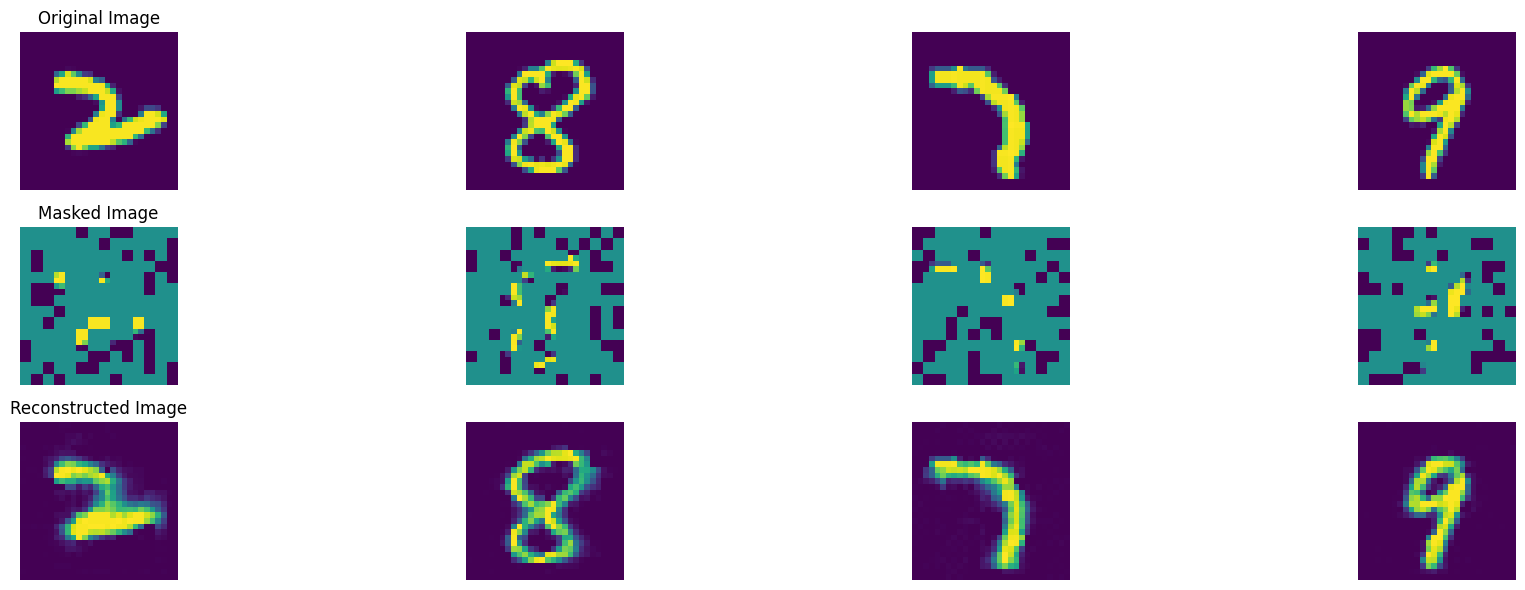

100%|██████████| 188/188 [00:40<00:00,  4.66it/s]


In epoch 85, average traning loss is 0.08268557437398333.
=================== EPOCH:  86  ===================


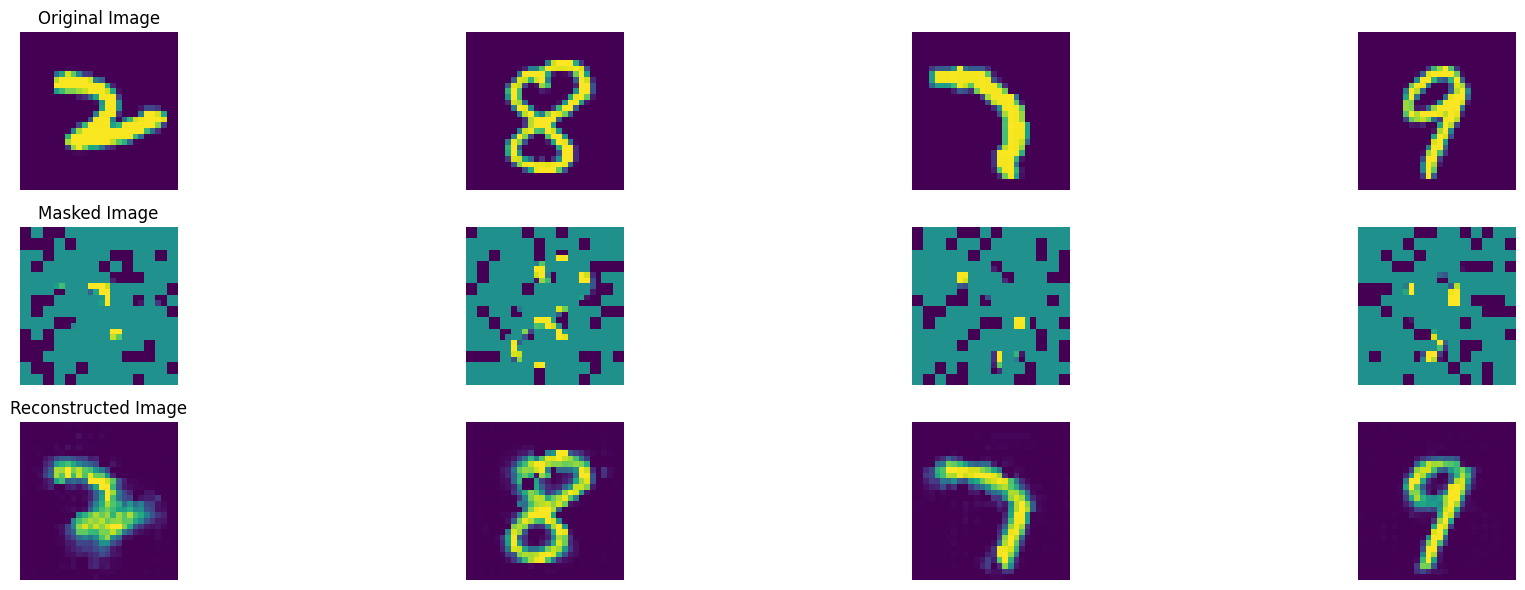

100%|██████████| 188/188 [00:40<00:00,  4.70it/s]


In epoch 86, average traning loss is 0.08221139310997852.
=================== EPOCH:  87  ===================


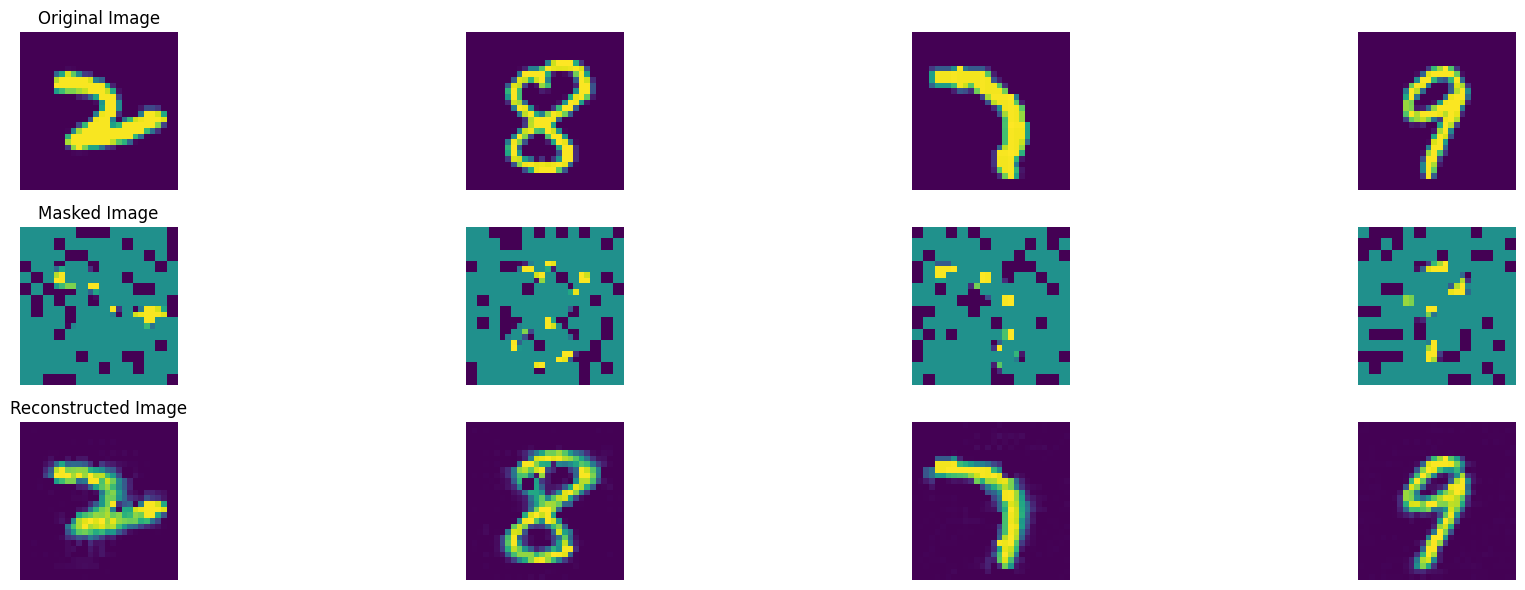

100%|██████████| 188/188 [00:40<00:00,  4.63it/s]


In epoch 87, average traning loss is 0.08187818368698688.
=================== EPOCH:  88  ===================


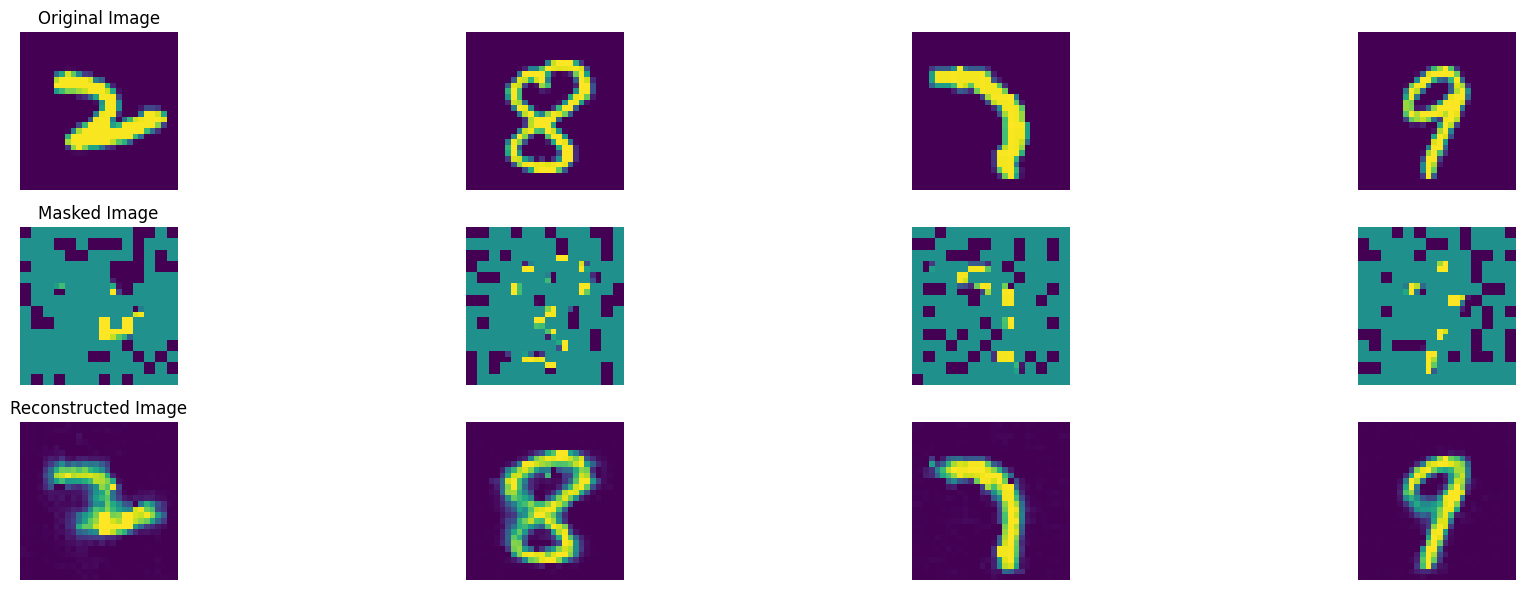

100%|██████████| 188/188 [00:40<00:00,  4.61it/s]


In epoch 88, average traning loss is 0.08165022885387248.
=================== EPOCH:  89  ===================


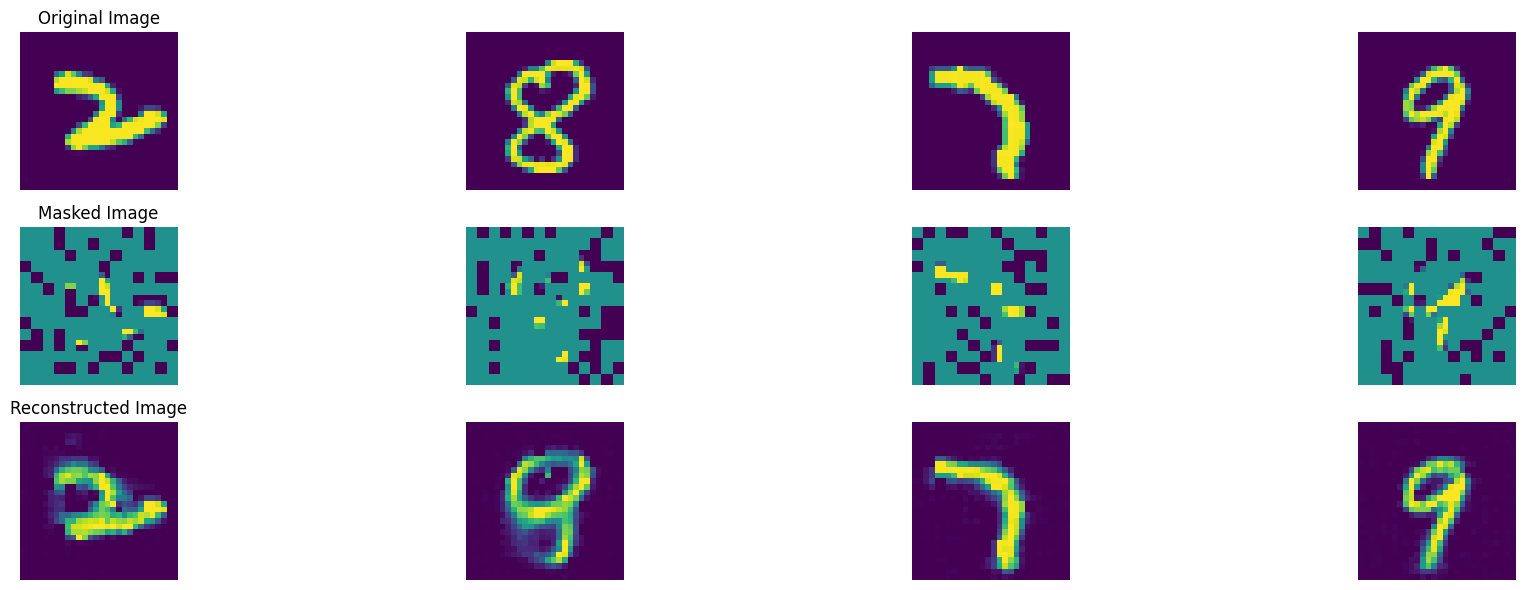

100%|██████████| 188/188 [00:41<00:00,  4.57it/s]


In epoch 89, average traning loss is 0.08141802647646437.
=================== EPOCH:  90  ===================


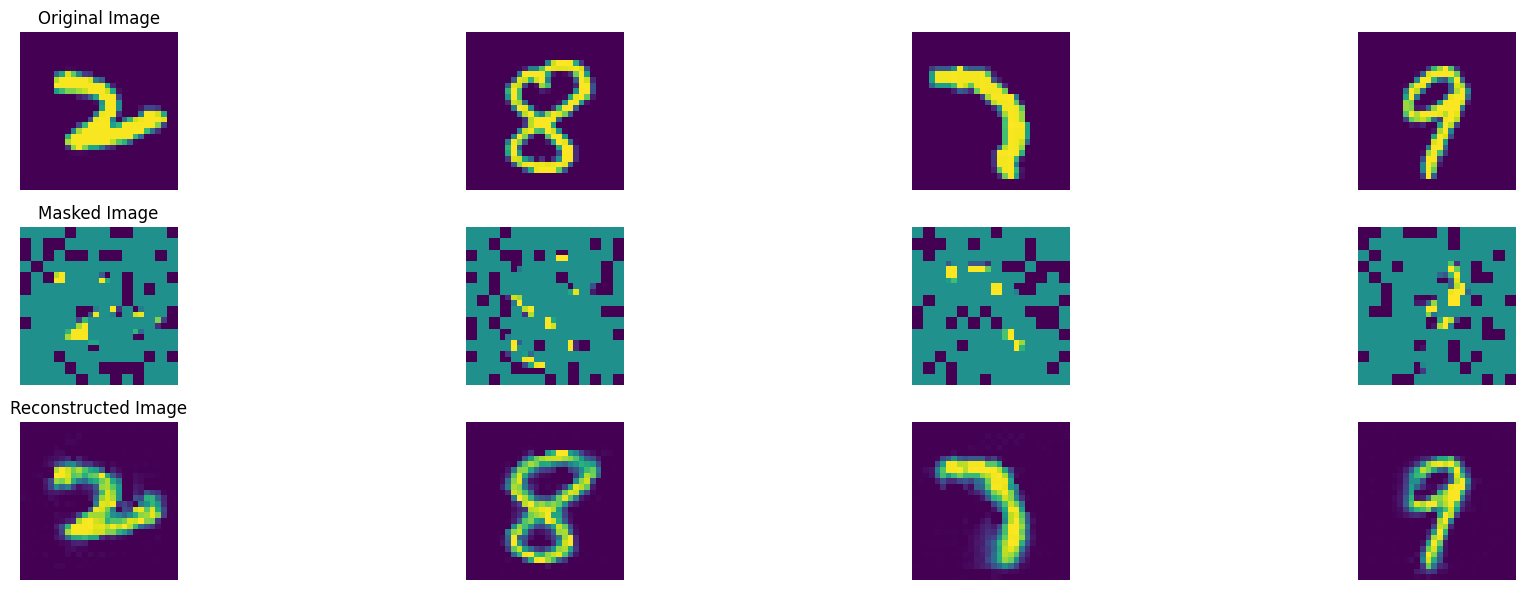

100%|██████████| 188/188 [00:41<00:00,  4.55it/s]


In epoch 90, average traning loss is 0.0810283308333539.
=================== EPOCH:  91  ===================


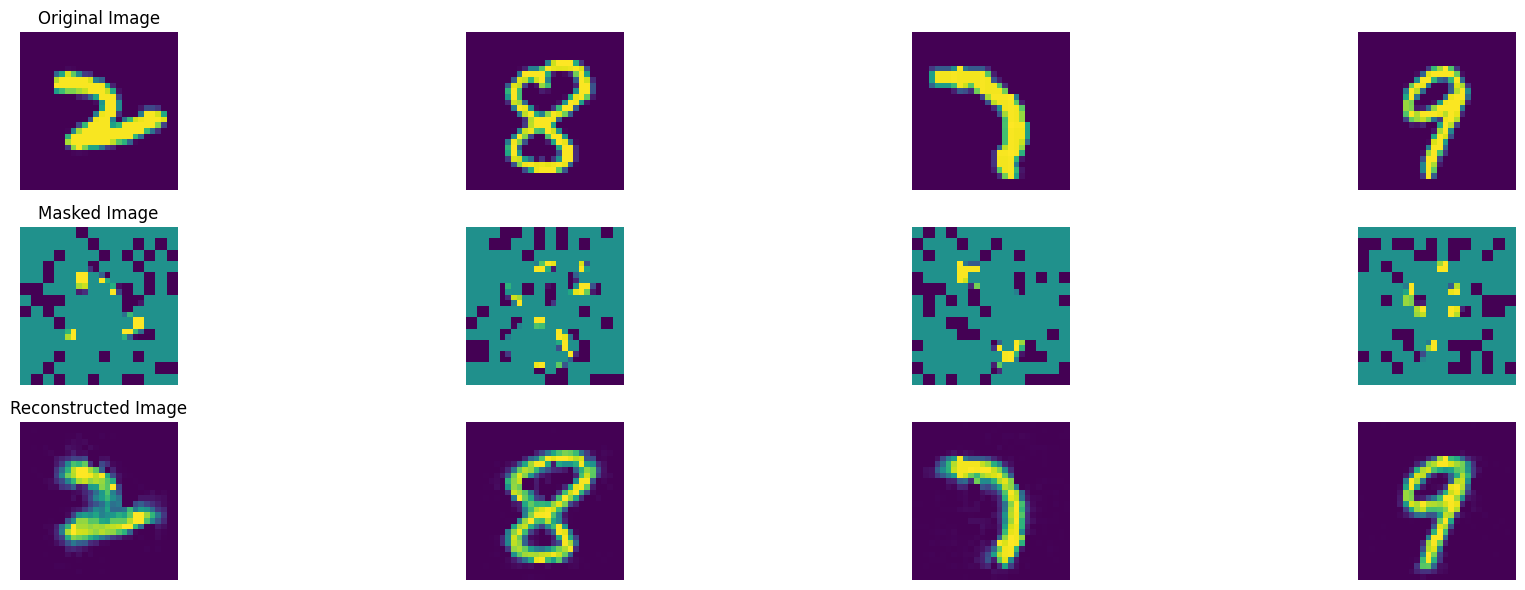

100%|██████████| 188/188 [00:41<00:00,  4.48it/s]


In epoch 91, average traning loss is 0.0808156559124906.
=================== EPOCH:  92  ===================


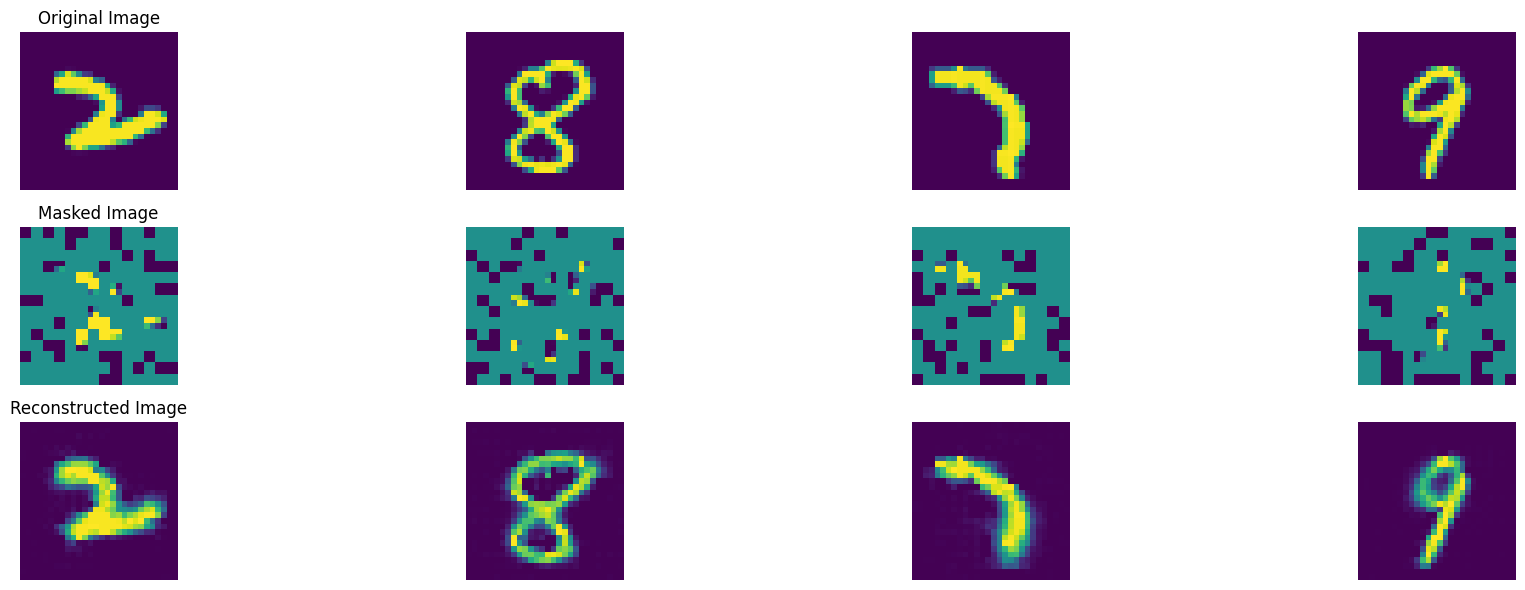

100%|██████████| 188/188 [00:41<00:00,  4.48it/s]


In epoch 92, average traning loss is 0.08041185132683591.
=================== EPOCH:  93  ===================


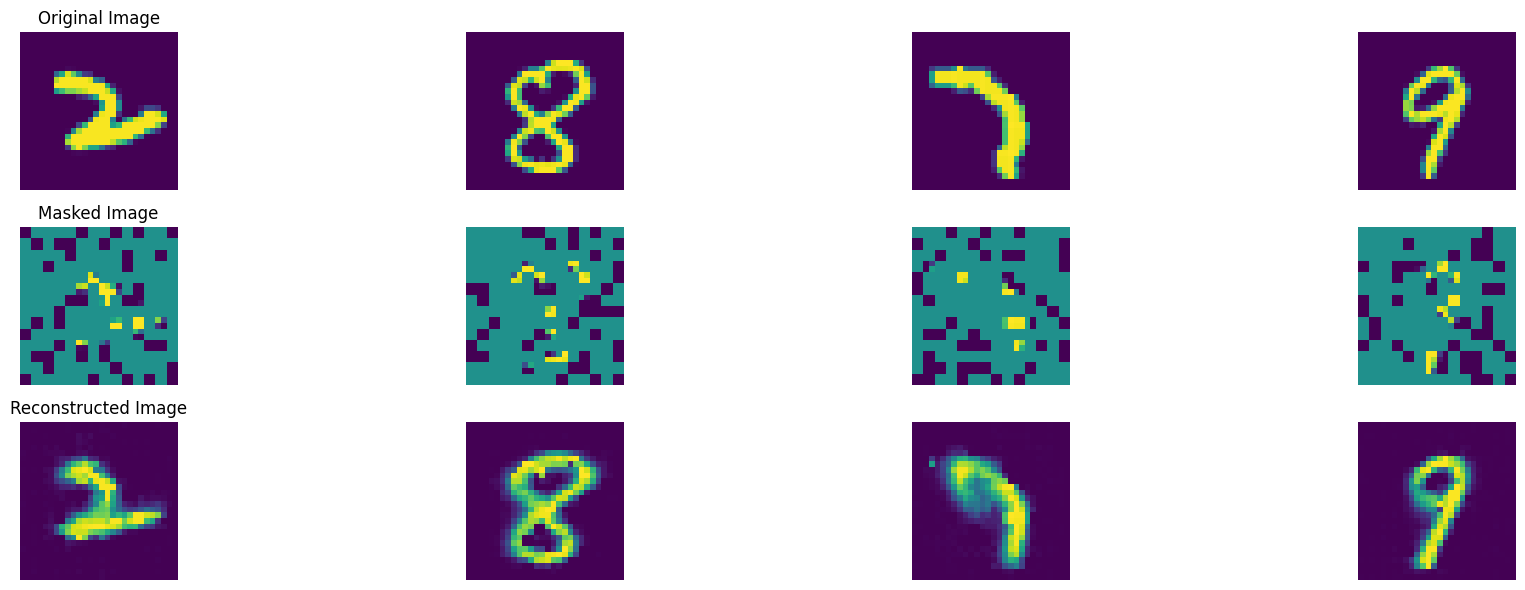

100%|██████████| 188/188 [00:41<00:00,  4.50it/s]


In epoch 93, average traning loss is 0.08026768378120788.
=================== EPOCH:  94  ===================


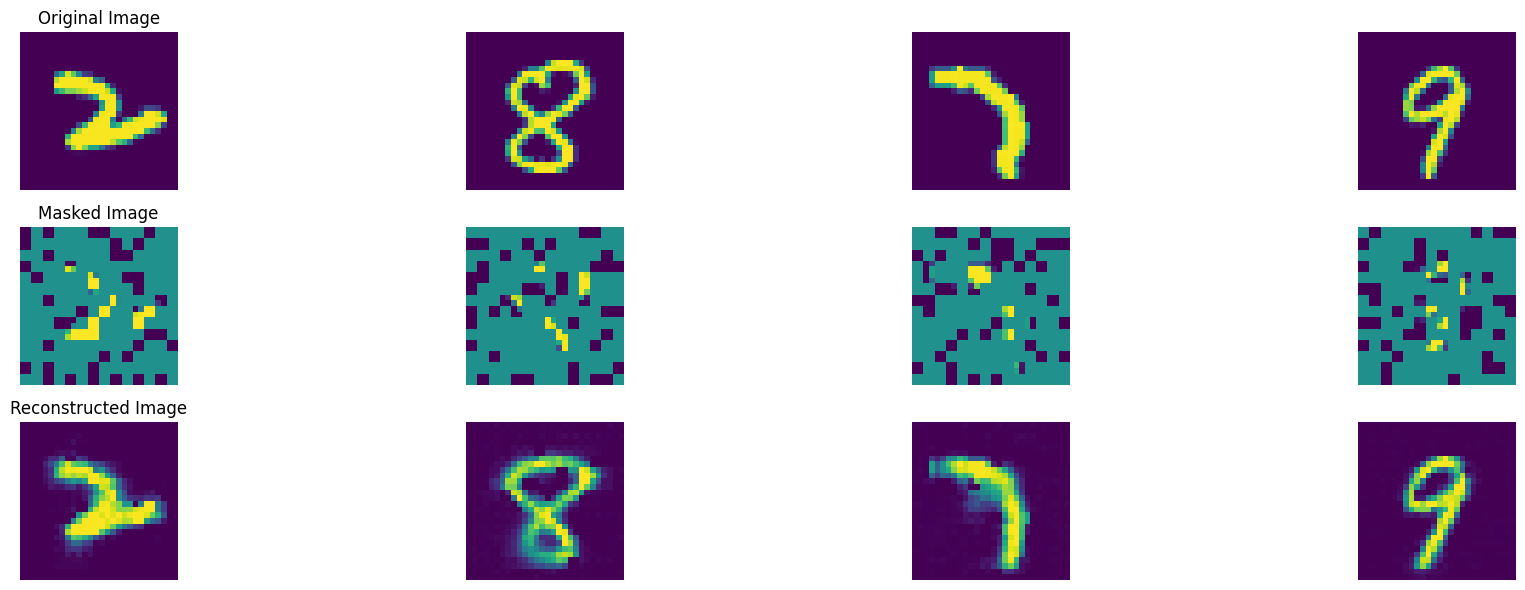

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 94, average traning loss is 0.08011594715904682.
=================== EPOCH:  95  ===================


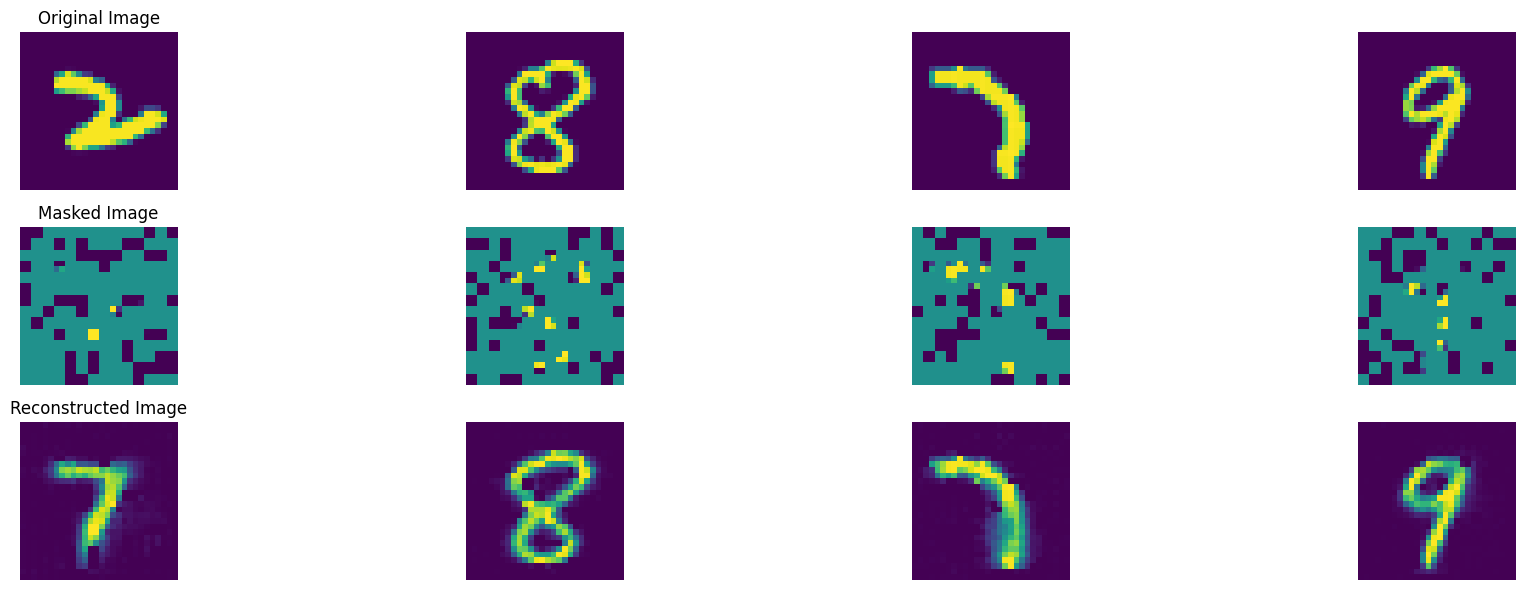

100%|██████████| 188/188 [00:41<00:00,  4.49it/s]


In epoch 95, average traning loss is 0.07978890313112989.
=================== EPOCH:  96  ===================


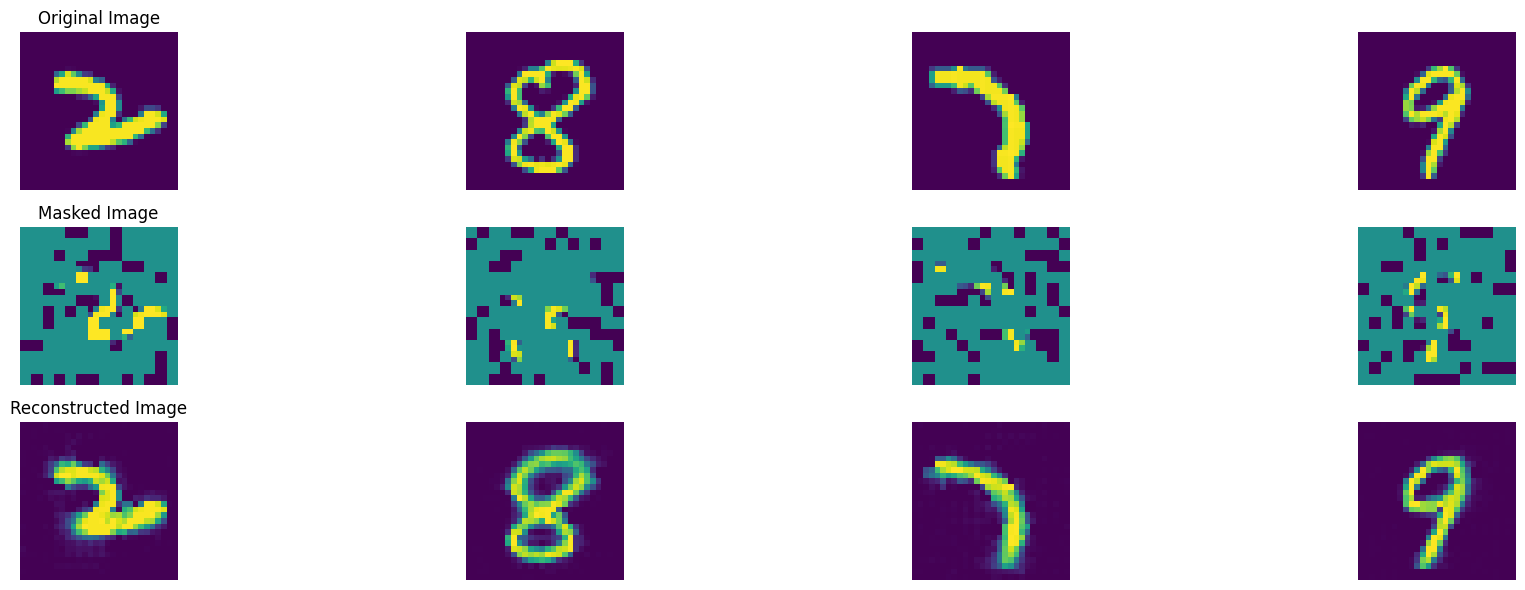

100%|██████████| 188/188 [00:41<00:00,  4.58it/s]


In epoch 96, average traning loss is 0.07974281106540497.
=================== EPOCH:  97  ===================


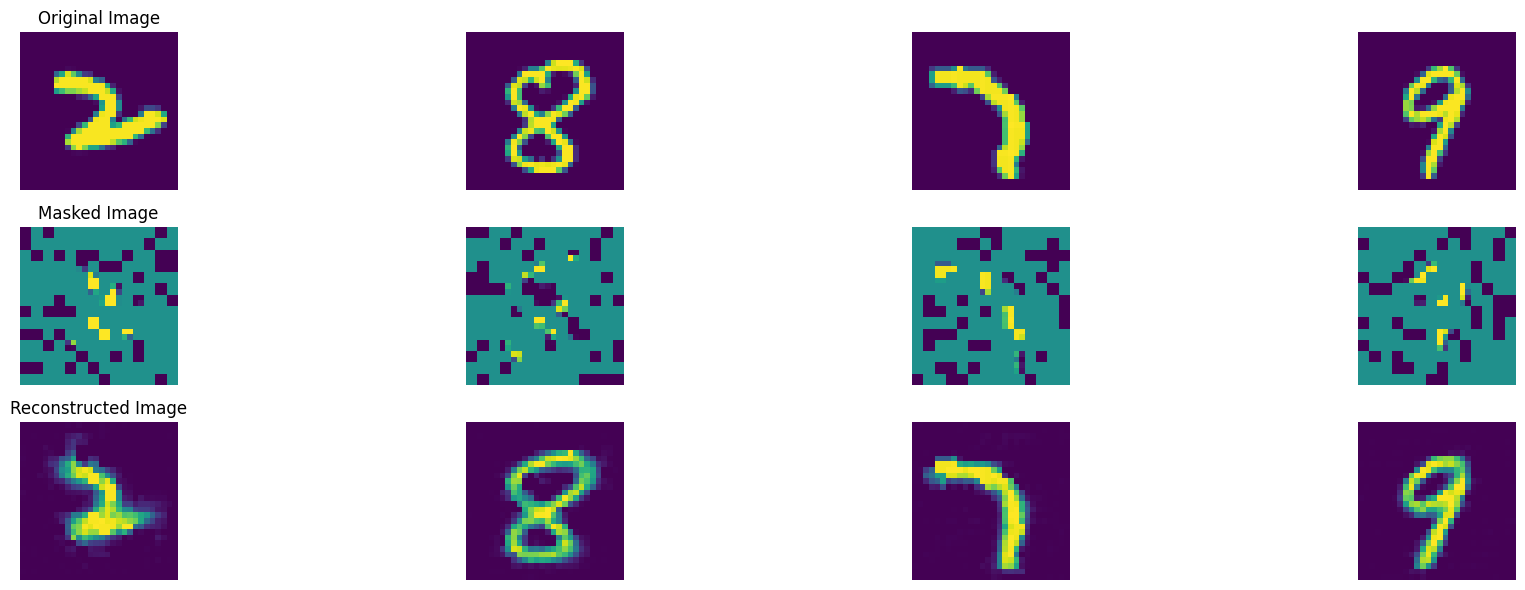

100%|██████████| 188/188 [00:40<00:00,  4.64it/s]


In epoch 97, average traning loss is 0.07959964185794617.
=================== EPOCH:  98  ===================


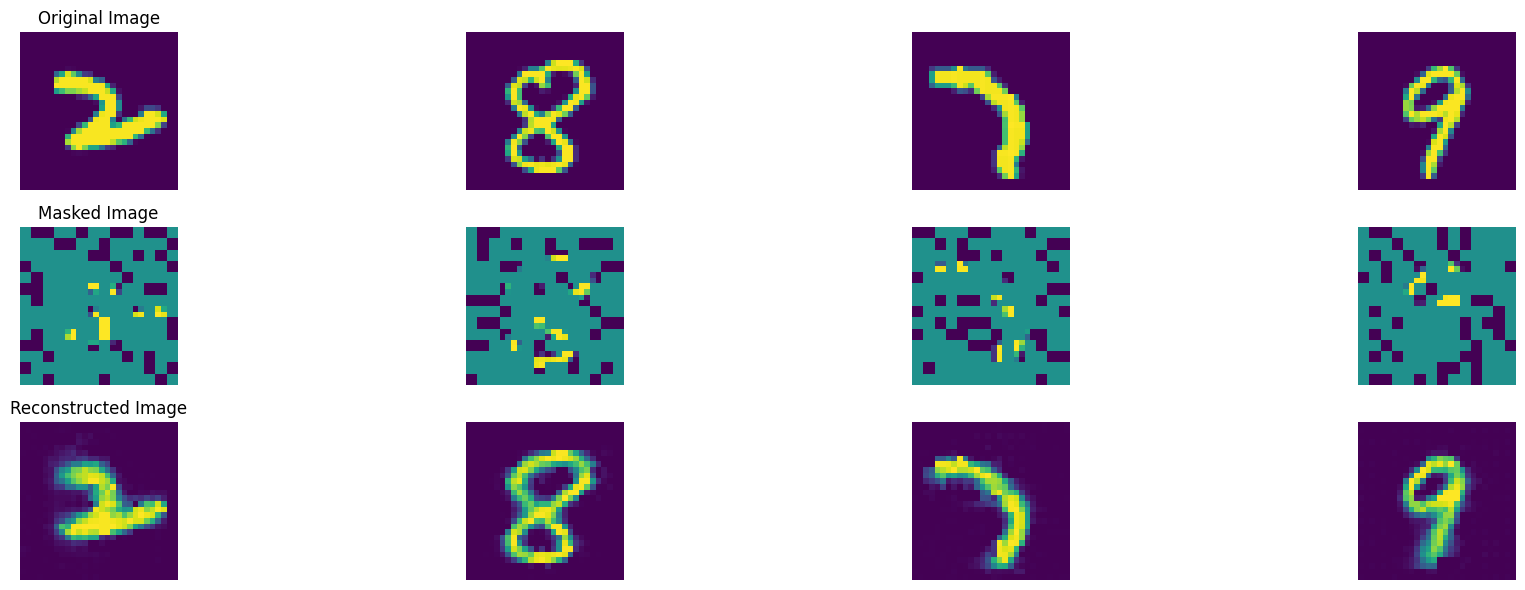

100%|██████████| 188/188 [00:40<00:00,  4.64it/s]


In epoch 98, average traning loss is 0.07971132011648188.
=================== EPOCH:  99  ===================


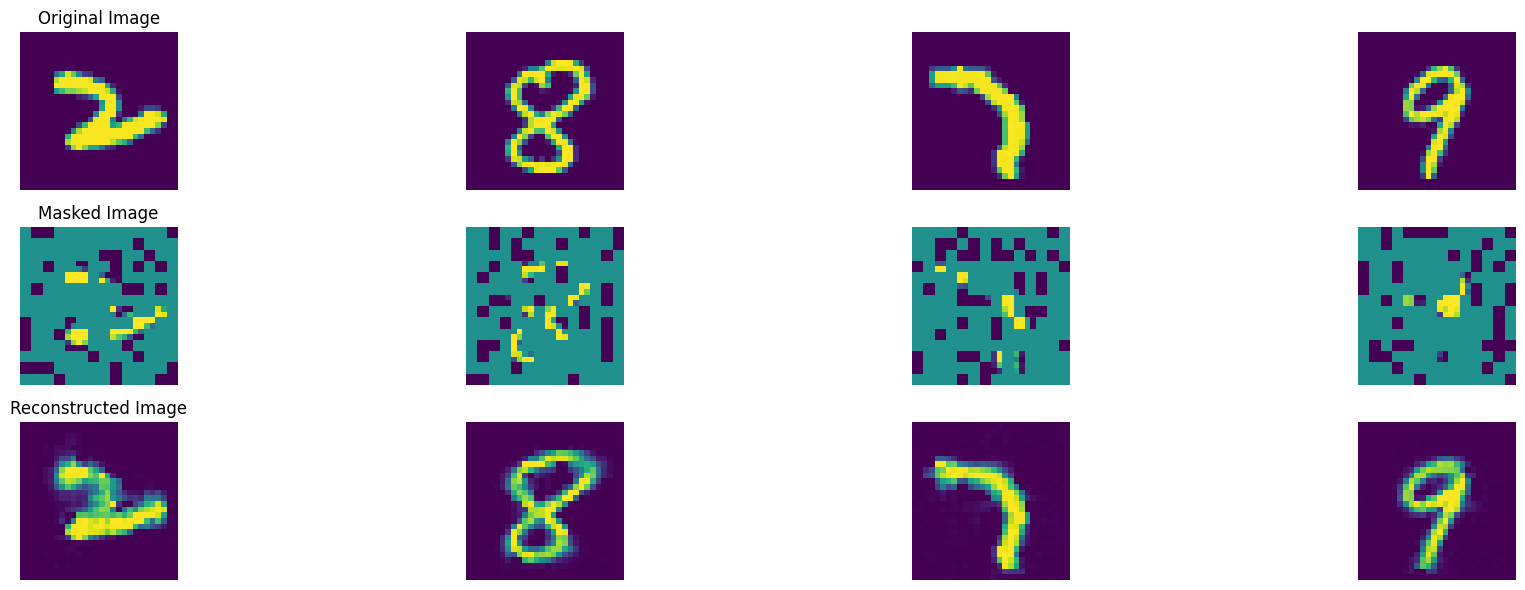

100%|██████████| 188/188 [00:39<00:00,  4.76it/s]


In epoch 99, average traning loss is 0.07964455970424286.
=================== EPOCH:  100  ===================


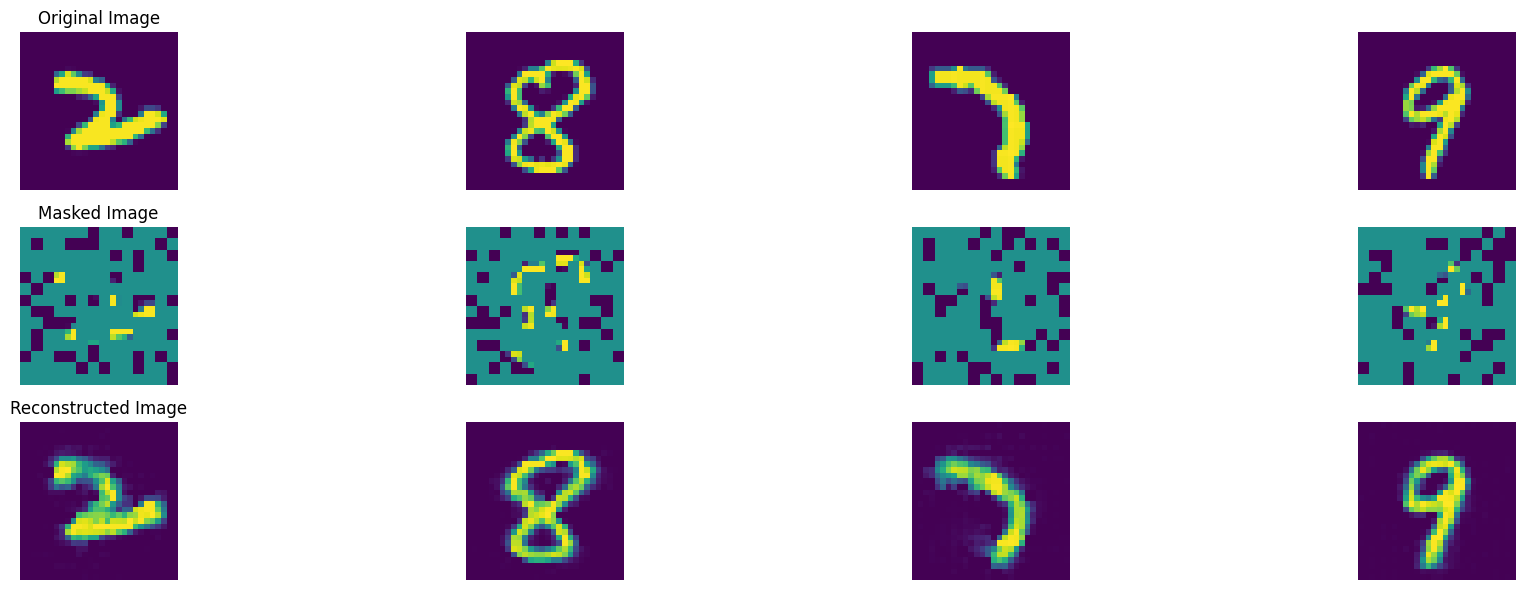

In [25]:
# GPU 6660MiB
import matplotlib.pyplot as plt
step_count = 0
optim.zero_grad()
for e in range(total_epoch):
    model.train()
    losses = []
    for img, label in tqdm(iter(dataloader)):
        step_count += 1
        img = img.to(device)
        predicted_img, mask = model(img)
        loss = torch.mean((predicted_img - img) ** 2 * mask) / mask_ratio
        loss.backward()
        if step_count % steps_per_update == 0:
            optim.step()
            optim.zero_grad()
        losses.append(loss.item())
    lr_scheduler.step()
    avg_loss = sum(losses) / len(losses)
    writer.add_scalar('mae_loss', avg_loss, global_step=e)
    print(f'In epoch {e}, average traning loss is {avg_loss}.')
    
    model.eval()
    with torch.no_grad():
        val_img = torch.stack([val_dataset[i][0] for i in range(16)])
        val_img = val_img.to(device)
        predicted_val_img, mask = model(val_img)
        predicted_val_img = predicted_val_img * mask + val_img * (1 - mask)
        img = torch.cat([val_img * (1 - mask), predicted_val_img, val_img], dim=0)
        img = rearrange(img, '(v h1 w1) c h w -> c (h1 h) (w1 v w)', w1=2, v=3)
        writer.add_image('mae_image', (img + 1) / 2, global_step=e)

        # Inside the visualization block, apply denormalization before displaying
        fig, axes = plt.subplots(3, 4, figsize=(20, 6))
        print("=================== EPOCH: ", e+1, " ===================")
        for i in range(4):
            # Denormalize and clip to [0, 1] for safe visualization
            original_img = denormalize(val_img[i]).clamp(0, 1)
            masked_img = denormalize(val_img[i] * (1 - mask[i])).clamp(0, 1)
            reconstructed_img = denormalize(predicted_val_img[i]).clamp(0, 1)
        
            # Original Image
            axes[0, i].imshow(original_img.permute(1, 2, 0).cpu().numpy())
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title("Original Image")
        
            # Masked Image
            axes[1, i].imshow(masked_img.permute(1, 2, 0).cpu().numpy())
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title("Masked Image")
        
            # Reconstructed Image
            axes[2, i].imshow(reconstructed_img.permute(1, 2, 0).cpu().numpy())
            axes[2, i].axis('off')
            if i == 0:
                axes[2, i].set_title("Reconstructed Image")
        plt.tight_layout()
        plt.show()
        
    ''' save model '''
    torch.save(model, model_path)

### Exercises
1) With MNIST dataset, experiment with different patch_sizes, masking ratio on the reconstruction part. Describe what you have learnt

Here is my best results, see if you can beat me

The original images
<img src="img/MAE_original.png" title="MAE - Original" style="width: 1080px;" />

My reconstructed images
<img src="img/MAE_recon.png" title="MAE - recon" style="width: 1080px;" />

2) Now since we have trained our MAE. Let's make use of it!

Once the autoencoder is trained, the learned encoder can be repurposed for downstream tasks like image classification.

**How It Works:**
Encoder Extraction: After pretraining, the encoder is detached from the decoder and fine-tuned for classification.

Class Token Addition: A classification token (CLS) is added to the input patch sequence. This token interacts with other patches during encoding and aggregates the final representation.

Linear Classifier: A linear classifier (MLP head) is attached on top of the encoder to map the latent representation to class labels.

With MNIST dataset, train a classifier (Part2)and report results. (Classifier class is already given)

3) Experiment with a different dataset, CIFAR-10. Discuss the similarity and differences of the results of both datasets. Suggest possible improvements you could potentially make to CIFAR-10 in the future.

### The report
Describe your experiments and their results. The report should be turned in on Teal Classroom before the deadline.

### Solution
Q1: See above for the configuration i used

Q2: See below

In [52]:
seed=42
batch_size=128
max_device_batch_size=256
base_learning_rate=1e-3
weight_decay=0.05
total_epoch=5
warmup_epoch=5
pretrained_model_path=None
output_model_path='saved/vit-t-classifier-from_scratch-mnist.pt'


model = torch.load("saved/vit-t-mae-mnist.pt", map_location='cpu')

model = MAE_ViT(image_size = 28, patch_size = 2)
writer = SummaryWriter(os.path.join('logs', 'MNIST', 'scratch-cls'))
model = ViT_Classifier(model.encoder, num_classes=10).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
acc_fn = lambda logit, label: torch.mean((logit.argmax(dim=-1) == label).float())

optim = torch.optim.AdamW(model.parameters(), lr=base_learning_rate * batch_size / 256, betas=(0.9, 0.999), weight_decay=weight_decay)
lr_func = lambda epoch: min((epoch + 1) / (warmup_epoch + 1e-8), 0.5 * (math.cos(epoch / total_epoch * math.pi) + 1))
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda=lr_func, verbose=True)


/tmp/ipykernel_27639/2434078413.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("saved/vit-t-mae-mnist.pt", map_location='cpu')


In [53]:
val_dataloader = torch.utils.data.DataLoader(val_dataset, load_batch_size, shuffle=False, num_workers=4)

In [54]:
best_val_acc = 0
step_count = 0
optim.zero_grad()
for e in range(total_epoch):
    model.train()
    losses = []
    acces = []
    for img, label in tqdm(iter(dataloader)):
        step_count += 1
        img = img.to(device)
        label = label.to(device)
        logits = model(img)
        loss = loss_fn(logits, label)
        acc = acc_fn(logits, label)
        loss.backward()
        if step_count % steps_per_update == 0:
            optim.step()
            optim.zero_grad()
        losses.append(loss.item())
        acces.append(acc.item())
    lr_scheduler.step()
    avg_train_loss = sum(losses) / len(losses)
    avg_train_acc = sum(acces) / len(acces)
    print(f'In epoch {e}, average training loss is {avg_train_loss}, average training acc is {avg_train_acc}.')

    model.eval()
    with torch.no_grad():
        losses = []
        acces = []
        for img, label in tqdm(iter(val_dataloader)):
            img = img.to(device)
            label = label.to(device)
            logits = model(img)
            loss = loss_fn(logits, label)
            acc = acc_fn(logits, label)
            losses.append(loss.item())
            acces.append(acc.item())
        avg_val_loss = sum(losses) / len(losses)
        avg_val_acc = sum(acces) / len(acces)
        print(f'In epoch {e}, average validation loss is {avg_val_loss}, average validation acc is {avg_val_acc}.')  

    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        print(f'saving best model with acc {best_val_acc} at {e} epoch!')       
        torch.save(model, output_model_path)

    writer.add_scalars('cls/loss', {'train' : avg_train_loss, 'val' : avg_val_loss}, global_step=e)
    writer.add_scalars('cls/acc', {'train' : avg_train_acc, 'val' : avg_val_acc}, global_step=e)

100%|██████████| 188/188 [01:11<00:00,  2.61it/s]

In epoch 0, average training loss is 1.816253053381088, average training acc is 0.31380900930851063.



100%|██████████| 47/47 [00:05<00:00,  7.92it/s]


In epoch 0, average validation loss is 1.5270443571374772, average validation acc is 0.4198921925209938.
saving best model with acc 0.4198921925209938 at 0 epoch!


100%|██████████| 188/188 [01:13<00:00,  2.57it/s]

...

In epoch 3, average validation loss is 0.257002795947359, average validation acc is 0.9159503236730048.
saving best model with acc 0.9159503236730048 at 3 epoch!


100%|██████████| 188/188 [01:12<00:00,  2.61it/s]

In epoch 4, average training loss is 0.1761509535556778, average training acc is 0.9439411569148937.



100%|██████████| 47/47 [00:05<00:00,  8.06it/s]


In epoch 4, average validation loss is 0.1786014160260241, average validation acc is 0.9432465814529581.
saving best model with acc 0.9432465814529581 at 4 epoch!


In [57]:
test_dataset = torchvision.datasets.MNIST('data', train=False, download=False, transform=Compose([ToTensor(), Normalize(0.5, 0.5)]))

test_dataloader = torch.utils.data.DataLoader(test_dataset, load_batch_size, shuffle=False, num_workers=4)

test_accuracies = []

with torch.no_grad():  # Disable gradient calculations for evaluation
    for img, label in tqdm(test_dataloader):
        img = img.to(device)
        label = label.to(device)
        
        # Forward pass
        logits = model(img)
        acc = acc_fn(logits, label)
        
        test_accuracies.append(acc.item())

avg_test_acc = sum(test_accuracies) / len(test_accuracies)

print(f'Average test accuracy: {avg_test_acc:.4f}')

100%|██████████| 40/40 [00:04<00:00,  8.72it/s]

Average test accuracy: 0.9492
